In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import copy
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr
from scipy.stats import fisher_exact
from scipy.stats import ttest_ind
from scipy.stats import percentileofscore
from scipy.spatial import KDTree
import math
from sklearn.metrics import r2_score
%matplotlib inline
from matplotlib.lines import Line2D
import os
import warnings
import requests
import csv
import gzip
import re
from brokenaxes import brokenaxes
from scipy.stats import mannwhitneyu
import matplotlib.cm as cm
import ruptures as rpt
from joypy import joyplot
from scipy.stats import linregress
from Bio.PDB import PDBParser, MMCIFParser, NeighborSearch, Selection
from Bio.PDB import MMCIFParser, Polypeptide
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from matplotlib.lines import Line2D
from Bio import AlignIO
from Bio import PDB
from Bio.PDB import NeighborSearch
from matplotlib_venn import venn3
from collections import Counter
from Bio.PDB import PDBParser, Selection, NeighborSearch, Polypeptide
from Bio.Data import IUPACData
from collections import Counter
from joblib import Parallel, delayed
from tqdm import tqdm
from matplotlib.backends.backend_pdf import PdfPages


mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "figure.titlesize": 7,
    "svg.fonttype": "none", #keeps text editable
    "lines.linewidth": 0.5,     # lines (e.g., axvline) stroke width
    "axes.linewidth": 0.5,      # axis spines stroke width
    "patch.linewidth": 0.5,     # bars, histograms stroke width
    # "xtick.major.width": 0.5,
    # "ytick.major.width": 0.5,
    # "xtick.minor.width": 0.5,
    # "ytick.minor.width": 0.5
})

pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 100)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Functions

In [2]:
def heatmap(dataframe, library, assay, treatment, score, minimum, maximum, center, title, scale, firstPosition, lastPosition):
    sns.set(font_scale=1.6)

    #Change mutation to single letter abbreviations
    heatmap_data = dataframe.copy()
    heatmap_data = convert_AA_abbreviation(heatmap_data)
    
    #Select data
    heatmap_data = heatmap_data[heatmap_data['library'] == library]
    heatmap_data = heatmap_data[heatmap_data['assay_treatment'] == treatment]
    heatmap_data = heatmap_data[heatmap_data['assay'] == assay]
    
    #Remove standards and position 1, neither of which have scores
    heatmap_data = heatmap_data[(heatmap_data['Mutation'] != 'standard') 
                                #& (heatmap_data['Position'] != 1)
                               ]
    # Convert Position column to numeric, setting errors='coerce' to turn non-numeric values into NaN
    heatmap_data['Position'] = pd.to_numeric(heatmap_data['Position'], errors='coerce')

    # Drop rows where Position is NaN (due to non-numeric values) before converting to int
    heatmap_data = heatmap_data.dropna(subset=['Position'])

    # Now safely convert Position to integer type
    heatmap_data['Position'] = heatmap_data['Position'].astype(int)
    
    heatmap_data = heatmap_data[heatmap_data['Position'] > (firstPosition-1)]
    heatmap_data = heatmap_data[heatmap_data['Position'] < (lastPosition+1)]
    
    #remove wild type data
    heatmap_data = heatmap_data[(heatmap_data['Mutation'] != 'synonymous') & (heatmap_data['Mutation'] != 'wild type') & (heatmap_data['Mutation'] != 'unknown')]
    
    if scale == 'log2':
        #calculate log2 score
        heatmap_data['log2_score'] = np.log2(heatmap_data[score])
    
        #restructure it to be in the correct form for a heatmap. Each value is the average ratio for that mutation
        #at that position
        heatmap_data= heatmap_data.groupby(['Position', 'Mutation'])['log2_score'].mean().unstack()
    elif scale == 'linear':
        heatmap_data= heatmap_data.groupby(['Position', 'Mutation'])[score].mean().unstack()

    #transpose data so ORF position is on the x-axis
    heatmap_data= heatmap_data.transpose()

    orders = ['R' ,'K', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'C', 'G', 'P', 'A', 'V', 'I', 'L', 'M', 'F', 'Y', 'W', '*', '-']

    plt.figure(figsize = (80,10))

    # Reindex data
    reindexed_data = heatmap_data.reindex(orders, axis=0)

    # Plot data with colormap
    cmap_data = plt.cm.RdBu_r

    ax = sns.heatmap(reindexed_data, cmap=cmap_data, 
                     vmin=minimum, vmax=maximum, 
                     center=center)

    plt.title(title, fontsize = 30)
    plt.xlabel('Position', fontsize = 40, fontname='Sans Serif')
    plt.ylabel('Mutation', fontsize = 40, fontname='Sans Serif')
    plt.yticks(rotation=0)
    plt.xticks(rotation=90)

    plt.title(title, fontsize = 40)

    # Make tick labels bold
    for label in plt.gca().get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontname('Sans Serif')

    for label in plt.gca().get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontname('Sans Serif')

    plt.tick_params(left=False, bottom=True) ## other options are right and top
    
    

def convert_AA_abbreviation(heatmap_data):
    for i, row in heatmap_data.iterrows():
        if row['Mutation'] == 'Arg':
            heatmap_data.at[i, 'Mutation'] = 'R'
        elif row['Mutation'] == 'His':
            heatmap_data.at[i, 'Mutation'] = 'H'
        elif row['Mutation'] == 'Lys':
            heatmap_data.at[i, 'Mutation'] = 'K'
        elif row['Mutation'] == 'Asp':
            heatmap_data.at[i, 'Mutation'] = 'D'
        elif row['Mutation'] == 'Glu':
            heatmap_data.at[i, 'Mutation'] = 'E'
        elif row['Mutation'] == 'Ser':
            heatmap_data.at[i, 'Mutation'] = 'S'
        elif row['Mutation'] == 'Thr':
            heatmap_data.at[i, 'Mutation'] = 'T'
        elif row['Mutation'] == 'Asn':
            heatmap_data.at[i, 'Mutation'] = 'N'
        elif row['Mutation'] == 'Gln':
            heatmap_data.at[i, 'Mutation'] = 'Q'
        elif row['Mutation'] == 'Cys':
            heatmap_data.at[i, 'Mutation'] = 'C'
        elif row['Mutation'] == 'Gly':
            heatmap_data.at[i, 'Mutation'] = 'G'
        elif row['Mutation'] == 'Pro':
            heatmap_data.at[i, 'Mutation'] = 'P'
        elif row['Mutation'] == 'Ala':
            heatmap_data.at[i, 'Mutation'] = 'A'
        elif row['Mutation'] == 'Val':
            heatmap_data.at[i, 'Mutation'] = 'V'
        elif row['Mutation'] == 'Ile':
            heatmap_data.at[i, 'Mutation'] = 'I'
        elif row['Mutation'] == 'Leu':
            heatmap_data.at[i, 'Mutation'] = 'L'
        elif row['Mutation'] == 'Met':
            heatmap_data.at[i, 'Mutation'] = 'M'
        elif row['Mutation'] == 'Phe':
            heatmap_data.at[i, 'Mutation'] = 'F'
        elif row['Mutation'] == 'Tyr':
            heatmap_data.at[i, 'Mutation'] = 'Y'
        elif row['Mutation'] == 'Trp':
            heatmap_data.at[i, 'Mutation'] = 'W'
        elif row['Mutation'] == 'Ter':
            heatmap_data.at[i, 'Mutation'] = '*'
    return heatmap_data

# Read in Annotated_Replicate_Scores

In [3]:
Replicate_scores = pd.read_csv('Supplementary_Table_2.tsv', sep='\t')
Replicate_scores["Position"] = pd.to_numeric(Replicate_scores["Position"], errors="coerce")


/var/folders/gm/9s1r71xx78gfdmh_7yx141580000gn/T/ipykernel_25285/2594659084.py:1: DtypeWarning: Columns (0: Position, 1: chap_dep_classification, 2: buffered) have mixed types. Specify dtype option on import or set low_memory=False.
  Replicate_scores = pd.read_csv('Annotated_Replicate_scores_masterframe_autogenerated.tsv', sep='\t')


In [4]:
Replicate_scores

,variant,Number of Barcodes,ratio_1,ratio_2,ratio_3,average ratio,score_1,score_2,score_3,average score,variant_frequency,Wild Type Residue,Mutation,Position,Mutation Type,intercept_0_std_adj_score_1,intercept_0_std_adj_score_2,intercept_0_std_adj_score_3,intercept_0_standard-adjusted score,average_num_quant_bc,library,assay,assay_treatment,classification_2.5pct,classification_dom_neg,classification_mod,protein,uniprot_accession,client_status,Abund_chaperone_dependency,chap_dep_classification,buffered,percent_buffered,percent_buffered_WT_norm,dssp_secondary_structure,dssp_solvent_accessibility_angstroms^2,max_sasa,relative_sasa,domain,hek_rna_tpm,hek_protein_conc_nm,hek_protein_copy_number,feature,active_site,protein_interface,inter_domain_contacts,inter_domain_contacts_all_atom,alignment_pos,hsp90_contact,cdc37_contact,plddt,pdb_aa,pdb_aa_mismatch
0,A334A,54.0,1.572038,0.984122,1.180039,1.223985,1.004554,1.064341,1.106488,1.058461,NaN,A,A,334.0,synonymous wild type,1.677709,1.609434,1.473748,1.586964,48.000000,araf_cterm,abundance,DMSO,wt-like,False,wt-like,araf,P10398,strong,0.016781,wt-like,True,-0.534726,0.944431,beta strand,14.0,121.0,0.115702,kinase,41.988927,60.406591,36364.767990,['none'],False,False,no,no,97.0,Unknown,Unknown,95.07,A,False
1,A334C,38.0,1.603771,0.804497,1.105100,1.188173,1.024832,0.870074,1.036221,0.977042,NaN,A,C,334.0,missense,1.711575,1.315675,1.380157,1.469136,31.000000,araf_cterm,abundance,DMSO,wt-like,False,wt-like,araf,P10398,strong,0.043954,wt-like,True,-0.522869,0.923490,beta strand,14.0,121.0,0.115702,kinase,41.988927,60.406591,36364.767990,['none'],False,False,no,no,97.0,Unknown,Unknown,95.07,A,False
2,A334D,28.0,1.339890,0.754224,0.906265,0.994818,0.856209,0.815704,0.849779,0.840564,NaN,A,D,334.0,missense,1.429956,1.233459,1.131833,1.265083,26.000000,araf_cterm,abundance,DMSO,low,False,low,araf,P10398,strong,-0.081522,wt-like,True,-0.587915,1.038374,beta strand,14.0,121.0,0.115702,kinase,41.988927,60.406591,36364.767990,['none'],False,False,no,no,97.0,Unknown,Unknown,95.07,A,False
3,A334E,25.0,1.332962,0.672863,0.959495,0.983000,0.851782,0.727710,0.899690,0.826394,NaN,A,E,334.0,missense,1.422563,1.100400,1.198311,1.240425,22.333333,araf_cterm,abundance,DMSO,low,False,low,araf,P10398,strong,-0.141875,increased,True,-0.620701,1.096280,beta strand,14.0,121.0,0.115702,kinase,41.988927,60.406591,36364.767990,['none'],False,False,no,no,97.0,Unknown,Unknown,95.07,A,False
4,A334F,45.0,1.120127,0.766601,0.840507,0.917999,0.715777,0.829089,0.788119,0.777662,NaN,A,F,334.0,missense,1.195421,1.253700,1.049707,1.166276,40.333333,araf_cterm,abundance,DMSO,low,False,low,araf,P10398,strong,-0.012093,wt-like,True,-0.549326,0.970218,beta strand,14.0,121.0,0.115702,kinase,41.988927,60.406591,36364.767990,['none'],False,False,no,no,97.0,Unknown,Unknown,95.07,A,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494187,K601D_std,72.0,11.816081,12.886886,19.837342,14.696340,9.310896,8.543318,7.362672,8.405629,0.001415,standard,standard,NaN,standard,17.367773,17.708526,17.443635,17.506645,66.666667,sos2,activity,No_treatment,high,False,high,sos2,Q07890,unknown,NaN,NaN,NaN,NaN,NaN,no_ss,NaN,NaN,NaN,none,7.223344,2.398665,1443.996236,['none'],False,False,no,no,NaN,Unknown,Unknown,NaN,NaN,False
494188,NoVar_std,484.0,0.523432,0.605304,1.237608,0.813744,0.412457,0.401285,0.459341,0.424361,0.000938,standard,standard,NaN,standard,0.769363,0.831780,1.088270,0.896471,352.333333,sos2,activity,No_treatment,low,False,low,sos2,Q07890,unknown,NaN,NaN,NaN,NaN,NaN,no_ss,NaN,NaN,NaN,none,7.223344,2.398665,1443.996236,['none'],False,False,no,no,NaN,Unknown,Unknown,NaN,NaN,False
494189,R509Y_std,61.0,0.150325,0.168702,0.264108,0.201363,0.118454,0.111840,0.098024,0.109439,0.000705,standard,standard,NaN,standard,0.220954,0.231822,0.232239,0.228338,54.000000,sos2,act

In [9]:
# ── Wide-form table: one row per (protein, variant) ──────────────────────────
#
# Static columns  → kept as-is (same value across all assay/assay_treatment rows)
# Dynamic columns → expanded into one column per (assay × assay_treatment) combination:
#                   average score, intercept_0_standard-adjusted score, classification_2.5pct

static_cols = [
    'protein', 'variant',
    'library', 'Wild Type Residue', 'Mutation', 'Position', 'Mutation Type', 'domain', 
    #'ligandable_cys',
    'client_status', 'buffered', 'percent_buffered', 'classification_mod',
    'dssp_secondary_structure', 'relative_sasa', 'active_site', 'protein_interface',
    #'kinase_conservation', 
    'alignment_pos'
]

dynamic_cols = [
    'average score',
    'intercept_0_standard-adjusted score',
    'classification_2.5pct'
]

# --- Step 1: one row per (protein, variant) for static columns ---
static_df = (
    Replicate_scores[static_cols]
    .drop_duplicates(subset=['protein', 'variant'])
    .reset_index(drop=True)
)

# --- Step 2: pivot dynamic columns across assay × assay_treatment ---
pivot_df = (
    Replicate_scores
    .pivot_table(
        index=['protein', 'variant'],
        columns=['assay', 'assay_treatment'],
        values=dynamic_cols,
        aggfunc='first'       # one value per (protein, variant, assay, assay_treatment)
    )
    .reset_index()
)

# Flatten 3-level column names → e.g. "average_score__activity__DMSO"
pivot_df.columns = [
    '__'.join(str(level) for level in col).strip('_')
    if isinstance(col, tuple) else col
    for col in pivot_df.columns
]

# --- Step 3: merge static + pivoted columns ---
Replicate_scores_wide = static_df.merge(pivot_df, on=['protein', 'variant'], how='left')

Replicate_scores_wide['ciar_activity_difference'] = Replicate_scores_wide['intercept_0_standard-adjusted score__activity__CIAR']-Replicate_scores_wide['intercept_0_standard-adjusted score__activity__No_treatment']
Replicate_scores_wide['ciar_abundance_difference_without_LZTR1'] = Replicate_scores_wide['intercept_0_standard-adjusted score__abundance__LZTR1koCIAR']-Replicate_scores_wide['intercept_0_standard-adjusted score__abundance__LZTR1ko']
Replicate_scores_wide['ciar_abundance_difference'] = Replicate_scores_wide['intercept_0_standard-adjusted score__abundance__CIAR']-Replicate_scores_wide['intercept_0_standard-adjusted score__abundance__No_treatment']
Replicate_scores_wide['LZTR1_abundance_difference'] = Replicate_scores_wide['intercept_0_standard-adjusted score__abundance__LZTR1ko']-Replicate_scores_wide['intercept_0_standard-adjusted score__abundance__No_treatment']

# ── 4. Percent-change columns on wide dataframes ──────────────────────────────
# Formula: (score_treatment − score_basal) / |score_basal|  × 100
# Transitions: Basal→LZTR1ko | Basal→CIAR | Basal→LZTR1koCIAR

score_col = 'intercept_0_standard-adjusted score'
basal_col = f'{score_col}__abundance__No_treatment'

transitions = {
    'pct_change_LZTR1ko':      f'{score_col}__abundance__LZTR1ko',
    'pct_change_CIAR':         f'{score_col}__abundance__CIAR',
    'pct_change_LZTR1koCIAR':  f'{score_col}__abundance__LZTR1koCIAR',
}

for new_col, treat_col in transitions.items():
    for df in [Replicate_scores_wide, kras_Replicate_scores_wide]:
        df[new_col] = (
            (df[treat_col] - df[basal_col]) / df[basal_col].abs()
        ) * 100

# ── 5. Merge pct-change back onto long-form kras_Replicate_scores ─────────────
# One basal-normalised pct-change column per variant (from wide), mapped onto
# the matching treatment row in the long frame.
#
# Guard: drop any stale pct_change columns before merging so that re-running
# this cell never produces _x / _y duplicate suffixes.

pct_cols = list(transitions.keys())

# Drop stale columns (handles re-runs safely)
stale = [c for c in kras_Replicate_scores.columns
         if c in pct_cols or c.startswith('pct_change_abundance')]
if stale:
    kras_Replicate_scores = kras_Replicate_scores.drop(columns=stale)

# Bring pct-change from wide (keyed on variant) into the long frame
_pct = kras_Replicate_scores_wide[['variant'] + pct_cols].drop_duplicates('variant')

# Merge all three columns in; then pick the right one per row
kras_Replicate_scores = kras_Replicate_scores.merge(
    _pct, on='variant', how='left'
)

# Map treatment → which pct_change column applies to that row
treatment_to_pct = {
    'LZTR1ko':     'pct_change_LZTR1ko',
    'CIAR':        'pct_change_CIAR',
    'LZTR1koCIAR': 'pct_change_LZTR1koCIAR',
    'No_treatment': None,
}

# Add a single convenience column 'pct_change' that holds the relevant value
def _pick_pct(row):
    col = treatment_to_pct.get(row['assay_treatment'])
    return row[col] if col else np.nan

kras_Replicate_scores['pct_change_abundance'] = kras_Replicate_scores.apply(
    _pick_pct, axis=1
)

Replicate_scores_wide


,protein,variant,library,Wild Type Residue,Mutation,Position,Mutation Type,domain,client_status,buffered,percent_buffered,classification_mod,dssp_secondary_structure,relative_sasa,active_site,protein_interface,alignment_pos,average score__abundance__CIAR,average score__abundance__DMSO,average score__abundance__HSP90i,average score__abundance__LZTR1ko,average score__abundance__LZTR1koCIAR,average score__abundance__No_treatment,average score__activity__CIAR,average score__activity__DMSO,average score__activity__No_treatment,average score__activity__SerumStarve,average score__interaction__LZTR1,classification_2.5pct__abundance__CIAR,classification_2.5pct__abundance__DMSO,classification_2.5pct__abundance__HSP90i,classification_2.5pct__abundance__LZTR1ko,classification_2.5pct__abundance__LZTR1koCIAR,classification_2.5pct__abundance__No_treatment,classification_2.5pct__activity__CIAR,classification_2.5pct__activity__DMSO,classification_2.5pct__activity__No_treatment,classification_2.5pct__activity__SerumStarve,classification_2.5pct__interaction__LZTR1,intercept_0_standard-adjusted score__abundance__CIAR,intercept_0_standard-adjusted score__abundance__DMSO,intercept_0_standard-adjusted score__abundance__HSP90i,intercept_0_standard-adjusted score__abundance__LZTR1ko,intercept_0_standard-adjusted score__abundance__LZTR1koCIAR,intercept_0_standard-adjusted score__abundance__No_treatment,intercept_0_standard-adjusted score__activity__CIAR,intercept_0_standard-adjusted score__activity__DMSO,intercept_0_standard-adjusted score__activity__No_treatment,intercept_0_standard-adjusted score__activity__SerumStarve,ciar_activity_difference,ciar_abundance_difference_without_LZTR1,ciar_abundance_difference,LZTR1_abundance_difference,pct_change_LZTR1ko,pct_change_CIAR,pct_change_LZTR1koCIAR
0,araf,A334A,araf_cterm,A,A,334.0,synonymous wild type,kinase,strong,True,-0.534726,wt-like,beta strand,0.115702,False,False,97.0,NaN,1.058461,1.075242,NaN,NaN,NaN,NaN,NaN,1.063318,NaN,NaN,NaN,wt-like,wt-like,NaN,NaN,NaN,NaN,NaN,wt-like,NaN,NaN,NaN,1.586964,0.738373,NaN,NaN,NaN,NaN,NaN,0.731782,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,araf,A334C,araf_cterm,A,C,334.0,missense,kinase,strong,True,-0.522869,wt-like,beta strand,0.115702,False,False,97.0,NaN,0.977042,1.020997,NaN,NaN,NaN,NaN,NaN,0.467650,NaN,NaN,NaN,wt-like,wt-like,NaN,NaN,NaN,NaN,NaN,low,NaN,NaN,NaN,1.469136,0.700970,NaN,NaN,NaN,NaN,NaN,0.326292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,araf,A334D,araf_cterm,A,D,334.0,missense,kinase,strong,True,-0.587915,low,beta strand,0.115702,False,False,97.0,NaN,0.840564,0.759042,NaN,NaN,NaN,NaN,NaN,0.242447,NaN,NaN,NaN,low,low,NaN,NaN,NaN,NaN,NaN,low,NaN,NaN,NaN,1.265083,0.521321,NaN,NaN,NaN,NaN,NaN,0.174265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,araf,A334E,araf_cterm,A,E,334.0,missense,kinase,strong,True,-0.620701,low,beta strand,0.115702,False,False,97.0,NaN,0.826394,0.684519,NaN,NaN,NaN,NaN,NaN,0.225339,NaN,NaN,NaN,low,low,NaN,NaN,NaN,NaN,NaN,low,NaN,NaN,NaN,1.240425,0.470492,NaN,NaN,NaN,NaN,NaN,0.164500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,araf,A334F,araf_cterm,A,F,334.0,missense,kinase,strong,True,-0.549326,low,beta strand,0.115702,False,False,97.0,NaN,0.777662,0.765569,NaN,NaN,NaN,NaN,NaN,0.291445,NaN,NaN,NaN,low,low,NaN,NaN,NaN,NaN,NaN,low,NaN,NaN,NaN,1.166276,0.525610,NaN,NaN,NaN,NaN,NaN,0.202287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181427,sos2,G258E_std,sos2,standard,standard,NaN,standard,none,unknown,NaN,NaN,high,no_ss,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.667631,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.881653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
181428,sos2,G469T_std,sos2,standard,standard,NaN,standard,none,unknown,NaN,NaN,high,no_ss,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.307581,NaN,

In [6]:
kras_Replicate_scores = Replicate_scores[Replicate_scores['protein']=='kras']
kras_Replicate_scores['assay_treatment'].unique()

<StringArray>
['CIAR', 'LZTR1ko', 'LZTR1koCIAR', 'No_treatment', 'DMSO', 'LZTR1']
Length: 6, dtype: str

In [7]:

# ── Define KRAS interface positions for SOS1 (1NVU) and LZTR1 (9MF0) ──────────
# Contacts = any KRAS residue with at least one heavy atom within 4 Å of the partner chain.
# 1NVU: KRAS = chain R, SOS1 = chain S
# 9MF0: KRAS = chain A, LZTR1 = chain B
import os, urllib.request
from Bio.PDB import MMCIFParser
from Bio.PDB.NeighborSearch import NeighborSearch

def _download_cif(pdb_id, dest_dir="."):
    path = os.path.join(dest_dir, f"{pdb_id}.cif")
    if not os.path.exists(path):
        url = f"https://files.rcsb.org/download/{pdb_id}.cif"
        urllib.request.urlretrieve(url, path)
    return path

def _get_interface_positions(cif_path, kras_chain, partner_chain, cutoff=4.0, max_resid=189):
    """Return set of KRAS protein residue sequence IDs within `cutoff` Å of partner chain.
    max_resid filters out heteroatoms/ligands that appear in the chain with large residue numbers."""
    parser = MMCIFParser(QUIET=True)
    struct = parser.get_structure("s", cif_path)
    model  = struct[0]

    partner_atoms = list(model[partner_chain].get_atoms())
    ns = NeighborSearch(partner_atoms)

    contact_pos = set()
    for residue in model[kras_chain].get_residues():
        resid = residue.get_id()[1]
        if resid < 1 or resid > max_resid:   # skip ligands / waters
            continue
        for atom in residue.get_atoms():
            if ns.search(atom.coord, cutoff, level="A"):
                contact_pos.add(resid)
                break
    return contact_pos

_cif_1nvu = _download_cif("1NVU")
_cif_9mf0 = _download_cif("9MF0")

kras_sos1_pos  = _get_interface_positions(_cif_1nvu, kras_chain="R", partner_chain="S")
kras_lztr1_pos = _get_interface_positions(_cif_9mf0, kras_chain="A", partner_chain="B")

print(f"KRAS–SOS1 contact positions  ({len(kras_sos1_pos)}):  {sorted(kras_sos1_pos)}")
print(f"KRAS–LZTR1 contact positions ({len(kras_lztr1_pos)}): {sorted(kras_lztr1_pos)}")


KRAS–SOS1 contact positions  (34):  [12, 13, 17, 18, 21, 25, 30, 31, 32, 33, 34, 35, 37, 40, 41, 54, 55, 56, 57, 59, 60, 61, 63, 64, 65, 66, 67, 69, 70, 71, 73, 95, 102, 103]
KRAS–LZTR1 contact positions (20): [5, 33, 35, 36, 37, 38, 41, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 103, 104, 105]


In [8]:
kras_Replicate_scores_wide = Replicate_scores_wide[Replicate_scores_wide['protein']=='kras']
kras_Replicate_scores_wide

,protein,variant,library,Wild Type Residue,Mutation,Position,Mutation Type,domain,client_status,buffered,percent_buffered,classification_mod,dssp_secondary_structure,relative_sasa,active_site,protein_interface,alignment_pos,average score__abundance__CIAR,average score__abundance__DMSO,average score__abundance__HSP90i,average score__abundance__LZTR1ko,average score__abundance__LZTR1koCIAR,average score__abundance__No_treatment,average score__activity__CIAR,average score__activity__DMSO,average score__activity__No_treatment,average score__activity__SerumStarve,average score__interaction__LZTR1,classification_2.5pct__abundance__CIAR,classification_2.5pct__abundance__DMSO,classification_2.5pct__abundance__HSP90i,classification_2.5pct__abundance__LZTR1ko,classification_2.5pct__abundance__LZTR1koCIAR,classification_2.5pct__abundance__No_treatment,classification_2.5pct__activity__CIAR,classification_2.5pct__activity__DMSO,classification_2.5pct__activity__No_treatment,classification_2.5pct__activity__SerumStarve,classification_2.5pct__interaction__LZTR1,intercept_0_standard-adjusted score__abundance__CIAR,intercept_0_standard-adjusted score__abundance__DMSO,intercept_0_standard-adjusted score__abundance__HSP90i,intercept_0_standard-adjusted score__abundance__LZTR1ko,intercept_0_standard-adjusted score__abundance__LZTR1koCIAR,intercept_0_standard-adjusted score__abundance__No_treatment,intercept_0_standard-adjusted score__activity__CIAR,intercept_0_standard-adjusted score__activity__DMSO,intercept_0_standard-adjusted score__activity__No_treatment,intercept_0_standard-adjusted score__activity__SerumStarve,ciar_activity_difference,ciar_abundance_difference_without_LZTR1,ciar_abundance_difference,LZTR1_abundance_difference
69249,kras,A11A,kras,A,A,11.0,synonymous wild type,g_domain,unknown,NaN,NaN,wt-like,bend,0.099174,True,False,NaN,0.990253,NaN,NaN,0.869137,0.974060,0.938210,0.932264,1.187852,NaN,NaN,0.624273,wt-like,NaN,NaN,low,wt-like,wt-like,wt-like,wt-like,NaN,NaN,low,0.275706,NaN,NaN,0.473761,0.342976,0.473975,10.289718,3.013283,NaN,NaN,NaN,-0.130785,-0.198269,-0.000214
69250,kras,A11C,kras,A,C,11.0,missense,g_domain,unknown,NaN,NaN,wt-like,bend,0.099174,True,False,NaN,1.013767,NaN,NaN,0.970771,1.015576,0.953089,1.164310,1.181551,NaN,NaN,0.802998,wt-like,NaN,NaN,wt-like,wt-like,wt-like,wt-like,wt-like,NaN,NaN,wt-like,0.282246,NaN,NaN,0.530240,0.357372,0.480357,12.866843,2.981439,NaN,NaN,NaN,-0.172867,-0.198111,0.049883
69251,kras,A11D,kras,A,D,11.0,missense,g_domain,unknown,NaN,NaN,wt-like,bend,0.099174,True,False,NaN,0.888406,NaN,NaN,0.870850,0.908403,0.906169,0.899249,1.739089,NaN,NaN,0.597280,wt-like,NaN,NaN,low,wt-like,wt-like,wt-like,high,NaN,NaN,low,0.247321,NaN,NaN,0.474756,0.322027,0.459574,9.956877,4.321630,NaN,NaN,NaN,-0.152729,-0.212253,0.015182
69252,kras,A11E,kras,A,E,11.0,missense,g_domain,unknown,NaN,NaN,wt-like,bend,0.099174,True,False,NaN,0.953570,NaN,NaN,0.847547,0.857590,0.947428,1.068473,0.852026,NaN,NaN,0.597462,wt-like,NaN,NaN,low,low,wt-like,wt-like,wt-like,NaN,NaN,low,0.265484,NaN,NaN,0.462079,0.302218,0.478677,11.790789,2.135258,NaN,NaN,NaN,-0.159861,-0.213193,-0.016599
69253,kras,A11F,kras,A,F,11.0,missense,g_domain,unknown,NaN,NaN,wt-like,bend,0.099174,True,False,NaN,0.936009,NaN,NaN,0.927065,0.919143,0.886501,0.978195,1.508096,NaN,NaN,0.876497,wt-like,NaN,NaN,wt-like,wt-like,wt-like,wt-like,high,NaN,NaN,wt-like,0.260579,NaN,NaN,0.506641,0.324012,0.448562,10.801707,3.845720,NaN,NaN,NaN,-0.182629,-0.187983,0.058080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73293,kras,G258E_std,kras,standard,standard,NaN,standard,none,unknown,NaN,NaN,high,no_ss,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.334562,5.659682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,high,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.721177,13.748154,NaN,NaN,NaN,NaN,NaN,NaN
73294,k

# Heatmaps

In [12]:
output_folder = '/Users/jsimon/Downloads/'

In [13]:
# ── Color-scale defaults per assay ────────────────────────────────────────────
# Returns (vmin, vmax, center) for known assay types.
# If the caller supplied explicit values those are passed straight through.
# Returns (None, None, None) for unknown assays → generate_heatmap_for_combo
# will fall back to data-driven percentiles.

SCALE_CONFIG = {
    # assay : { scale_type : (vmin, vmax, center) }
    'abundance': {
        'linear': (0.0, 2.0, 1.0),
        'log2':   (-2.0, 2.0, 0.0),
    },
    'activity': {
        'linear': (0.0, 2.0, 1.0),
        'log2':   (-2.0, 2.0, 0.0),
    },
}

def get_scale(assay, scale_type='linear', vmin=None, vmax=None, center=None):
    """Return (vmin, vmax, center) for a heatmap.

    Priority:
      1. Caller-supplied values (any non-None argument is kept as-is).
      2. Lookup in SCALE_CONFIG for the given assay / scale_type.
      3. (None, None, None)  → caller should fall back to data percentiles.
    """
    # If all three are explicitly provided, honour them directly
    if vmin is not None and vmax is not None and center is not None:
        return vmin, vmax, center

    # Try the config lookup
    defaults = SCALE_CONFIG.get(assay, {}).get(scale_type, (None, None, None))
    cfg_vmin, cfg_vmax, cfg_center = defaults

    # Caller-supplied values override the config defaults
    resolved_vmin   = vmin   if vmin   is not None else cfg_vmin
    resolved_vmax   = vmax   if vmax   is not None else cfg_vmax
    resolved_center = center if center is not None else cfg_center

    return resolved_vmin, resolved_vmax, resolved_center

In [14]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║              MASTER COLOR PALETTE  —  edit colors here                     ║
# ║                                                                              ║
# ║  Two distinct annotation types → two distinct color families:               ║
# ║                                                                              ║
# ║   CONTACT colors   → structural proximity (crystal-structure contacts)      ║
# ║                       displayed as annotation bars above DMS heatmaps       ║
# ║                                                                              ║
# ║   FUNCTIONAL colors → DMS-assay perturbation significance                  ║
# ║                        displayed in scatter plots & structural figures      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Structural contact position colors ────────────────────────────────────────
# Annotation bars above heatmaps (generate_heatmap_for_combo, cells 26 & 27).
# Wong (2011) colorblind-safe palette — distinct from the functional palette.
LZTR1_CONTACT_COLOR = '#0072B2'   # cerulean blue — LZTR1 structural contacts
SOS1_CONTACT_COLOR  = '#CC79A7'   # muted rose    — SOS1  structural contacts

# Aliases expected by the heatmap function and standalone heatmap cells
LZTR1_COLOR = LZTR1_CONTACT_COLOR
SOS1_COLOR  = SOS1_CONTACT_COLOR

# ── Functional (DMS assay) position colors ─────────────────────────────────────
# Scatter plots, boxplots, and structural-annotation figures (cell 61).
# Nature / Okabe-Ito colorblind-safe palette.
LZTR1_FUNC_COLOR   = '#00A087'   # teal-green     — LZTR1ko-perturbed positions
SOS1_FUNC_COLOR    = '#E64B35'   # coral-red       — CIAR-perturbed positions
BOTH_FUNC_COLOR    = '#8491B4'   # muted lavender  — perturbed in both assays
NEITHER_FUNC_COLOR = '#DDDDDD'   # light grey      — not significantly perturbed

In [15]:
from matplotlib import gridspec as mpl_gs
import matplotlib.colors as mcolors

def generate_heatmap_for_combo(
    dataframe, assay, assay_treatment, protein,
    score_col='average score',
    scale_type='linear',
    vmin=None, vmax=None, center=None,
    first_position=None, last_position=None,
    figsize=None,
    font_scale=None,
    missing_color='#4d4d4d',
    lztr1_contacts=None,
    sos1_contacts=None,
):
    heatmap_data = dataframe.copy()
    heatmap_data = convert_AA_abbreviation(heatmap_data)

    combo_data = heatmap_data[
        (heatmap_data['assay'] == assay) &
        (heatmap_data['assay_treatment'] == assay_treatment) &
        (heatmap_data['protein'] == protein)
    ].copy()

    combo_data['Position'] = pd.to_numeric(combo_data['Position'], errors='coerce')
    combo_data = combo_data.dropna(subset=['Position'])
    combo_data['Position'] = combo_data['Position'].astype(int)

    if first_position is not None:
        combo_data = combo_data[combo_data['Position'] >= first_position]
    if last_position is not None:
        combo_data = combo_data[combo_data['Position'] <= last_position]

    wt_data = combo_data[
        combo_data['Mutation Type'].str.lower().str.contains('synonymous', na=False)
    ].copy()

    plot_data = combo_data.copy()
    if scale_type == 'log2':
        plot_data[score_col] = np.log2(plot_data[score_col])

    pivot = plot_data.groupby(['Position', 'Mutation'])[score_col].mean().unstack()
    pivot = pivot.transpose()

    orders = ['R', 'K', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'C',
              'G', 'P', 'A', 'V', 'I', 'L', 'M', 'F', 'Y', 'W', '*', '-']
    pivot = pivot.reindex(orders, axis=0)

    n_pos = len(pivot.columns)
    n_aa  = len(pivot)

    fig_height = 6.14 if figsize is None else figsize[1]
    auto_width = max(10.24, n_pos * 0.205) if figsize is None else figsize[0]
    resolved_font_scale         = font_scale if font_scale is not None else (fig_height / 6.14) * 1.6
    resolved_marker_size        = (fig_height / 6.14) * 5
    resolved_title_size         = (fig_height / 6.14) * 24
    resolved_label_size         = (fig_height / 6.14) * 22
    resolved_ytick_size         = (fig_height / 6.14) * 10
    resolved_contact_label_size = (fig_height / 6.14) * 16
    sns.set(font_scale=resolved_font_scale)

    resolved_vmin, resolved_vmax, resolved_center = get_scale(
        assay, scale_type=scale_type, vmin=vmin, vmax=vmax, center=center
    )
    if resolved_vmin is None:
        valid_vals = pivot.values[~np.isnan(pivot.values)]
        resolved_vmin   = np.nanpercentile(valid_vals, 2)
        resolved_vmax   = np.nanpercentile(valid_vals, 98)
        resolved_center = 0 if scale_type == 'log2' else (resolved_vmin + resolved_vmax) / 2

    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color=missing_color)

    show_contacts = (lztr1_contacts is not None) or (sos1_contacts is not None)
    title = f"{protein}  |  {assay}  |  {assay_treatment}"

    if show_contacts:
        # 4-row GridSpec: LZTR1 | SOS1 | spacer | heatmap
        # hspace=0 keeps LZTR1/SOS1 flush; spacer row creates the gap above heatmap
        fig = plt.figure(figsize=(auto_width, fig_height + 0.3))
        gs  = mpl_gs.GridSpec(
            4, 2, figure=fig,
            height_ratios=[1, 1, 0.4, n_aa],
            width_ratios=[n_pos, max(1, n_pos // 60)],
            hspace=0.0, wspace=0.02,
        )
        ax_lztr1 = fig.add_subplot(gs[0, 0])
        ax_sos1  = fig.add_subplot(gs[1, 0])
        # gs[2, :] is an empty spacer — no subplot created
        ax       = fig.add_subplot(gs[3, 0])
        ax_cbar  = fig.add_subplot(gs[3, 1])

        def _draw_contact_bar(ax_bar, contacts, color, label):
            rgba = np.ones((1, n_pos, 4), dtype=float)
            for j, pos in enumerate(pivot.columns):
                if contacts is not None and pos in contacts:
                    rgba[0, j] = mcolors.to_rgba(color)
            ax_bar.imshow(rgba, aspect='auto', interpolation='none',
                          extent=[0, n_pos, 0, 1])
            ax_bar.set_yticks([0.5])
            ax_bar.set_yticklabels([label],
                                   fontsize=resolved_contact_label_size,
                                   fontweight='bold')
            ax_bar.set_xlim(0, n_pos)
            ax_bar.set_ylim(0, 1)
            ax_bar.set_xticks([])
            ax_bar.tick_params(left=False)
            for spine in ax_bar.spines.values():
                spine.set_visible(False)

        _draw_contact_bar(ax_lztr1, lztr1_contacts, LZTR1_COLOR, 'LZTR1 contacts')
        _draw_contact_bar(ax_sos1,  sos1_contacts,  SOS1_COLOR,  'SOS1 contacts')
        ax_lztr1.set_title(title, fontsize=resolved_title_size,
                           fontweight='bold', pad=6)
    else:
        fig, ax = plt.subplots(figsize=(auto_width, fig_height))

    sns.heatmap(
        pivot,
        cmap=cmap,
        vmin=resolved_vmin,
        vmax=resolved_vmax,
        center=resolved_center,
        ax=ax,
        cbar=True,
        cbar_ax=ax_cbar if show_contacts else None,
        linewidths=0.3,
        linecolor='lightgrey',
    )

    positions_in_plot = list(pivot.columns)
    mutations_in_plot = list(pivot.index)
    for _, row in wt_data.iterrows():
        pos   = row['Position']
        wt_aa = row['Wild Type Residue']
        if pos in positions_in_plot and wt_aa in mutations_in_plot:
            x_idx = positions_in_plot.index(pos) + 0.5
            y_idx = mutations_in_plot.index(wt_aa) + 0.5
            ax.plot(x_idx, y_idx, 'o', color='black',
                    markersize=resolved_marker_size,
                    markeredgewidth=resolved_marker_size * 0.3, zorder=5)

    if not show_contacts:
        ax.set_title(title, fontsize=resolved_title_size, fontweight='bold', pad=15)

    ax.set_xlabel('Position', fontsize=resolved_label_size, fontfamily='sans-serif')
    ax.set_ylabel('Mutation', fontsize=resolved_label_size, fontfamily='sans-serif')
    ax.tick_params(left=False, bottom=False)
    plt.rcParams['pdf.fonttype'] = 42

    aa_labels = list(pivot.index)
    ax.set_yticks([i + 0.5 for i in range(len(aa_labels))])
    ax.set_yticklabels(
        aa_labels,
        fontsize=resolved_ytick_size,
        fontweight='bold',
        fontfamily='sans-serif',
        rotation=0,
    )

    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily('sans-serif')
        label.set_rotation(0)

    plt.tight_layout()


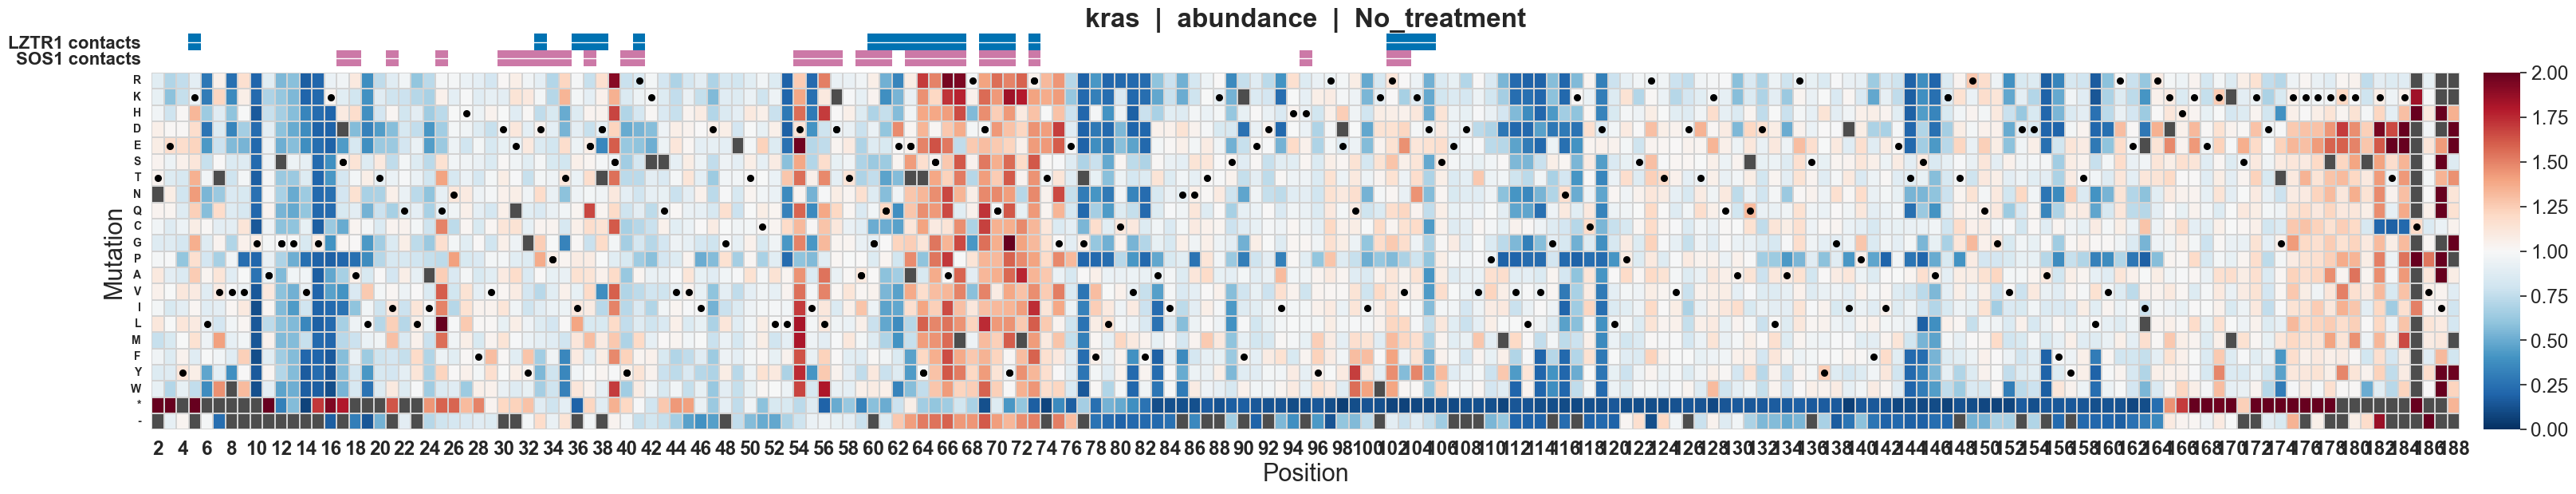

In [49]:
generate_heatmap_for_combo(
    Replicate_scores, 'abundance', 'No_treatment', 'kras',
    score_col='average score',
    scale_type='linear',
    # vmin=None, vmax=None, center=None,
    # first_position=1, last_position=300,
    # missing_color='#4d4d4d',
    lztr1_contacts=kras_lztr1_pos,
    sos1_contacts=kras_sos1_pos,
)

plt.savefig('/Users/jsimon/Downloads/kras_basal_abundance.svg')


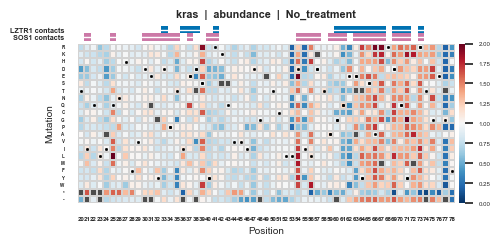

In [50]:
generate_heatmap_for_combo(
    Replicate_scores, 'abundance', 'No_treatment', 'kras',
    score_col='average score',
    scale_type='linear',
    vmin=None, vmax=None, center=None,
    first_position=20, last_position=78,
    missing_color='#4d4d4d',
    font_scale=0.4,
    figsize=(5, 2),
    lztr1_contacts=kras_lztr1_pos,
    sos1_contacts=kras_sos1_pos,
)

plt.savefig('/Users/jsimon/Downloads/kras_basal_abundance_subset.svg')


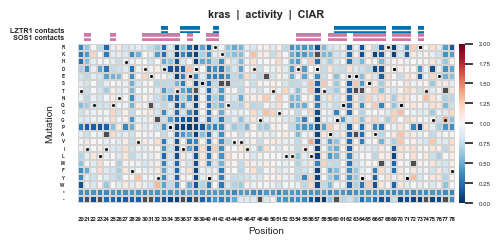

In [51]:
generate_heatmap_for_combo(
    Replicate_scores, 'activity', 'CIAR', 'kras',
    score_col='average score',
    scale_type='linear',
    vmin=None, vmax=None, center=None,
    first_position=20, last_position=78,
    missing_color='#4d4d4d',
    font_scale=0.4,
    figsize=(5, 2),
    lztr1_contacts=kras_lztr1_pos,
    sos1_contacts=kras_sos1_pos,
)

plt.savefig('/Users/jsimon/Downloads/kras_ciar_activity_subset.svg')

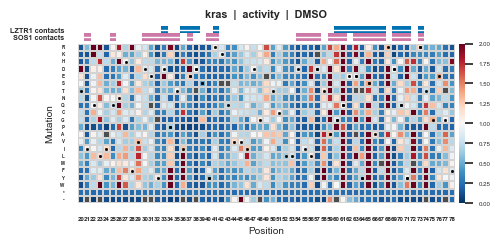

In [52]:
generate_heatmap_for_combo(
    Replicate_scores, 'activity', 'DMSO', 'kras',
    score_col='average score',
    scale_type='linear',
    vmin=None, vmax=None, center=None,
    first_position=20, last_position=78,
    missing_color='#4d4d4d',
    font_scale=0.4,
    figsize=(5, 2),
    lztr1_contacts=kras_lztr1_pos,
    sos1_contacts=kras_sos1_pos,
)

plt.savefig('/Users/jsimon/Downloads/kras_basal_activity_subset.svg')

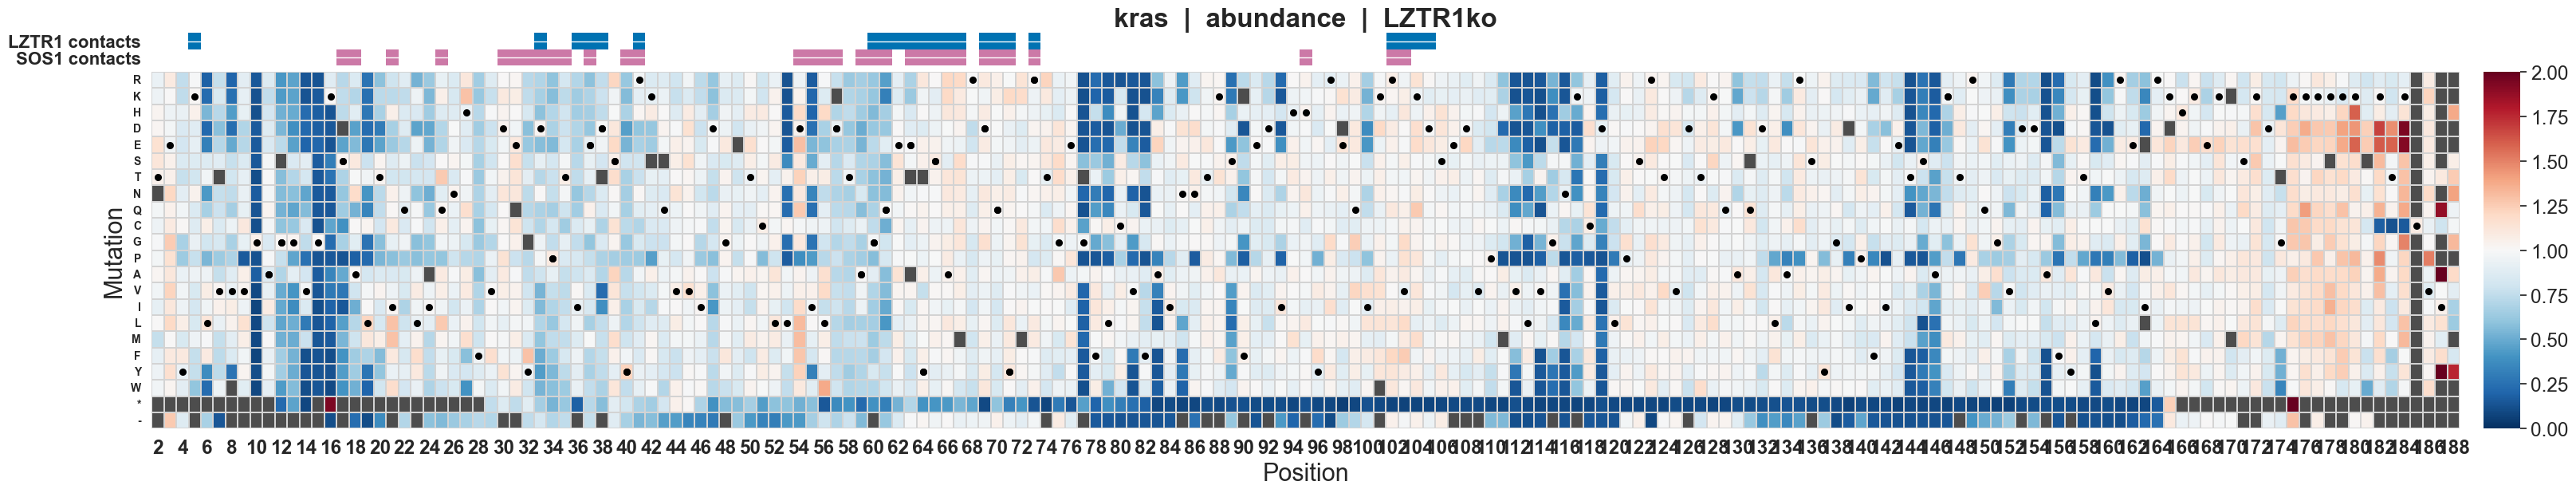

In [53]:
generate_heatmap_for_combo(
    Replicate_scores, 'abundance', 'LZTR1ko', 'kras',
    score_col='average score',
    scale_type='linear',
    vmin=None, vmax=None, center=None,
    lztr1_contacts=kras_lztr1_pos,
    sos1_contacts=kras_sos1_pos,
)

plt.savefig('/Users/jsimon/Downloads/kras_LZTR1ko_abundance.svg')


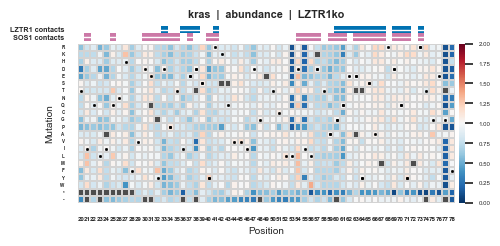

In [54]:
generate_heatmap_for_combo(
    Replicate_scores, 'abundance', 'LZTR1ko', 'kras',
    score_col='average score',
    scale_type='linear',
    vmin=None, vmax=None, center=None,
    first_position=20, last_position=78,
    missing_color='#4d4d4d',
    font_scale=0.4,
    figsize=(5, 2),
    lztr1_contacts=kras_lztr1_pos,
    sos1_contacts=kras_sos1_pos,
)

plt.savefig('/Users/jsimon/Downloads/kras_LZTR1ko_abundance_subset.svg')


/opt/anaconda3/envs/jlab4/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1592: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


ValueError: zero-size array to reduction operation minimum which has no identity

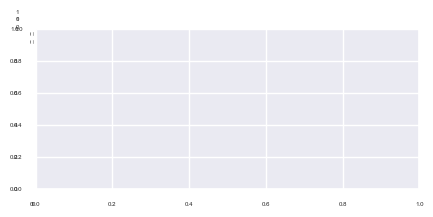

In [85]:
generate_heatmap_for_combo(
    Replicate_scores, 'interaction', 'LZTR1ko', 'kras',
    score_col='average score',
    scale_type='linear',
    vmin=None, vmax=None, center=None,
    first_position=20, last_position=78,
    missing_color='#4d4d4d',
    font_scale=0.4,
    figsize=(5, 2),
    lztr1_contacts=kras_lztr1_pos,
    sos1_contacts=kras_sos1_pos,
)

plt.savefig('/Users/jsimon/Downloads/kras_LZTR1ko_interaction_subset.svg')


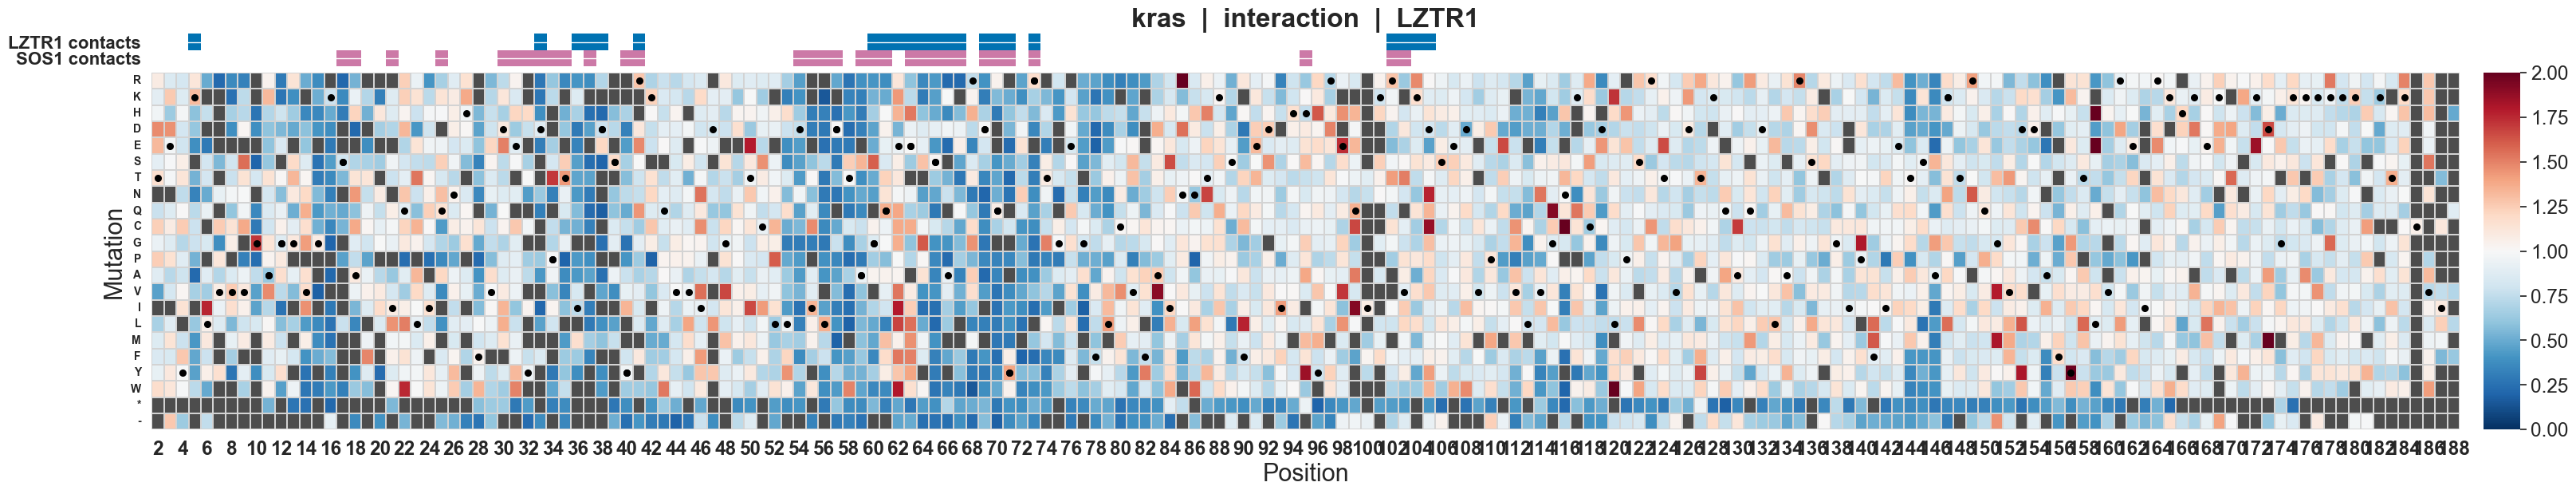

In [78]:
generate_heatmap_for_combo(
    Replicate_scores, 'interaction', 'LZTR1', 'kras',
    score_col='average score',
    scale_type='linear',
    vmin=0, vmax=2, center=1,
    lztr1_contacts=kras_lztr1_pos,
    sos1_contacts=kras_sos1_pos,
)
plt.savefig('/Users/jsimon/Downloads/kras_LZTR1_interaction.svg')


In [ ]:
generate_heatmap_for_combo(
    Replicate_scores, 'abundance', 'CIAR', 'kras',
    score_col='average score',
    scale_type='linear',
    vmin=None, vmax=None, center=None,
    lztr1_contacts=kras_lztr1_pos,
    sos1_contacts=kras_sos1_pos,
)

plt.savefig('/Users/jsimon/Downloads/kras_CIAR_abundance.svg')


In [ ]:
generate_heatmap_for_combo(
    Replicate_scores, 'abundance', 'CIAR', 'kras',
    score_col='average score',
    scale_type='linear',
    vmin=None, vmax=None, center=None,
    first_position=20, last_position=78,
    missing_color='#4d4d4d',
    font_scale=0.4,
    figsize=(5, 2),
    lztr1_contacts=kras_lztr1_pos,
    sos1_contacts=kras_sos1_pos,
)

plt.savefig('/Users/jsimon/Downloads/kras_CIAR_abundance_subset.svg')


In [ ]:
generate_heatmap_for_combo(
    Replicate_scores, 'abundance', 'LZTR1koCIAR', 'kras',
    score_col='average score',
    scale_type='linear',
    vmin=None, vmax=None, center=None,
    lztr1_contacts=kras_lztr1_pos,
    sos1_contacts=kras_sos1_pos,
)

plt.savefig('/Users/jsimon/Downloads/kras_LZTR1koCIAR_abundance.svg')


In [ ]:
generate_heatmap_for_combo(
    Replicate_scores, 'abundance', 'LZTR1koCIAR', 'kras',
    score_col='average score',
    scale_type='linear',
    vmin=None, vmax=None, center=None,
    first_position=20, last_position=78,
    missing_color='#4d4d4d',
    font_scale=0.4,
    figsize=(5, 2),
    lztr1_contacts=kras_lztr1_pos,
    sos1_contacts=kras_sos1_pos,
)

plt.savefig('/Users/jsimon/Downloads/kras_LZTR1koCIAR_abundance_subset.svg')


In [ ]:
generate_heatmap_for_combo(
    Replicate_scores, 'interaction', 'LZTR1', 'kras',
    score_col='average score',
    scale_type='linear',
    vmin=None, vmax=None, center=None,
    lztr1_contacts=kras_lztr1_pos,
    sos1_contacts=kras_sos1_pos,
)


In [ ]:
# ── KRAS LZTR1_abundance_difference heatmap ───────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import gridspec as mpl_gs
import seaborn as sns

sns.set(font_scale=1.6)

SCORE_COL        = 'LZTR1_abundance_difference'
ORDERS           = ['R','K','H','D','E','S','T','N','Q','C','G','P','A','V','I','L','M','F','Y','W','*','-']
TITLE            = 'KRAS — LZTR1ko Δ Abundance (LZTR1ko − Basal)'
YTICK_SIZE       = 16
LABEL_SIZE       = 40
ANNOT_LABEL_SIZE = 30

kras_wide = Replicate_scores_wide[
    Replicate_scores_wide['protein'] == 'kras'
].copy()
kras_wide['Position'] = pd.to_numeric(kras_wide['Position'], errors='coerce')
kras_wide = kras_wide.dropna(subset=['Position'])
kras_wide['Position'] = kras_wide['Position'].astype(int)

hmap = kras_wide[kras_wide['Mutation Type'] == 'missense']
hmap = hmap.groupby(['Position', 'Mutation'])[SCORE_COL].mean().unstack()
hmap = hmap.transpose().reindex(ORDERS, axis=0)

wt_rows = kras_wide[kras_wide['Mutation Type'] == 'synonymous wild type'][
    ['Position', 'Wild Type Residue']
].drop_duplicates().dropna()
wt_rows['Position'] = wt_rows['Position'].astype(int)

abs_max = float(np.nanmax(np.abs(hmap.values)))
vlim    = round(abs_max * 1.05, 3)

n_pos = len(hmap.columns)
n_aa  = len(hmap)
aa_labels = list(hmap.index)

# ── Figure: 4-row GridSpec (LZTR1 | SOS1 | spacer | heatmap) ─────────────────
fig = plt.figure(figsize=(80, 11.3))
gs  = mpl_gs.GridSpec(
    4, 2, figure=fig,
    height_ratios=[1, 1, 0.4, n_aa],
    width_ratios=[n_pos, max(1, n_pos // 60)],
    hspace=0.0, wspace=0.02,
)
ax_lztr1 = fig.add_subplot(gs[0, 0])
ax_sos1  = fig.add_subplot(gs[1, 0])
# gs[2, :] = empty spacer row — no subplot
ax       = fig.add_subplot(gs[3, 0])
ax_cbar  = fig.add_subplot(gs[3, 1])

def _draw_contact_bar(ax_bar, contacts, color, label):
    rgba = np.ones((1, n_pos, 4), dtype=float)
    for j, pos in enumerate(hmap.columns):
        if contacts is not None and pos in contacts:
            rgba[0, j] = mcolors.to_rgba(color)
    ax_bar.imshow(rgba, aspect='auto', interpolation='none',
                  extent=[0, n_pos, 0, 1])
    ax_bar.set_yticks([0.5])
    ax_bar.set_yticklabels([label], fontsize=ANNOT_LABEL_SIZE, fontweight='bold')
    ax_bar.set_xlim(0, n_pos)
    ax_bar.set_ylim(0, 1)
    ax_bar.set_xticks([])
    ax_bar.tick_params(left=False)
    for spine in ax_bar.spines.values():
        spine.set_visible(False)

_draw_contact_bar(ax_lztr1, kras_lztr1_pos, LZTR1_COLOR, 'LZTR1 contacts')
_draw_contact_bar(ax_sos1,  kras_sos1_pos,  SOS1_COLOR,  'SOS1 contacts')
ax_lztr1.set_title(TITLE, fontsize=LABEL_SIZE, fontweight='bold', pad=6)

# ── Main heatmap ──────────────────────────────────────────────────────────────
sns.heatmap(hmap,
            cmap=plt.cm.RdBu_r,
            vmin=-vlim, vmax=vlim, center=0,
            ax=ax, cbar=True, cbar_ax=ax_cbar,
            cbar_kws={'label': 'Δ Abundance (LZTR1ko − Basal)'})

pos_list  = list(hmap.columns)
pos_to_xi = {p: i + 0.5 for i, p in enumerate(pos_list)}
aa_to_yi  = {a: i + 0.5 for i, a in enumerate(aa_labels)}
for _, row in wt_rows.iterrows():
    pos = int(row['Position']); aa = str(row['Wild Type Residue'])
    if pos in pos_to_xi and aa in aa_to_yi:
        ax.plot(pos_to_xi[pos], aa_to_yi[aa], 'o', color='black',
                markersize=5, markeredgewidth=1.5, zorder=5)

ax.set_xlabel('Position', fontsize=LABEL_SIZE, fontname='Sans Serif')
ax.set_ylabel('Mutation', fontsize=LABEL_SIZE, fontname='Sans Serif')
ax.tick_params(left=False, bottom=False)

ax.set_yticks([i + 0.5 for i in range(len(aa_labels))])
ax.set_yticklabels(aa_labels, fontsize=YTICK_SIZE, fontweight='bold',
                   fontname='Sans Serif', rotation=0)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_fontname('Sans Serif')
    label.set_rotation(0)

plt.tight_layout()

out_pdf = os.path.join(output_folder, 'KRAS_LZTR1_abundance_difference_heatmap.pdf')
out_svg = os.path.join(output_folder, 'KRAS_LZTR1_abundance_difference_heatmap.svg')
plt.savefig(out_pdf, bbox_inches='tight', dpi=300)
plt.savefig(out_svg, bbox_inches='tight')
plt.show()


In [ ]:
# ── KRAS ciar_abundance_difference_without_LZTR1 heatmap ──────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import gridspec as mpl_gs
import seaborn as sns

sns.set(font_scale=1.6)

SCORE_COL        = 'ciar_abundance_difference_without_LZTR1'
ORDERS           = ['R','K','H','D','E','S','T','N','Q','C','G','P','A','V','I','L','M','F','Y','W','*','-']
TITLE            = 'KRAS — CIAR Δ Abundance with LZTR1ko (CIAR/LZTR1ko − LZTR1ko)'
YTICK_SIZE       = 16
LABEL_SIZE       = 40
ANNOT_LABEL_SIZE = 30

kras_wide = Replicate_scores_wide[
    Replicate_scores_wide['protein'] == 'kras'
].copy()
kras_wide['Position'] = pd.to_numeric(kras_wide['Position'], errors='coerce')
kras_wide = kras_wide.dropna(subset=['Position'])
kras_wide['Position'] = kras_wide['Position'].astype(int)

hmap = kras_wide[kras_wide['Mutation Type'] == 'missense']
hmap = hmap.groupby(['Position', 'Mutation'])[SCORE_COL].mean().unstack()
hmap = hmap.transpose().reindex(ORDERS, axis=0)

wt_rows = kras_wide[kras_wide['Mutation Type'] == 'synonymous wild type'][
    ['Position', 'Wild Type Residue']
].drop_duplicates().dropna()
wt_rows['Position'] = wt_rows['Position'].astype(int)

abs_max = float(np.nanmax(np.abs(hmap.values)))
vlim    = round(abs_max * 1.05, 3)

n_pos = len(hmap.columns)
n_aa  = len(hmap)
aa_labels = list(hmap.index)

# ── Figure: 4-row GridSpec (LZTR1 | SOS1 | spacer | heatmap) ─────────────────
fig = plt.figure(figsize=(80, 11.3))
gs  = mpl_gs.GridSpec(
    4, 2, figure=fig,
    height_ratios=[1, 1, 0.4, n_aa],
    width_ratios=[n_pos, max(1, n_pos // 60)],
    hspace=0.0, wspace=0.02,
)
ax_lztr1 = fig.add_subplot(gs[0, 0])
ax_sos1  = fig.add_subplot(gs[1, 0])
# gs[2, :] = empty spacer row — no subplot
ax       = fig.add_subplot(gs[3, 0])
ax_cbar  = fig.add_subplot(gs[3, 1])

def _draw_contact_bar(ax_bar, contacts, color, label):
    rgba = np.ones((1, n_pos, 4), dtype=float)
    for j, pos in enumerate(hmap.columns):
        if contacts is not None and pos in contacts:
            rgba[0, j] = mcolors.to_rgba(color)
    ax_bar.imshow(rgba, aspect='auto', interpolation='none',
                  extent=[0, n_pos, 0, 1])
    ax_bar.set_yticks([0.5])
    ax_bar.set_yticklabels([label], fontsize=ANNOT_LABEL_SIZE, fontweight='bold')
    ax_bar.set_xlim(0, n_pos)
    ax_bar.set_ylim(0, 1)
    ax_bar.set_xticks([])
    ax_bar.tick_params(left=False)
    for spine in ax_bar.spines.values():
        spine.set_visible(False)

_draw_contact_bar(ax_lztr1, kras_lztr1_pos, LZTR1_COLOR, 'LZTR1 contacts')
_draw_contact_bar(ax_sos1,  kras_sos1_pos,  SOS1_COLOR,  'SOS1 contacts')
ax_lztr1.set_title(TITLE, fontsize=LABEL_SIZE, fontweight='bold', pad=6)

# ── Main heatmap ──────────────────────────────────────────────────────────────
sns.heatmap(hmap,
            cmap=plt.cm.RdBu_r,
            vmin=-vlim, vmax=vlim, center=0,
            ax=ax, cbar=True, cbar_ax=ax_cbar,
            cbar_kws={'label': 'Δ Abundance (CIAR/LZTR1ko − LZTR1ko)'})

pos_list  = list(hmap.columns)
pos_to_xi = {p: i + 0.5 for i, p in enumerate(pos_list)}
aa_to_yi  = {a: i + 0.5 for i, a in enumerate(aa_labels)}
for _, row in wt_rows.iterrows():
    pos = int(row['Position']); aa = str(row['Wild Type Residue'])
    if pos in pos_to_xi and aa in aa_to_yi:
        ax.plot(pos_to_xi[pos], aa_to_yi[aa], 'o', color='black',
                markersize=5, markeredgewidth=1.5, zorder=5)

ax.set_xlabel('Position', fontsize=LABEL_SIZE, fontname='Sans Serif')
ax.set_ylabel('Mutation', fontsize=LABEL_SIZE, fontname='Sans Serif')
ax.tick_params(left=False, bottom=False)

ax.set_yticks([i + 0.5 for i in range(len(aa_labels))])
ax.set_yticklabels(aa_labels, fontsize=YTICK_SIZE, fontweight='bold',
                   fontname='Sans Serif', rotation=0)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_fontname('Sans Serif')
    label.set_rotation(0)

plt.tight_layout()

out_pdf = os.path.join(output_folder, 'KRAS_CIAR_LZTR1ko_abundance_difference_heatmap.pdf')
out_svg = os.path.join(output_folder, 'KRAS_CIAR_LZTR1ko_abundance_difference_heatmap.svg')
plt.savefig(out_pdf, bbox_inches='tight', dpi=300)
plt.savefig(out_svg, bbox_inches='tight')
plt.show()


# Aggregate plots

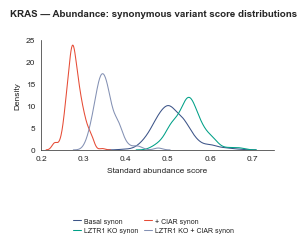

In [16]:
sns.set(style='white')

# ── Distribution plot: missense variants + WT reference lines ─────────────────

# Nature Publishing Group 4-colour palette
treatment_colors = {
    'No_treatment': '#3C5488',   # deep navy
    'LZTR1ko':      '#00A087',   # teal
    'CIAR':         '#E64B35',   # coral red
    'LZTR1koCIAR':  '#8491B4',   # muted lavender
}
treatment_labels = {
    'No_treatment': 'Basal',
    'LZTR1ko':      'LZTR1 KO',
    'CIAR':         '+ CIAR',
    'LZTR1koCIAR':  'LZTR1 KO + CIAR',
}

fig, ax = plt.subplots(figsize=(3.0, 2.2))
fig.subplots_adjust(bottom=0.38)

for treatment, color in treatment_colors.items():
    df = kras_Replicate_scores[
        (kras_Replicate_scores['assay_treatment'] == treatment) &
        (kras_Replicate_scores['assay'] == 'abundance')
    ]

    # Missense variants only
    missense_scores = df[
        df['Mutation Type'] == 'synonymous wild type'
    ]['intercept_0_standard-adjusted score'].dropna()

    # WT reference: mean of all variant='WT' rows for this treatment
    wt_score = df[df['variant'] == 'WT'][
        'intercept_0_standard-adjusted score'
    ].dropna()

    if len(missense_scores) == 0:
        continue

    # KDE curve (solid)
    sns.kdeplot(
        data=missense_scores, ax=ax,
        color=color, linewidth=0.75,
        label=treatment_labels[treatment]
    )

    # # Dashed WT vertical line
    # if len(wt_score) > 0:
    #     ax.axvline(
    #         wt_score.mean(), color=color,
    #         linewidth=0.75, linestyle='--', zorder=5
    #     )

# Nature-style axis formatting
ax.set_xlabel('Standard abundance score', fontsize=6)
ax.set_ylabel('Density', fontsize=6)
ax.tick_params(axis='both', labelsize=6, length=2, width=0.5,
               direction='out', pad=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# ── Legend below plot ─────────────────────────────────────────────────────────
legend_handles = []
for treatment, color in treatment_colors.items():
    legend_handles += [
        Line2D([0], [0], color=color, linewidth=0.75, linestyle='-',
               label=f'{treatment_labels[treatment]} synon'),
    #     Line2D([0], [0], color=color, linewidth=0.75, linestyle='--',
    #            label=f'{treatment_labels[treatment]} WT'),
    ]

fig.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.10),
    ncol=2,
    fontsize=5,
    frameon=False,
    handlelength=1.2,
    handletextpad=0.4,
    columnspacing=0.8,
)

fig.suptitle('KRAS — Abundance: synonymous variant score distributions',
             fontsize=7, fontweight='bold', y=1.02)

plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_abundance_synonymous_dists.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_abundance_synonymous_dists.svg'),
            bbox_inches='tight')

plt.xlim(0.2,0.75)
plt.show()

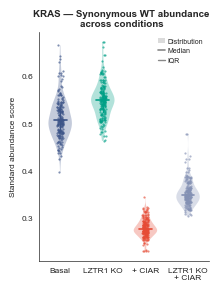

In [17]:
sns.set(style='white')

# ── Violin + jitter: synonymous WT abundance scores across treatments ──────────

TREATMENTS = ['No_treatment', 'LZTR1ko', 'CIAR', 'LZTR1koCIAR']
LABELS     = ['Basal', 'LZTR1 KO', '+ CIAR', 'LZTR1 KO\n+ CIAR']

treatment_colors = {
    'No_treatment': '#3C5488',
    'LZTR1ko':      '#00A087',
    'CIAR':         '#E64B35',
    'LZTR1koCIAR':  '#8491B4',
}

# Collect per-treatment scores
scores_by_treatment = {}
for treatment in TREATMENTS:
    df = kras_Replicate_scores[
        (kras_Replicate_scores['assay_treatment'] == treatment) &
        (kras_Replicate_scores['assay'] == 'abundance') &
        (kras_Replicate_scores['Mutation Type'] == 'synonymous wild type')
    ]
    scores_by_treatment[treatment] = df[
        'intercept_0_standard-adjusted score'
    ].dropna().values

fig, ax = plt.subplots(figsize=(2.2, 2.8))
fig.subplots_adjust(bottom=0.08, top=0.90)

x_pos  = np.arange(len(TREATMENTS))
rng    = np.random.default_rng(seed=42)

for i, treatment in enumerate(TREATMENTS):
    scores = scores_by_treatment[treatment]
    color  = treatment_colors[treatment]

    # ── Violin (half, mirrored) ───────────────────────────────────────────────
    parts = ax.violinplot(scores, positions=[x_pos[i]],
                          widths=0.55, showmedians=False,
                          showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('none')
        pc.set_alpha(0.30)

    # ── Jittered individual points ────────────────────────────────────────────
    jx = x_pos[i] + rng.uniform(-0.07, 0.07, size=len(scores))
    ax.scatter(jx, scores,
               color=color, s=2.5, alpha=0.65,
               linewidths=0, zorder=3)

    # ── Median line ───────────────────────────────────────────────────────────
    median = np.median(scores)
    ax.plot([x_pos[i] - 0.15, x_pos[i] + 0.15], [median, median],
            color=color, linewidth=1.2, zorder=4)

    # ── IQR bar ───────────────────────────────────────────────────────────────
    q1, q3 = np.percentile(scores, [25, 75])
    ax.plot([x_pos[i], x_pos[i]], [q1, q3],
            color=color, linewidth=1.0, zorder=4)

ax.set_xticks(x_pos)
ax.set_xticklabels(LABELS, fontsize=6)
ax.set_ylabel('Standard abundance score', fontsize=6)
ax.set_xlim(-0.5, len(TREATMENTS) - 0.5)
ax.tick_params(axis='both', labelsize=6, length=2, width=0.5,
               direction='out', pad=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

legend_handles = [
    mpl.patches.Patch(facecolor='#888888', alpha=0.3,
                      edgecolor='none', label='Distribution'),
    Line2D([0], [0], color='#888888', linewidth=1.2, label='Median'),
    Line2D([0], [0], color='#888888', linewidth=1.0,
           linestyle='-', label='IQR'),
]
ax.legend(handles=legend_handles, fontsize=5, frameon=False,
          loc='upper right', handlelength=1.0, handletextpad=0.3)

fig.suptitle('KRAS — Synonymous WT abundance\nacross conditions',
             fontsize=7, fontweight='bold', y=0.98)

plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_synWT_abundance_violin.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_synWT_abundance_violin.svg'),
            bbox_inches='tight')
plt.show()

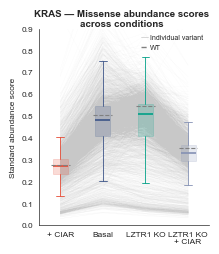

In [18]:
sns.set(style='white')
# ── Box + strip plot: missense variants + WT lines + variant connectors ────────

TREATMENTS = ['CIAR', 'No_treatment', 'LZTR1ko', 'LZTR1koCIAR']
LABELS     = ['+ CIAR', 'Basal', 'LZTR1 KO', 'LZTR1 KO\n+ CIAR']

treatment_colors = {
    'No_treatment': '#3C5488',
    'LZTR1ko':      '#00A087',
    'CIAR':         '#E64B35',
    'LZTR1koCIAR':  '#8491B4',
}

# ── Collect missense scores and build wide table for connector lines ────────────
records = []
for treatment in TREATMENTS:
    df = kras_Replicate_scores[
        (kras_Replicate_scores['assay_treatment'] == treatment) &
        (kras_Replicate_scores['assay'] == 'abundance') &
        (kras_Replicate_scores['Mutation Type'] == 'missense')
    ][['variant', 'intercept_0_standard-adjusted score']].copy()
    df['treatment'] = treatment
    records.append(df)

missense_long = pd.concat(records, ignore_index=True)
missense_long.columns = ['variant', 'score', 'treatment']

# Wide form: only variants present in all 4 treatments (for clean connectors)
missense_wide = missense_long.pivot_table(
    index='variant', columns='treatment', values='score'
).dropna()

fig, ax = plt.subplots(figsize=(2.2, 2.4))
fig.subplots_adjust(bottom=0.08, top=0.90)

x_pos = np.arange(len(TREATMENTS))
rng   = np.random.default_rng(seed=42)

# ── Layer 1: gray connector lines (same variant across treatments) ─────────────
for _, row in missense_wide.iterrows():
    y_vals = [row[t] for t in TREATMENTS]
    ax.plot(x_pos, y_vals,
            color='#C8C8C8', linewidth=0.1, alpha=0.2, zorder=1)

# ── Layer 2: boxplots (per treatment, coloured, no outlier markers) ────────────
for i, treatment in enumerate(TREATMENTS):
    scores = missense_long[
        missense_long['treatment'] == treatment
    ]['score'].dropna().values
    color = treatment_colors[treatment]

    bp = ax.boxplot(
        scores,
        positions=[x_pos[i]],
        widths=0.35,
        patch_artist=True,
        showfliers=False,
        manage_ticks=False,
        zorder=2,
    )
    bp['boxes'][0].set(facecolor=color, alpha=0.20, linewidth=0.6, edgecolor=color)
    bp['medians'][0].set(color=color, linewidth=1.2)
    for w in bp['whiskers']:
        w.set(color=color, linewidth=0.6, linestyle='-')
    for c in bp['caps']:
        c.set(color=color, linewidth=0.6)

# # ── Layer 3: jittered dots ─────────────────────────────────────────────────────
# for i, treatment in enumerate(TREATMENTS):
#     scores = missense_long[
#         missense_long['treatment'] == treatment
#     ]['score'].dropna().values
#     color = treatment_colors[treatment]

#     jx = x_pos[i] + rng.uniform(-0.14, 0.14, size=len(scores))
#     ax.scatter(jx, scores,
#                color=color, s=2.0, alpha=0.45,
#                linewidths=0, zorder=3)

# ── Layer 4: WT black horizontal reference lines ───────────────────────────────
for i, treatment in enumerate(TREATMENTS):
    df = kras_Replicate_scores[
        (kras_Replicate_scores['assay_treatment'] == treatment) &
        (kras_Replicate_scores['assay'] == 'abundance')
    ]
    wt_scores = df[df['variant'] == 'WT'][
        'intercept_0_standard-adjusted score'].dropna()
    if len(wt_scores) > 0:
        ax.plot([x_pos[i] - 0.22, x_pos[i] + 0.22],
                [wt_scores.mean(), wt_scores.mean()],
                color='gray', linewidth=0.8, zorder=5,
                solid_capstyle='round', linestyle='--',
               )

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_xticks(x_pos)
ax.set_xticklabels(LABELS, fontsize=6)
ax.set_ylabel('Standard abundance score', fontsize=6)
ax.set_xlim(-0.5, len(TREATMENTS) - 0.5)
ax.tick_params(axis='both', labelsize=6, length=2, width=0.5,
               direction='out', pad=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

legend_handles = [
    Line2D([0], [0], color='#C8C8C8', linewidth=0.5, label='Individual variant'),
    # Line2D([0], [0], marker='o', color='w', markerfacecolor='#888888',
    #        markersize=3, alpha=0.6, linewidth=0, label='Missense variants'),
    Line2D([0], [0], color='gray', linewidth=1,
           solid_capstyle='round', label='WT', linestyle='--'),
]
ax.legend(handles=legend_handles, fontsize=5, frameon=False,
          loc='upper right', handlelength=1.0, handletextpad=0.3)

fig.suptitle('KRAS — Missense abundance scores\nacross conditions',
             fontsize=7, fontweight='bold', y=0.98)

plt.ylim(0,0.9)

plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_missense_abundance_box.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_missense_abundance_box.svg'),
            bbox_inches='tight')
plt.show()

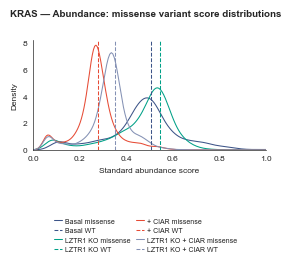

In [19]:
# ── Distribution plot: missense variants + WT reference lines ─────────────────

treatment_colors = {
    'No_treatment': '#3C5488',
    'LZTR1ko':      '#00A087',
    'CIAR':         '#E64B35',
    'LZTR1koCIAR':  '#8491B4',
}
treatment_labels = {
    'No_treatment': 'Basal',
    'LZTR1ko':      'LZTR1 KO',
    'CIAR':         '+ CIAR',
    'LZTR1koCIAR':  'LZTR1 KO + CIAR',
}

fig, ax = plt.subplots(figsize=(3.0, 2.2))
fig.subplots_adjust(bottom=0.38)

for treatment, color in treatment_colors.items():
    df = kras_Replicate_scores[
        (kras_Replicate_scores['assay_treatment'] == treatment) &
        (kras_Replicate_scores['assay'] == 'abundance')
    ]

    missense_scores = df[
        df['Mutation Type'] == 'missense'
    ]['intercept_0_standard-adjusted score'].dropna()

    wt_score = df[df['variant'] == 'WT'][
        'intercept_0_standard-adjusted score'
    ].dropna()

    if len(missense_scores) == 0:
        continue

    sns.kdeplot(data=missense_scores, ax=ax,
                color=color, linewidth=0.75,
                label=treatment_labels[treatment])

    if len(wt_score) > 0:
        ax.axvline(wt_score.mean(), color=color,
                   linewidth=0.75, linestyle='--', zorder=5)

ax.set_xlabel('Standard abundance score', fontsize=6)
ax.set_ylabel('Density', fontsize=6)
ax.tick_params(axis='both', labelsize=6, length=2, width=0.5,
               direction='out', pad=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

legend_handles = []
for treatment, color in treatment_colors.items():
    legend_handles += [
        Line2D([0], [0], color=color, linewidth=0.75, linestyle='-',
               label=f'{treatment_labels[treatment]} missense'),
        Line2D([0], [0], color=color, linewidth=0.75, linestyle='--',
               label=f'{treatment_labels[treatment]} WT'),
    ]

fig.legend(handles=legend_handles, loc='upper center',
           bbox_to_anchor=(0.5, 0.10), ncol=2, fontsize=5,
           frameon=False, handlelength=1.2,
           handletextpad=0.4, columnspacing=0.8)

plt.xlim(0,1)

fig.suptitle('KRAS — Abundance: missense variant score distributions',
             fontsize=7, fontweight='bold', y=1.02)

plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_abundance_missense_dists.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_abundance_missense_dists.svg'),
            bbox_inches='tight')
plt.show()

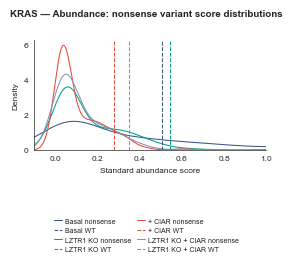

In [20]:
# ── Distribution plot: nonsense variants + WT reference lines ─────────────────

treatment_colors = {
    'No_treatment': '#3C5488',
    'LZTR1ko':      '#00A087',
    'CIAR':         '#E64B35',
    'LZTR1koCIAR':  '#8491B4',
}
treatment_labels = {
    'No_treatment': 'Basal',
    'LZTR1ko':      'LZTR1 KO',
    'CIAR':         '+ CIAR',
    'LZTR1koCIAR':  'LZTR1 KO + CIAR',
}

fig, ax = plt.subplots(figsize=(3.0, 2.2))
fig.subplots_adjust(bottom=0.38)

for treatment, color in treatment_colors.items():
    df = kras_Replicate_scores[
        (kras_Replicate_scores['assay_treatment'] == treatment) &
        (kras_Replicate_scores['assay'] == 'abundance')
    ]

    missense_scores = df[
        df['Mutation Type'] == 'nonsense'
    ]['intercept_0_standard-adjusted score'].dropna()

    wt_score = df[df['variant'] == 'WT'][
        'intercept_0_standard-adjusted score'
    ].dropna()

    if len(missense_scores) == 0:
        continue

    sns.kdeplot(data=missense_scores, ax=ax,
                color=color, linewidth=0.75,
                label=treatment_labels[treatment])

    if len(wt_score) > 0:
        ax.axvline(wt_score.mean(), color=color,
                   linewidth=0.75, linestyle='--', zorder=5)

ax.set_xlabel('Standard abundance score', fontsize=6)
ax.set_ylabel('Density', fontsize=6)
ax.tick_params(axis='both', labelsize=6, length=2, width=0.5,
               direction='out', pad=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

legend_handles = []
for treatment, color in treatment_colors.items():
    legend_handles += [
        Line2D([0], [0], color=color, linewidth=0.75, linestyle='-',
               label=f'{treatment_labels[treatment]} nonsense'),
        Line2D([0], [0], color=color, linewidth=0.75, linestyle='--',
               label=f'{treatment_labels[treatment]} WT'),
    ]

fig.legend(handles=legend_handles, loc='upper center',
           bbox_to_anchor=(0.5, 0.10), ncol=2, fontsize=5,
           frameon=False, handlelength=1.2,
           handletextpad=0.4, columnspacing=0.8)

plt.xlim(-0.1, 1)

fig.suptitle('KRAS — Abundance: nonsense variant score distributions',
             fontsize=7, fontweight='bold', y=1.02)

plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_abundance_nonsense_dists.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_abundance_nonsense_dists.svg'),
            bbox_inches='tight')
plt.show()

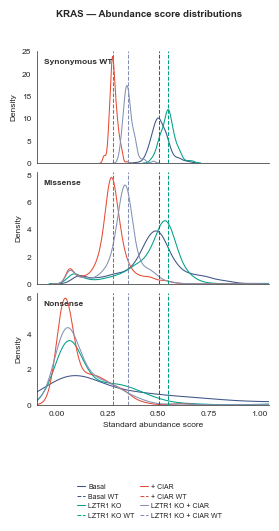

In [21]:
# ── 3-panel stacked distribution: syn-WT / missense / nonsense ─────────────────
mut_panels = [
    ('synonymous wild type', 'Synonymous WT'),
    ('missense',             'Missense'),
    ('nonsense',             'Nonsense'),
]

fig, axes = plt.subplots(3, 1, figsize=(3.0, 5.2), sharex=True)
fig.subplots_adjust(hspace=0.08, bottom=0.22, top=0.90)

for ax, (mut_type, mut_label) in zip(axes, mut_panels):
    for treatment, color in treatment_colors.items():
        df = kras_Replicate_scores[
            (kras_Replicate_scores['assay_treatment'] == treatment) &
            (kras_Replicate_scores['assay'] == 'abundance')
        ]
        scores = df[
            df['Mutation Type'] == mut_type
        ]['intercept_0_standard-adjusted score'].dropna()
        wt_score = df[df['variant'] == 'WT'][
            'intercept_0_standard-adjusted score'
        ].dropna()

        if len(scores) == 0:
            continue

        sns.kdeplot(data=scores, ax=ax, color=color, linewidth=0.75)
        # sns.histplot(data=scores, ax=ax, color=color, binwidth=0.01)
        if len(wt_score) > 0:
            ax.axvline(wt_score.mean(), color=color,
                       linewidth=0.75, linestyle='--', zorder=5)

    # Panel label inside upper-left
    ax.text(0.03, 0.93, mut_label, transform=ax.transAxes,
            fontsize=6, fontweight='bold', va='top', ha='left',
            color='#333333')
    ax.set_ylabel('Density', fontsize=6)
    ax.tick_params(axis='y', labelsize=6, length=2, width=0.5,
                   direction='out', pad=2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

# Bottom panel: x-axis label + ticks only
axes[-1].set_xlabel('Standard abundance score', fontsize=6)
axes[-1].tick_params(axis='x', labelsize=6, length=2, width=0.5,
                     direction='out', pad=2)
axes[-1].set_xlim(-0.1, 1.05)

# Single legend below all panels
legend_handles = []
for treatment, color in treatment_colors.items():
    legend_handles += [
        Line2D([0], [0], color=color, linewidth=0.75, linestyle='-',
               label=treatment_labels[treatment]),
        Line2D([0], [0], color=color, linewidth=0.75, linestyle='--',
               label=f'{treatment_labels[treatment]} WT'),
    ]
fig.legend(handles=legend_handles, loc='upper center',
           bbox_to_anchor=(0.5, 0.08), ncol=2, fontsize=5,
           frameon=False, handlelength=1.2,
           handletextpad=0.4, columnspacing=0.8)

fig.suptitle('KRAS — Abundance score distributions',
             fontsize=7, fontweight='bold')

plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_abundance_all_mut_dists.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_abundance_all_mut_dists.svg'),
            bbox_inches='tight')
plt.show()


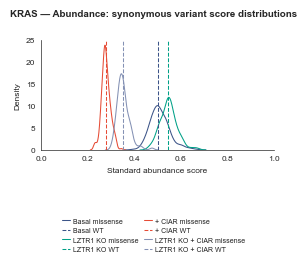

In [22]:
output_folder = '/Users/jsimon/Downloads/'

# ── Distribution plot: missense variants + WT reference lines ─────────────────

treatment_colors = {
    'No_treatment': '#3C5488',
    'LZTR1ko':      '#00A087',
    'CIAR':         '#E64B35',
    'LZTR1koCIAR':  '#8491B4',
}
treatment_labels = {
    'No_treatment': 'Basal',
    'LZTR1ko':      'LZTR1 KO',
    'CIAR':         '+ CIAR',
    'LZTR1koCIAR':  'LZTR1 KO + CIAR',
}

fig, ax = plt.subplots(figsize=(3.0, 2.2))
fig.subplots_adjust(bottom=0.38)

for treatment, color in treatment_colors.items():
    df = kras_Replicate_scores[
        (kras_Replicate_scores['assay_treatment'] == treatment) &
        (kras_Replicate_scores['assay'] == 'abundance')
    ]

    synon_scores = df[
        df['Mutation Type'] == 'synonymous wild type'
    ]['intercept_0_standard-adjusted score'].dropna()

    wt_score = df[df['variant'] == 'WT'][
        'intercept_0_standard-adjusted score'
    ].dropna()

    if len(synon_scores) == 0:
        continue

    sns.kdeplot(data=synon_scores, ax=ax,
                color=color, linewidth=0.75,
                label=treatment_labels[treatment])

    if len(wt_score) > 0:
        ax.axvline(wt_score.mean(), color=color,
                   linewidth=0.75, linestyle='--', zorder=5)

ax.set_xlabel('Standard abundance score', fontsize=6)
ax.set_ylabel('Density', fontsize=6)
ax.tick_params(axis='both', labelsize=6, length=2, width=0.5,
               direction='out', pad=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

legend_handles = []
for treatment, color in treatment_colors.items():
    legend_handles += [
        Line2D([0], [0], color=color, linewidth=0.75, linestyle='-',
               label=f'{treatment_labels[treatment]} missense'),
        Line2D([0], [0], color=color, linewidth=0.75, linestyle='--',
               label=f'{treatment_labels[treatment]} WT'),
    ]

fig.legend(handles=legend_handles, loc='upper center',
           bbox_to_anchor=(0.5, 0.10), ncol=2, fontsize=5,
           frameon=False, handlelength=1.2,
           handletextpad=0.4, columnspacing=0.8)

plt.xlim(0,1)

fig.suptitle('KRAS — Abundance: synonymous variant score distributions',
             fontsize=7, fontweight='bold', y=1.02)

plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_abundance_synon_dists.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_abundance_synon_dists.svg'),
            bbox_inches='tight')
plt.show()

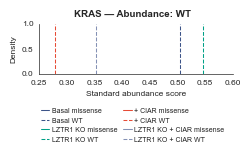

In [23]:
output_folder = '/Users/jsimon/Downloads/'

# ── Distribution plot: missense variants + WT reference lines ─────────────────

treatment_colors = {
    'No_treatment': '#3C5488',
    'LZTR1ko':      '#00A087',
    'CIAR':         '#E64B35',
    'LZTR1koCIAR':  '#8491B4',
}
treatment_labels = {
    'No_treatment': 'Basal',
    'LZTR1ko':      'LZTR1 KO',
    'CIAR':         '+ CIAR',
    'LZTR1koCIAR':  'LZTR1 KO + CIAR',
}

fig, ax = plt.subplots(figsize=(2.5, 1))
fig.subplots_adjust(bottom=0.38)

for treatment, color in treatment_colors.items():
    df = kras_Replicate_scores[
        (kras_Replicate_scores['assay_treatment'] == treatment) &
        (kras_Replicate_scores['assay'] == 'abundance')
    ]

    synon_scores = df[
        df['Mutation Type'] == 'synonymous wild type'
    ]['intercept_0_standard-adjusted score'].dropna()

    wt_score = df[df['variant'] == 'WT'][
        'intercept_0_standard-adjusted score'
    ].dropna()

    # if len(synon_scores) == 0:
    #     continue

    # sns.kdeplot(data=synon_scores, ax=ax,
    #             color=color, linewidth=0.75,
    #             label=treatment_labels[treatment])

    if len(wt_score) > 0:
        ax.axvline(wt_score.mean(), color=color,
                   linewidth=0.75, linestyle='--', zorder=5)

ax.set_xlabel('Standard abundance score', fontsize=6)
ax.set_ylabel('Density', fontsize=6)
ax.tick_params(axis='both', labelsize=6, length=2, width=0.5,
               direction='out', pad=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

legend_handles = []
for treatment, color in treatment_colors.items():
    legend_handles += [
        Line2D([0], [0], color=color, linewidth=0.75, linestyle='-',
               label=f'{treatment_labels[treatment]} missense'),
        Line2D([0], [0], color=color, linewidth=0.75, linestyle='--',
               label=f'{treatment_labels[treatment]} WT'),
    ]

fig.legend(handles=legend_handles, loc='upper center',
           bbox_to_anchor=(0.5, 0.10), ncol=2, fontsize=5,
           frameon=False, handlelength=1.2,
           handletextpad=0.4, columnspacing=0.8)

plt.xlim(0.25,0.6)

fig.suptitle('KRAS — Abundance: WT',
             fontsize=7, fontweight='bold', y=1.02)

plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_abundance_wt_lines.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_abundance_wt_lines.svg'),
            bbox_inches='tight')
plt.show()

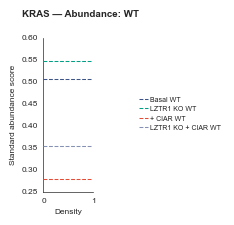

In [24]:
output_folder = '/Users/jsimon/Downloads/'

treatment_colors = {
    'No_treatment': '#3C5488',
    'LZTR1ko':      '#00A087',
    'CIAR':         '#E64B35',
    'LZTR1koCIAR':  '#8491B4',
}
treatment_labels = {
    'No_treatment': 'Basal',
    'LZTR1ko':      'LZTR1 KO',
    'CIAR':         '+ CIAR',
    'LZTR1koCIAR':  'LZTR1 KO + CIAR',
}

fig, ax = plt.subplots(figsize=(1, 2))
fig.subplots_adjust(right=0.62)

for treatment, color in treatment_colors.items():
    df = kras_Replicate_scores[
        (kras_Replicate_scores['assay_treatment'] == treatment) &
        (kras_Replicate_scores['assay'] == 'abundance')
    ]
    wt_score = df[df['variant'] == 'WT'][
        'intercept_0_standard-adjusted score'
    ].dropna()

    if len(wt_score) > 0:
        ax.axhline(wt_score.mean(), color=color,
                   linewidth=0.75, linestyle='--', zorder=5)

ax.set_ylabel('Standard abundance score', fontsize=6)
ax.set_xlabel('Density', fontsize=6)
ax.tick_params(axis='both', labelsize=6, length=2, width=0.5,
               direction='out', pad=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

legend_handles = []
for treatment, color in treatment_colors.items():
    legend_handles += [
        Line2D([0], [0], color=color, linewidth=0.75, linestyle='--',
               label=f'{treatment_labels[treatment]} WT'),
    ]

fig.legend(handles=legend_handles, loc='center left',
           bbox_to_anchor=(1.02, 0.5), ncol=1, fontsize=5,
           frameon=False, handlelength=1.2,
           handletextpad=0.4, columnspacing=0.8)

plt.ylim(0.25, 0.6)

fig.suptitle('KRAS — Abundance: WT',
             fontsize=7, fontweight='bold', y=1.02)

plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_abundance_wt_lines.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1_abundance_wt_lines.svg'),
            bbox_inches='tight')
plt.show()

# PPI Interface Analysis: KRAS interaction positions
### Structures
- **1NVU** — KRAS (chain R) · SOS1 (chain S)
- **9MF0** — KRAS (chain E) · LZTR1 (chain F)

Identifies KRAS residues within 4 Å of the partner chain in each structure, then compares which positions are unique to each interface vs shared.

In [25]:
# ── Download structures from RCSB ──────────────────────────────────────────────
def fetch_structure(pdb_id, fmt="cif", save_dir="."):
    """Download PDB/mmCIF from RCSB; return local path."""
    fname = os.path.join(save_dir, f"{pdb_id}.{fmt}")
    if os.path.exists(fname):
        print(f"  {pdb_id}.{fmt} already on disk.")
        return fname
    url = f"https://files.rcsb.org/download/{pdb_id}.{fmt}"
    r = requests.get(url, timeout=30)
    if r.status_code == 200:
        with open(fname, "w") as fh:
            fh.write(r.text)
        print(f"  Downloaded {pdb_id}.{fmt}  ({len(r.text)//1024} KB)")
        return fname
    raise RuntimeError(f"Could not download {pdb_id} (HTTP {r.status_code})")

p1 = fetch_structure("1NVU")
p2 = fetch_structure("9MF0")

  1NVU.cif already on disk.
  9MF0.cif already on disk.


In [26]:
# ── Parse structures ───────────────────────────────────────────────────────────
parser = MMCIFParser(QUIET=True)

struct_1nvu = parser.get_structure("1NVU", "1NVU.cif")
struct_9mf0 = parser.get_structure("9MF0", "9MF0.cif")

def get_chain(structure, chain_id, model=0):
    return structure[model][chain_id]

# 1NVU: KRAS = chain R, SOS1 = chain S
kras_1nvu = get_chain(struct_1nvu, "R")
sos1      = get_chain(struct_1nvu, "S")

# 9MF0: KRAS = chain E, LZTR1 = chain F
kras_9mf0 = get_chain(struct_9mf0, "E")
lztr1     = get_chain(struct_9mf0, "F")

for name, chain in [("1NVU KRAS(R)", kras_1nvu), ("1NVU SOS1(S)",  sos1),
                    ("9MF0 KRAS(E)", kras_9mf0), ("9MF0 LZTR1(F)", lztr1)]:
    residues = [r for r in chain.get_residues() if r.id[0] == " "]
    print(f"  {name}: {len(residues)} residues")

  1NVU KRAS(R): 166 residues
  1NVU SOS1(S): 469 residues
  9MF0 KRAS(E): 168 residues
  9MF0 LZTR1(F): 318 residues


In [27]:
# ── Interface calculation ──────────────────────────────────────────────────────
DIST_CUTOFF = 4   # Å — any heavy atom within this distance = interacting

def get_interface_residues(chain_a, chain_b, cutoff=DIST_CUTOFF):
    """
    Return set of residue sequence numbers from chain_a that have at least
    one heavy atom within `cutoff` Å of any heavy atom in chain_b.
    """
    atoms_b = [atom for res in chain_b.get_residues()
                     if res.id[0] == " "
                     for atom in res.get_atoms()
                     if atom.element != "H"]
    coords_b = np.array([a.coord for a in atoms_b])

    interacting = set()
    for res_a in chain_a.get_residues():
        if res_a.id[0] != " ":
            continue
        for atom_a in res_a.get_atoms():
            if atom_a.element == "H":
                continue
            diffs = coords_b - atom_a.coord
            dists = np.sqrt((diffs ** 2).sum(axis=1))
            if dists.min() <= cutoff:
                interacting.add(res_a.id[1])
                break

    return interacting

print(f"Computing interfaces (cutoff = {DIST_CUTOFF} Å)…")
kras_sos1_pos  = get_interface_residues(kras_1nvu, sos1)
kras_lztr1_pos = get_interface_residues(kras_9mf0, lztr1)

print(f"  KRAS ↔ SOS1  : {len(kras_sos1_pos)} interacting KRAS positions")
print(f"  KRAS ↔ LZTR1 : {len(kras_lztr1_pos)} interacting KRAS positions")
print(f"  Shared        : {len(kras_sos1_pos & kras_lztr1_pos)}")
print(f"  SOS1-only     : {len(kras_sos1_pos - kras_lztr1_pos)}")
print(f"  LZTR1-only    : {len(kras_lztr1_pos - kras_sos1_pos)}")

Computing interfaces (cutoff = 4 Å)…
  KRAS ↔ SOS1  : 32 interacting KRAS positions
  KRAS ↔ LZTR1 : 22 interacting KRAS positions
  Shared        : 16
  SOS1-only     : 16
  LZTR1-only    : 6


In [28]:
# ── Integer interface position sets ───────────────────────────────────────────
# Derived from the structural contact analysis (cells above).
# kras_sos1_pos  = KRAS positions within DIST_CUTOFF Å of SOS1  (1NVU, chain R↔S)
# kras_lztr1_pos = KRAS positions within DIST_CUTOFF Å of LZTR1 (9MF0, chain E↔F)

sos1_only_int  = kras_sos1_pos - kras_lztr1_pos   # SOS1 interface only
shared_pos_int = kras_sos1_pos & kras_lztr1_pos    # shared by both interfaces
lztr1_only_int = kras_lztr1_pos - kras_sos1_pos    # LZTR1 interface only

print("Interface positions (integer sets):")
print(f"  SOS1 only  : n={len(sos1_only_int):2d}  {sorted(sos1_only_int)}")
print(f"  Shared     : n={len(shared_pos_int):2d}  {sorted(shared_pos_int)}")
print(f"  LZTR1 only : n={len(lztr1_only_int):2d}  {sorted(lztr1_only_int)}")


Interface positions (integer sets):
  SOS1 only  : n=16  [17, 18, 21, 25, 30, 31, 32, 34, 35, 40, 54, 55, 56, 57, 59, 95]
  Shared     : n=16  [33, 37, 41, 60, 61, 63, 64, 65, 66, 67, 69, 70, 71, 73, 102, 103]
  LZTR1 only : n= 6  [5, 36, 38, 62, 104, 105]


# Correlation Plots

Analysis 1 (shared): n=260
Analysis 2 (shared): n=0
  Interaction vs Δ Abundance: ρ=0.615, p < 0.001
  Δ Activity vs Δ Abundance: ρ=nan, p = nan


/var/folders/gm/9s1r71xx78gfdmh_7yx141580000gn/T/ipykernel_25285/791268216.py:79: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, *_ = linregress(x, y)


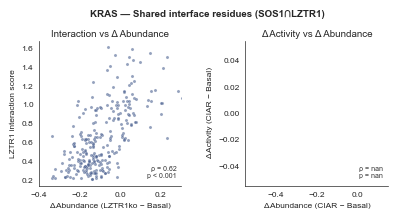

In [29]:
# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  AXIS LIMITS — edit here, then re-run the plot cell below                  │
# │  Set to (min, max) to fix an axis, or None for auto-scale                  │
# │                                                                             │
# │  Panel 1: LZTR1 interaction score (x) vs Δ Abundance LZTR1ko (y)          │
# │  Panel 2: Δ Abundance CIAR (x)        vs Δ Activity CIAR (y)              │
# └─────────────────────────────────────────────────────────────────────────────┘
XLIM_P1 = (-0.4, 0.3)          # e.g. (0.0, 1.5)
YLIM_P1 = None          # e.g. (-0.3, 0.3)

XLIM_P2 = (-0.55, 0.15)  # e.g. None
YLIM_P2 = None          # e.g. (-0.5, 0.5)


# ── Difference score analyses — SHARED interface residues only ────────────────
SCORE = 'intercept_0_standard-adjusted score'
SCORE_WT_norm = 'average score'

def get_variant_scores(protein, assay, treatment, mut_type='missense'):
    df = Replicate_scores[
        (Replicate_scores['protein']==protein) &
        (Replicate_scores['assay']==assay) &
        (Replicate_scores['assay_treatment']==treatment)
    ].copy()
    if mut_type: df = df[df['Mutation Type']==mut_type]
    return df.groupby('variant')[SCORE].mean()

def get_variant_scores_int(protein, assay, treatment, mut_type='missense'):
    df = Replicate_scores[
        (Replicate_scores['protein']==protein) &
        (Replicate_scores['assay']==assay) &
        (Replicate_scores['assay_treatment']==treatment)
    ].copy()
    if mut_type: df = df[df['Mutation Type']==mut_type]
    return df.groupby('variant')[SCORE_WT_norm].mean()

var_pos = (kras_Replicate_scores_wide[['variant','Position']]
    .drop_duplicates('variant')
    .assign(Position=lambda d: pd.to_numeric(d['Position'], errors='coerce'))
    .set_index('variant'))
shared_variants = var_pos[var_pos['Position'].isin(shared_pos_int)].index

abund_basal    = get_variant_scores('kras','abundance','No_treatment')
abund_lztr1ko  = get_variant_scores('kras','abundance','LZTR1ko')
interact_lztr1 = get_variant_scores_int('kras','interaction','LZTR1')
abund_ciar     = get_variant_scores('kras','abundance','CIAR')
act_basal      = get_variant_scores('kras','activity','No_treatment')
act_ciar       = get_variant_scores('kras','activity','CIAR')

df1 = pd.DataFrame({'delta_abund_LZTR1ko': abund_lztr1ko - abund_basal,
                    'interaction_LZTR1': interact_lztr1}).dropna()
df1 = df1[df1.index.isin(shared_variants)]
print(f"Analysis 1 (shared): n={len(df1)}")

df2 = pd.DataFrame({'delta_abund_CIAR': abund_ciar - abund_basal,
                    'delta_act_CIAR':   act_ciar - act_basal}).dropna()
df2 = df2[df2.index.isin(shared_variants)]
print(f"Analysis 2 (shared): n={len(df2)}")

# ── Plot ──────────────────────────────────────────────────────────────────────
panels = [
    (df1,'delta_abund_LZTR1ko','interaction_LZTR1',
     '\u0394 Abundance (LZTR1ko \u2212 Basal)','LZTR1 interaction score',
     'Interaction vs \u0394 Abundance', XLIM_P1, YLIM_P1),
    (df2,'delta_abund_CIAR','delta_act_CIAR',
     '\u0394 Abundance (CIAR \u2212 Basal)','\u0394 Activity (CIAR \u2212 Basal)',
     '\u0394 Activity vs \u0394 Abundance', XLIM_P2, YLIM_P2),
]

fig, axes = plt.subplots(1, 2, figsize=(4.5, 2.2))
fig.subplots_adjust(wspace=0.45, bottom=0.22)
POINT_COLOR = '#3C5488'; LINE_COLOR = '#E64B35'

for ax, (df, xcol, ycol, xlabel, ylabel, title, xlim, ylim) in zip(axes, panels):
    x, y = df[xcol].values, df[ycol].values
    ax.scatter(x, y, s=5.0, color=POINT_COLOR, alpha=0.55,
               edgecolors='white', linewidths=0.2, zorder=2)
    x_lo, x_hi = xlim if xlim else (x.min(), x.max())
    slope, intercept, *_ = linregress(x, y)
    xl = np.linspace(x_lo, x_hi, 200)
    # ax.plot(xl, slope*xl + intercept, color=LINE_COLOR, linewidth=0.8, zorder=3)
    rho, pval = spearmanr(x, y)
    p_str = 'p < 0.001' if pval < 0.001 else f'p = {pval:.3f}'
    ax.text(0.97, 0.05, f'\u03c1 = {rho:.2f}\n{p_str}', transform=ax.transAxes,
            fontsize=5, ha='right', va='bottom', color='#333333')
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    ax.set_title(title, fontsize=7, pad=3)
    ax.set_xlabel(xlabel, fontsize=6); ax.set_ylabel(ylabel, fontsize=6)
    ax.tick_params(axis='both', labelsize=6, length=2, width=0.5, direction='out', pad=2)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    ax.spines['left'].set_linewidth(0.5); ax.spines['bottom'].set_linewidth(0.5)
    print(f"  {title}: \u03c1={rho:.3f}, {p_str}")

fig.suptitle('KRAS \u2014 Shared interface residues (SOS1\u2229LZTR1)',
             fontsize=7, fontweight='bold', y=1.02)
output_folder = '/Users/jsimon/Downloads/'
plt.savefig(os.path.join(output_folder,'KRAS_difference_score_analyses_shared.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder,'KRAS_difference_score_analyses_shared.svg'),
            bbox_inches='tight')
plt.show()


  SOS1 only (n=16 pos): n=300, ρ=0.792, p < 0.001
  Shared (SOS1∩LZTR1, n=16 pos): n=301, ρ=0.843, p < 0.001
  LZTR1 only (n=6 pos): n=113, ρ=0.678, p < 0.001
  All variants: n=3489, ρ=0.838, p < 0.001
  All variants (basal score > 1): n=1353, ρ=0.626, p < 0.001


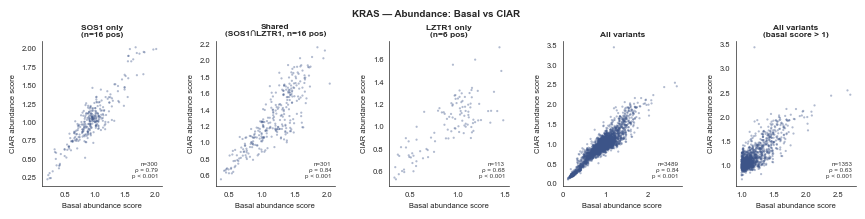

In [30]:

# ── Abundance: Basal vs CIAR — by interface category + all variants ───────────
# ┌──────────────────────────────────────────────────────┐
# │  AXIS LIMITS — None = auto, or set (min, max)        │
# └──────────────────────────────────────────────────────┘
XLIM = None
YLIM = None

XCOL = 'average score__abundance__No_treatment'
YCOL = 'average score__abundance__CIAR'
POINT_COLOR = '#3C5488'

_mis = kras_Replicate_scores_wide[
    kras_Replicate_scores_wide['Mutation Type'] == 'missense'
].copy()
_mis['_pos_int'] = pd.to_numeric(_mis['Position'], errors='coerce')

panels = [
    ('SOS1 only\n(n=16 pos)',           _mis[_mis['_pos_int'].isin(sos1_only_int)]),
    ('Shared\n(SOS1\u2229LZTR1, n=16 pos)', _mis[_mis['_pos_int'].isin(shared_pos_int)]),
    ('LZTR1 only\n(n=6 pos)',           _mis[_mis['_pos_int'].isin(lztr1_only_int)]),
    ('All variants',                    _mis),
    ('All variants\n(basal score > 1)', _mis[_mis[XCOL] > 1]),
]

fig, axes = plt.subplots(1, 5, figsize=(10.5, 2.2))
fig.subplots_adjust(wspace=0.45, bottom=0.22)

for ax, (title, df_sub) in zip(axes, panels):
    df = df_sub[[XCOL, YCOL]].dropna()
    x, y = df[XCOL].values, df[YCOL].values

    ax.scatter(x, y, s=2.5, color=POINT_COLOR, alpha=0.4,
               edgecolors='none', linewidths=0, zorder=2)

    # Regression line (uncomment to show)
    if len(x) > 1:
        slope, intercept, *_ = linregress(x, y)
        x_lo = XLIM[0] if XLIM else x.min()
        x_hi = XLIM[1] if XLIM else x.max()
        xl = np.linspace(x_lo, x_hi, 200)
        # ax.plot(xl, slope*xl + intercept, color='#E64B35', linewidth=0.8, zorder=3)

    rho, pval = spearmanr(x, y)
    p_str = 'p < 0.001' if pval < 0.001 else f'p = {pval:.3f}'
    ax.text(0.97, 0.05, f'n={len(df)}\n\u03c1 = {rho:.2f}\n{p_str}',
            transform=ax.transAxes, fontsize=4.5,
            ha='right', va='bottom', color='#333333')

    if XLIM: ax.set_xlim(XLIM)
    if YLIM: ax.set_ylim(YLIM)

    ax.set_title(title, fontsize=6, fontweight='bold', pad=3)
    ax.set_xlabel('Basal abundance score', fontsize=5.5)
    ax.set_ylabel('CIAR abundance score', fontsize=5.5)
    ax.tick_params(axis='both', labelsize=5.5, length=2, width=0.5,
                   direction='out', pad=2)
    for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    print(f"  {title.replace(chr(10),' ')}: n={len(df)}, \u03c1={rho:.3f}, {p_str}")

fig.suptitle('KRAS \u2014 Abundance: Basal vs CIAR',
             fontsize=7, fontweight='bold', y=1.02)

output_folder = '/Users/jsimon/Downloads/'
plt.savefig(os.path.join(output_folder, 'KRAS_abundance_basal_vs_CIAR_by_interface.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_abundance_basal_vs_CIAR_by_interface.svg'),
            bbox_inches='tight')

plt.show()


# Calculate residual values and define functional positions

In [31]:
# ── Harmonized residuals: fits · per-variant table · syn-WT reference · pos_df ─
from scipy.stats import linregress as _lr
import numpy as np

# ── Score column names ─────────────────────────────────────────────────────────
SCORE      = 'intercept_0_standard-adjusted score'
COL_BASAL  = f'{SCORE}__abundance__No_treatment'
COL_LZ     = f'{SCORE}__abundance__LZTR1ko'
COL_CIAR   = f'{SCORE}__abundance__CIAR'
COL_LZCIAR = f'{SCORE}__abundance__LZTR1koCIAR'

output_folder = '/Users/jsimon/Downloads/'

# ── Interface map ──────────────────────────────────────────────────────────────
interface_map = {}
for p in sos1_only_int:   interface_map[str(p)] = 'SOS1 only'
for p in shared_pos_int:  interface_map[str(p)] = 'Shared (SOS1∩LZTR1)'
for p in lztr1_only_int:  interface_map[str(p)] = 'LZTR1 only'

# Structural contact categories → use CONTACT color palette (from master palette cell)
iface_colors = {
    'SOS1 only':           SOS1_CONTACT_COLOR,    # muted rose   — SOS1 structural contacts
    'Shared (SOS1∩LZTR1)': BOTH_FUNC_COLOR,       # lavender     — contacts with both partners
    'LZTR1 only':          LZTR1_CONTACT_COLOR,   # cerulean blue — LZTR1 structural contacts
    'Other':               '#CCCCCC',
}

# ── Subset missense and synonymous-WT variants ─────────────────────────────────
_mis = kras_Replicate_scores_wide[
    kras_Replicate_scores_wide['Mutation Type'] == 'missense'
].copy()
_mis['Position'] = pd.to_numeric(_mis['Position'], errors='coerce')

_syn = kras_Replicate_scores_wide[
    kras_Replicate_scores_wide['Mutation Type'] == 'synonymous wild type'
].copy()
_syn['Position'] = pd.to_numeric(_syn['Position'], errors='coerce')

# ── 4 conditions: (label, x_col, y_col, origin-forced col, free-fit col) ──────
conditions = [
    ('LZTR1ko',                COL_BASAL, COL_LZ,     'resid_LZTR1ko',                 'resid_free_LZTR1ko'),
    ('CIAR',                   COL_BASAL, COL_CIAR,   'resid_CIAR',                    'resid_free_CIAR'),
    ('LZTR1koCIAR',            COL_BASAL, COL_LZCIAR, 'resid_LZTR1koCIAR',             'resid_free_LZTR1koCIAR'),
    ('LZTR1koCIAR vs LZTR1ko', COL_LZ,   COL_LZCIAR, 'resid_LZTR1koCIAR_on_LZTR1ko', 'resid_free_LZTR1koCIAR_on_LZTR1ko'),
]

# ── Fit models (free + origin-forced) and compute per-variant residuals ─────────
_origin_slopes = {}   # label → slope₀  (intercept forced = 0)
_free_fits     = {}   # label → (slope, intercept, R²)

print(f"{'Condition':<28} {'Slope':>8} {'Intercept':>10} {'R²':>7}  {'Slope₀':>8}")
print('─' * 70)

for label, xcol, ycol, col_orig, col_free in conditions:
    mask = _mis[xcol].notna() & _mis[ycol].notna()
    x = _mis.loc[mask, xcol].values
    y = _mis.loc[mask, ycol].values

    sl, ic, r, _, _ = _lr(x, y)
    sl0 = np.dot(x, y) / np.dot(x, x)
    _free_fits[label]     = (sl, ic, r**2)
    _origin_slopes[label] = sl0

    print(f"{label:<28} {sl:>8.3f} {ic:>10.4f} {r**2:>7.3f}  {sl0:>8.3f}")

    # Add both residual columns to _mis (NaN where either score is missing)
    _mis[col_orig] = _mis[ycol] - sl0 * _mis[xcol]
    _mis[col_free] = _mis[ycol] - (sl * _mis[xcol] + ic)

# ── kras_residuals: variant-level table (all missense, 8 residual columns) ─────
resid_cols = [
    'resid_LZTR1ko',                     'resid_CIAR',
    'resid_LZTR1koCIAR',                 'resid_LZTR1koCIAR_on_LZTR1ko',
    'resid_free_LZTR1ko',                'resid_free_CIAR',
    'resid_free_LZTR1koCIAR',            'resid_free_LZTR1koCIAR_on_LZTR1ko',
]
kras_residuals = _mis.copy()
_cols = [c for c in kras_residuals.columns if c not in resid_cols]
_mt_idx = _cols.index('Mutation Type') + 1
_cols = _cols[:_mt_idx] + resid_cols + _cols[_mt_idx:]
kras_residuals = kras_residuals[_cols]
print(f"\nkras_residuals shape: {kras_residuals.shape}")

# ── syn_iqr: syn-WT reference  P5 / median / P95 (both fit types, all 4 conditions)
# Keys: 'p05', 'med', 'p95', 'n'
syn_iqr = {}
print(f"\n{'Residual column':<46} {'n':>5}  {'P5':>8}  {'Med':>8}  {'P95':>8}")
print('─' * 80)

for label, xcol, ycol, col_orig, col_free in conditions:
    sl, ic, _r2 = _free_fits[label]
    sl0          = _origin_slopes[label]
    mask         = _syn[xcol].notna() & _syn[ycol].notna()
    x_s          = _syn.loc[mask, xcol]
    y_s          = _syn.loc[mask, ycol]
    n            = int(mask.sum())

    for col, resids in [
        (col_orig, y_s - sl0 * x_s),
        (col_free, y_s - (sl * x_s + ic)),
    ]:
        syn_iqr[col] = {
            'p05': resids.quantile(0.05),
            'med': resids.median(),
            'p95': resids.quantile(0.95),
            'n':   n,
        }
        print(f"  {col:<44}  {n:>5}  {syn_iqr[col]['p05']:>8.4f}  "
              f"{syn_iqr[col]['med']:>8.4f}  {syn_iqr[col]['p95']:>8.4f}")

# ── pos_df: position-level table (median + IQR per residual, interface labels) ─
def _q25(x): return x.quantile(0.25)
def _q75(x): return x.quantile(0.75)

_mis_valid = _mis.dropna(subset=['Position']).copy()
_mis_valid['Position'] = _mis_valid['Position'].astype(int)

_agg = {'n': (resid_cols[0], 'count')}
for col in resid_cols:
    _agg[f'{col}_median'] = (col, 'median')
    _agg[f'{col}_q25']    = (col, _q25)
    _agg[f'{col}_q75']    = (col, _q75)

pos_df = _mis_valid.groupby('Position').agg(**_agg).reset_index()

pos_df['Interface']    = pos_df['Position'].astype(str).map(interface_map).fillna('Other')
pos_df['color']        = pos_df['Interface'].map(iface_colors)
pos_df['lztr1ko_abs']  = pos_df['resid_LZTR1ko_median'].abs()
pos_df['ciar_abs']     = pos_df['resid_CIAR_median'].abs()
pos_df['bifunc_score'] = pos_df['lztr1ko_abs'] * pos_df['ciar_abs']

# Short aliases (origin-forced medians) used by downstream cells
_aliases = {
    'resid_LZTR1ko_median':     'lztr1ko_median',
    'resid_LZTR1ko_q25':        'lztr1ko_q25',
    'resid_LZTR1ko_q75':        'lztr1ko_q75',
    'resid_CIAR_median':        'ciar_median',
    'resid_CIAR_q25':           'ciar_q25',
    'resid_CIAR_q75':           'ciar_q75',
    'resid_LZTR1koCIAR_median': 'lzciar_median',
    'resid_LZTR1koCIAR_q25':    'lzciar_q25',
    'resid_LZTR1koCIAR_q75':    'lzciar_q75',
}
for old, new in _aliases.items():
    if old in pos_df.columns:
        pos_df[new] = pos_df[old]

print(f"\nPositions in pos_df: {len(pos_df)}  |  "
      f"Contact residues: {(pos_df['Interface'] != 'Other').sum()}")


Condition                       Slope  Intercept      R²    Slope₀
──────────────────────────────────────────────────────────────────────
LZTR1ko                         0.802     0.0959   0.685     0.987
CIAR                            0.518     0.0235   0.830     0.564
LZTR1koCIAR                     0.547     0.0651   0.704     0.673
LZTR1koCIAR vs LZTR1ko          0.609     0.0345   0.817     0.675

kras_residuals shape: (3528, 64)

Residual column                                    n        P5       Med       P95
────────────────────────────────────────────────────────────────────────────────
  resid_LZTR1ko                                   180   -0.0376    0.0441    0.1220
  resid_free_LZTR1ko                              180   -0.0330    0.0414    0.1181
  resid_CIAR                                      180   -0.0541   -0.0084    0.0340
  resid_free_CIAR                                 180   -0.0520   -0.0084    0.0311
  resid_LZTR1koCIAR                               180   -0.

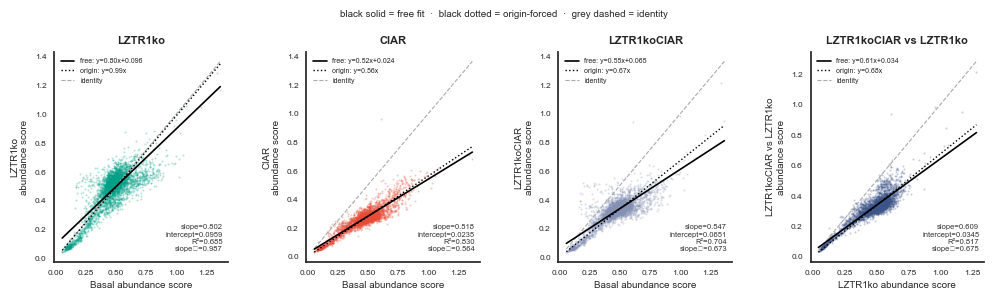

In [32]:
# ── Regression diagnostics: scatter plots (fits computed in cell above) ────────
import matplotlib.pyplot as plt

_conditions_plot = [
    ('LZTR1ko',                COL_BASAL, COL_LZ,     '#00A087'),
    ('CIAR',                   COL_BASAL, COL_CIAR,   '#E64B35'),
    ('LZTR1koCIAR',            COL_BASAL, COL_LZCIAR, '#8491B4'),
    ('LZTR1koCIAR vs LZTR1ko', COL_LZ,   COL_LZCIAR, '#3C5488'),
]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
fig.subplots_adjust(wspace=0.45, bottom=0.18)

for ax, (label, xcol, ycol, color) in zip(axes, _conditions_plot):
    mask = _mis[xcol].notna() & _mis[ycol].notna()
    x = _mis.loc[mask, xcol].values
    y = _mis.loc[mask, ycol].values
    sl, ic, r2 = _free_fits[label]
    sl0 = _origin_slopes[label]
    xl = np.linspace(x.min(), x.max(), 200)

    ax.scatter(x, y, s=2, color=color, alpha=0.3, linewidths=0, zorder=2)
    ax.plot(xl, sl * xl + ic, color='black', linewidth=1.2, zorder=4,
            label=f'free: y={sl:.2f}x+{ic:.3f}')
    ax.plot(xl, sl0 * xl, color='black', linewidth=1.0, linestyle=':',
            zorder=4, label=f'origin: y={sl0:.2f}x')
    ax.plot(xl, xl, color='#AAAAAA', linewidth=0.8, linestyle='--', zorder=3,
            label='identity')

    xlabel = 'Basal abundance score' if xcol == COL_BASAL else 'LZTR1ko abundance score'
    ax.set_xlabel(xlabel, fontsize=7)
    ax.set_ylabel(f'{label}\nabundance score', fontsize=7)
    ax.set_title(label, fontsize=8, fontweight='bold')
    ax.tick_params(labelsize=6, length=2, width=0.5)
    ax.legend(fontsize=5, frameon=False, loc='upper left')
    ax.text(0.97, 0.05,
            f'slope={sl:.3f}\nintercept={ic:.4f}\nR²={r2:.3f}\nslope₀={sl0:.3f}',
            transform=ax.transAxes, fontsize=5.5, ha='right', va='bottom',
            color='#333333')
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

fig.suptitle('black solid = free fit  ·  black dotted = origin-forced  ·  grey dashed = identity',
             fontsize=7, y=1.02)
plt.show()


In [33]:
# ── kras_residuals summary ────────────────────────────────────────────────────
# (computed in the harmonized cell above — no recomputation needed here)
print(f"kras_residuals shape: {kras_residuals.shape}")
print(f"\n{'Residual column':<48}  {'n non-NaN':>10}  {'std':>8}")
print('─' * 72)
for col in [c for c in kras_residuals.columns if c.startswith('resid_')]:
    n   = kras_residuals[col].notna().sum()
    std = kras_residuals[col].std()
    print(f"  {col:<46}  {n:>10}  {std:>8.4f}")

kras_residuals


kras_residuals shape: (3528, 64)

Residual column                                    n non-NaN       std
────────────────────────────────────────────────────────────────────────
  resid_LZTR1ko                                         3491    0.0889
  resid_CIAR                                            3489    0.0369
  resid_LZTR1koCIAR                                     3491    0.0583
  resid_LZTR1koCIAR_on_LZTR1ko                          3491    0.0444
  resid_free_LZTR1ko                                    3491    0.0842
  resid_free_CIAR                                       3489    0.0362
  resid_free_LZTR1koCIAR                                3491    0.0549
  resid_free_LZTR1koCIAR_on_LZTR1ko                     3491    0.0432


,protein,variant,library,Wild Type Residue,Mutation,Position,Mutation Type,resid_LZTR1ko,resid_CIAR,resid_LZTR1koCIAR,resid_LZTR1koCIAR_on_LZTR1ko,resid_free_LZTR1ko,resid_free_CIAR,resid_free_LZTR1koCIAR,resid_free_LZTR1koCIAR_on_LZTR1ko,domain,client_status,buffered,percent_buffered,classification_mod,dssp_secondary_structure,relative_sasa,active_site,protein_interface,alignment_pos,average score__abundance__CIAR,average score__abundance__DMSO,average score__abundance__HSP90i,average score__abundance__LZTR1ko,average score__abundance__LZTR1koCIAR,average score__abundance__No_treatment,average score__activity__CIAR,average score__activity__DMSO,average score__activity__No_treatment,average score__activity__SerumStarve,average score__interaction__LZTR1,classification_2.5pct__abundance__CIAR,classification_2.5pct__abundance__DMSO,classification_2.5pct__abundance__HSP90i,classification_2.5pct__abundance__LZTR1ko,classification_2.5pct__abundance__LZTR1koCIAR,classification_2.5pct__abundance__No_treatment,classification_2.5pct__activity__CIAR,classification_2.5pct__activity__DMSO,classification_2.5pct__activity__No_treatment,classification_2.5pct__activity__SerumStarve,classification_2.5pct__interaction__LZTR1,intercept_0_standard-adjusted score__abundance__CIAR,intercept_0_standard-adjusted score__abundance__DMSO,intercept_0_standard-adjusted score__abundance__HSP90i,intercept_0_standard-adjusted score__abundance__LZTR1ko,intercept_0_standard-adjusted score__abundance__LZTR1koCIAR,intercept_0_standard-adjusted score__abundance__No_treatment,intercept_0_standard-adjusted score__activity__CIAR,intercept_0_standard-adjusted score__activity__DMSO,intercept_0_standard-adjusted score__activity__No_treatment,intercept_0_standard-adjusted score__activity__SerumStarve,ciar_activity_difference,ciar_abundance_difference_without_LZTR1,ciar_abundance_difference,LZTR1_abundance_difference,pct_change_LZTR1ko,pct_change_CIAR,pct_change_LZTR1koCIAR
69250,kras,A11C,kras,A,C,11.0,missense,0.056064,0.011394,0.033902,-0.000692,0.049368,0.009769,0.029352,0.000228,g_domain,unknown,NaN,NaN,wt-like,bend,0.099174,True,False,NaN,1.013767,NaN,NaN,0.970771,1.015576,0.953089,1.164310,1.181551,NaN,NaN,0.802998,wt-like,NaN,NaN,wt-like,wt-like,wt-like,wt-like,wt-like,NaN,NaN,wt-like,0.282246,NaN,NaN,0.530240,0.357372,0.480357,12.866843,2.981439,NaN,NaN,NaN,-0.172867,-0.198111,0.049883,10.384474,-41.242500,-25.602802
69251,kras,A11D,kras,A,D,11.0,missense,0.021096,-0.011812,0.012552,0.001430,0.010543,-0.014384,0.005380,-0.001354,g_domain,unknown,NaN,NaN,wt-like,bend,0.099174,True,False,NaN,0.888406,NaN,NaN,0.870850,0.908403,0.906169,0.899249,1.739089,NaN,NaN,0.597280,wt-like,NaN,NaN,low,wt-like,wt-like,wt-like,high,NaN,NaN,low,0.247321,NaN,NaN,0.474756,0.322027,0.459574,9.956877,4.321630,NaN,NaN,NaN,-0.152729,-0.212253,0.015182,3.303591,-46.184673,-29.929231
69252,kras,A11E,kras,A,E,11.0,missense,-0.010439,-0.004421,-0.020121,-0.009818,-0.017447,-0.006122,-0.024883,-0.013448,g_domain,unknown,NaN,NaN,wt-like,bend,0.099174,True,False,NaN,0.953570,NaN,NaN,0.847547,0.857590,0.947428,1.068473,0.852026,NaN,NaN,0.597462,wt-like,NaN,NaN,low,low,wt-like,wt-like,wt-like,NaN,NaN,low,0.265484,NaN,NaN,0.462079,0.302218,0.478677,11.790789,2.135258,NaN,NaN,NaN,-0.159861,-0.213193,-0.016599,-3.467585,-44.538022,-36.863951
69253,kras,A11F,kras,A,F,11.0,missense,0.063852,0.007655,0.021953,-0.018116,0.051254,0.004582,0.013392,-0.018772,g_domain,unknown,NaN,NaN,wt-like,bend,0.099174,True,False,NaN,0.936009,NaN,NaN,0.927065,0.919143,0.886501,0.978195,1.508096,NaN,NaN,0.876497,wt-like,NaN,NaN,wt-like,wt-like,wt-like,wt-like,high,NaN,NaN,wt-like,0.260579,NaN,NaN,0.506641,0.324012,0.448562,10.801707,3.845720,NaN,NaN,NaN,-0.182629,-0.187983,0.058080,12.947978,-41.907881,-27.766398
69254,kras,A11G,kras,A,G,11.0,missense,-0.023189,-0.010778,-0.036834,-0.017808,-0.027093,-0.011718,-0.039488,-0.021188,g_domain,unknown,NaN,NaN,wt-like,bend,0.099174,True,False,NaN,0.964591,NaN,NaN,0.850237,0.8

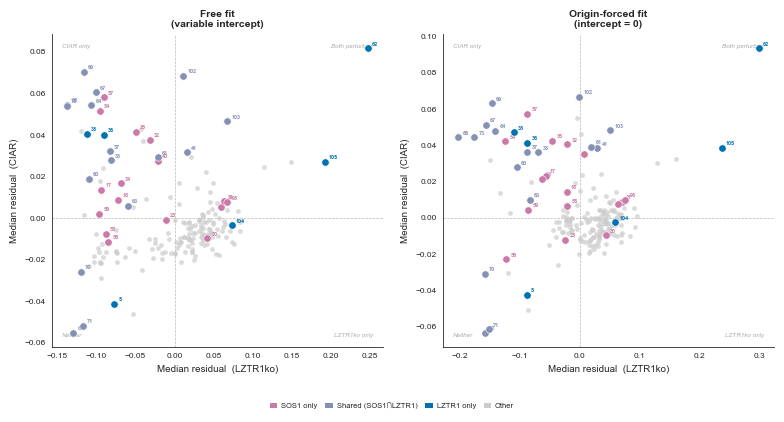

Positions plotted: 187  (matches pos_df: 187)


In [34]:
sns.set(style='white')
import matplotlib as mpl
from matplotlib.patches import Patch

mpl.rcParams.update({
    'font.family':        'Arial',
    'pdf.fonttype':       42,
    'svg.fonttype':       'none',
    'axes.linewidth':     0.6,
    'xtick.major.width':  0.6,
    'ytick.major.width':  0.6,
    'xtick.major.size':   2.5,
    'ytick.major.size':   2.5,
})

# ── Per-position medians from kras_residuals ───────────────────────────────────
# Inner merge ensures position coverage exactly matches pos_df
# (no extra positions from kras_residuals that weren't in the original pos_df)
_pos_resid = (
    kras_residuals
    .groupby('Position')[[
        'resid_LZTR1ko', 'resid_CIAR',
        'resid_free_LZTR1ko', 'resid_free_CIAR',
    ]]
    .median()
    .reset_index()
)
_pos_resid = _pos_resid.merge(
    pos_df[['Position', 'Interface', 'color']],
    on='Position', how='outer'
)

# ── Helper: draw one scatter panel ────────────────────────────────────────────
def _scatter_panel(ax, df, xcol, ycol, xlabel, ylabel, title):
    other = df[df['Interface'] == 'Other']
    ax.scatter(other[xcol], other[ycol],
               color='#CCCCCC', s=12, zorder=2, linewidths=0, alpha=0.7)

    for iface in ['SOS1 only', 'Shared (SOS1∩LZTR1)', 'LZTR1 only']:
        sub = df[df['Interface'] == iface]
        ax.scatter(sub[xcol], sub[ycol],
                   color=iface_colors[iface], s=28, zorder=4,
                   linewidths=0.4, edgecolors='white')
        for _, row in sub.iterrows():
            ax.annotate(f"{int(row['Position'])}",
                        (row[xcol], row[ycol]),
                        fontsize=4, xytext=(3, 2), textcoords='offset points',
                        color=iface_colors[iface], fontweight='bold')

    ax.axhline(0, color='#999', linewidth=0.5, linestyle='--', alpha=0.7, zorder=1)
    ax.axvline(0, color='#999', linewidth=0.5, linestyle='--', alpha=0.7, zorder=1)

    for txt, xy, ha, va in [
        ('Both perturbed', (0.97, 0.97), 'right', 'top'),
        ('CIAR only',      (0.03, 0.97), 'left',  'top'),
        ('LZTR1ko only',   (0.97, 0.03), 'right', 'bottom'),
        ('Neither',        (0.03, 0.03), 'left',  'bottom'),
    ]:
        ax.text(*xy, txt, transform=ax.transAxes, fontsize=4.5,
                color='#AAAAAA', ha=ha, va=va, style='italic')

    ax.set_xlabel(xlabel, fontsize=7)
    ax.set_ylabel(ylabel, fontsize=7)
    ax.set_title(title, fontsize=7.5, fontweight='bold', pad=5)
    ax.tick_params(axis='both', labelsize=6, length=2.5, width=0.6, pad=2)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_linewidth(0.6)
    ax.spines['bottom'].set_linewidth(0.6)

# ── Figure: two panels side by side ──────────────────────────────────────────
fig, (ax_free, ax_orig) = plt.subplots(1, 2, figsize=(8.0, 4.0))
fig.subplots_adjust(wspace=0.40)

_scatter_panel(
    ax_free, _pos_resid,
    xcol='resid_free_LZTR1ko', ycol='resid_free_CIAR',
    xlabel='Median residual  (LZTR1ko)', ylabel='Median residual  (CIAR)',
    title='Free fit\n(variable intercept)',
)
_scatter_panel(
    ax_orig, _pos_resid,
    xcol='resid_LZTR1ko', ycol='resid_CIAR',
    xlabel='Median residual  (LZTR1ko)', ylabel='Median residual  (CIAR)',
    title='Origin-forced fit\n(intercept = 0)',
)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_handles = [
    Patch(facecolor=iface_colors[l], edgecolor='none', label=l)
    for l in ['SOS1 only', 'Shared (SOS1∩LZTR1)', 'LZTR1 only']
]
legend_handles.append(Patch(facecolor='#CCCCCC', edgecolor='none', label='Other'))
fig.legend(handles=legend_handles,
           loc='lower center', bbox_to_anchor=(0.5, -0.06),
           ncol=4, fontsize=5.5, frameon=False,
           handlelength=1.0, handletextpad=0.5, columnspacing=1.0)

fig.tight_layout()
plt.savefig(os.path.join(output_folder, 'KRAS_position_residual_scatter.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_position_residual_scatter.svg'),
            bbox_inches='tight')
plt.show()
print(f"Positions plotted: {len(_pos_resid)}  (matches pos_df: {len(pos_df)})")


LZTR1koCIAR ~ LZTR1ko  →  slope=0.609  intercept=0.0345  R²=0.817
Positions: 187  |  Contact: 38


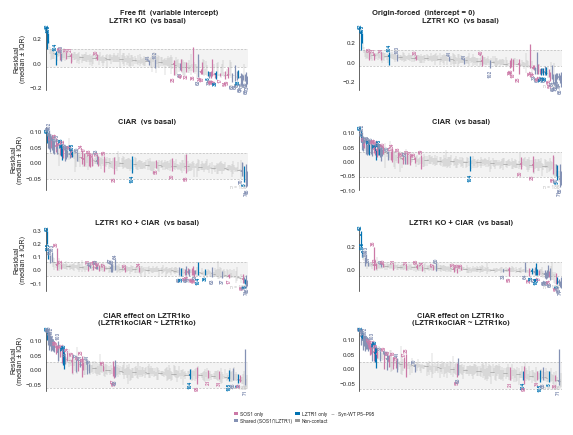

Saved.


In [35]:
# ── 4-row × 2-col ranked residual figure ──────────────────────────────────────
# Left column:  free-fit (variable intercept) residuals
# Right column: origin-forced (intercept = 0) residuals
# diff_pos / syn_diff_iqr are also computed below for use by downstream cells.

from scipy.stats import linregress as _lr
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

NON_CONTACT_COLOR = '#999999'

def mini_lollipop(ax, df_sorted, med_col, q25_col, q75_col,
                  syn_p05, syn_p95, title, ylabel):
    """Compact lollipop: IQR stem + median tick per position.
    Syn-WT IQR shown as a shaded band + dashed lines.
    Contact residues labelled with position numbers (rotated 90°);
    non-contact residues drawn in gray without labels.
    """
    n    = len(df_sorted)
    rows = list(df_sorted.iterrows())

    # Syn-WT P5–P95 reference band
    ax.axhspan(syn_p05, syn_p95, facecolor='#F2F2F2', linewidth=0, zorder=0, alpha=0.9)
    ax.axhline(syn_p05, color='#BBBBBB', linewidth=0.5, linestyle='--', dashes=(3, 2), zorder=1)
    ax.axhline(syn_p95, color='#BBBBBB', linewidth=0.5, linestyle='--', dashes=(3, 2), zorder=1)

    for i, (_, row) in enumerate(rows):
        is_contact = row['Interface'] != 'Other'
        color  = row['color'] if is_contact else NON_CONTACT_COLOR
        med    = row[med_col]
        q25    = row[q25_col]
        q75    = row[q75_col]
        lw     = 0.9 if is_contact else 0.35
        alpha  = 1.0 if is_contact else 0.65
        zorder = 4 if is_contact else 2

        # IQR stem
        ax.vlines(i, q25, q75, color=color, linewidth=lw, alpha=alpha, zorder=zorder)

        # Median tick
        tick_w = 0.30 if is_contact else 0.16
        ax.plot([i - tick_w, i + tick_w], [med, med],
                color=color,
                linewidth=1.1 if is_contact else 0.55,
                solid_capstyle='butt', zorder=zorder + 1)

        # Label contact residues only
        if is_contact:
            y_rng = max(abs(q75 - q25), 0.01)
            if med >= 0:
                y_txt, va = q75 + y_rng * 0.08, 'bottom'
            else:
                y_txt, va = q25 - y_rng * 0.08, 'top'
            ax.text(i, y_txt, str(int(row['Position'])),
                    fontsize=3.5, ha='center', va=va,
                    color=color, fontweight='bold',
                    rotation=90, zorder=6)

    ax.set_xticks([])
    ax.set_xlim(-1, n)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=5, labelpad=2)
    if title:
        ax.set_title(title, fontsize=5.5, fontweight='bold', pad=3)
    ax.tick_params(axis='y', labelsize=4.5, length=2, width=0.5, pad=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.text(0.99, 0.02, f'n = {n}', transform=ax.transAxes,
            fontsize=3.5, ha='right', va='bottom', color='#BBBBBB')


# ── Panel definitions: (title, free-fit spec, origin-forced spec) ──────────────
# Each spec: (median_col, q25_col, q75_col, syn_iqr_key)
_panels = [
    (
        'LZTR1 KO  (vs basal)',
        ('resid_free_LZTR1ko_median',
         'resid_free_LZTR1ko_q25',
         'resid_free_LZTR1ko_q75',
         'resid_free_LZTR1ko'),
        ('lztr1ko_median',
         'lztr1ko_q25',
         'lztr1ko_q75',
         'resid_LZTR1ko'),
    ),
    (
        'CIAR  (vs basal)',
        ('resid_free_CIAR_median',
         'resid_free_CIAR_q25',
         'resid_free_CIAR_q75',
         'resid_free_CIAR'),
        ('ciar_median',
         'ciar_q25',
         'ciar_q75',
         'resid_CIAR'),
    ),
    (
        'LZTR1 KO + CIAR  (vs basal)',
        ('resid_free_LZTR1koCIAR_median',
         'resid_free_LZTR1koCIAR_q25',
         'resid_free_LZTR1koCIAR_q75',
         'resid_free_LZTR1koCIAR'),
        ('lzciar_median',
         'lzciar_q25',
         'lzciar_q75',
         'resid_LZTR1koCIAR'),
    ),
    (
        'CIAR effect on LZTR1ko\n(LZTR1koCIAR ~ LZTR1ko)',
        ('resid_free_LZTR1koCIAR_on_LZTR1ko_median',
         'resid_free_LZTR1koCIAR_on_LZTR1ko_q25',
         'resid_free_LZTR1koCIAR_on_LZTR1ko_q75',
         'resid_free_LZTR1koCIAR_on_LZTR1ko'),
        ('resid_LZTR1koCIAR_on_LZTR1ko_median',
         'resid_LZTR1koCIAR_on_LZTR1ko_q25',
         'resid_LZTR1koCIAR_on_LZTR1ko_q75',
         'resid_LZTR1koCIAR_on_LZTR1ko'),
    ),
]


# ── Difference scores (kept for downstream cells) ──────────────────────────────
_SCORE      = 'intercept_0_standard-adjusted score'
_COL_BASAL  = f'{_SCORE}__abundance__No_treatment'
_COL_LZ     = f'{_SCORE}__abundance__LZTR1ko'
_COL_CIAR   = f'{_SCORE}__abundance__CIAR'
_COL_LZCIAR = f'{_SCORE}__abundance__LZTR1koCIAR'

_mis2 = kras_Replicate_scores_wide[
    kras_Replicate_scores_wide['Mutation Type'] == 'missense'
].copy()
_mis2['Position'] = pd.to_numeric(_mis2['Position'], errors='coerce')
_mis2 = _mis2.dropna(subset=['Position', _COL_BASAL])
_mis2['Position'] = _mis2['Position'].astype(int)

_mis2['diff_LZTR1ko']     = _mis2[_COL_LZ]    - _mis2[_COL_BASAL]
_mis2['diff_CIAR']        = _mis2[_COL_CIAR]   - _mis2[_COL_BASAL]
_mis2['diff_LZTR1koCIAR'] = _mis2[_COL_LZCIAR] - _mis2[_COL_BASAL]

_mask_lz = _mis2[_COL_LZ].notna() & _mis2[_COL_LZCIAR].notna()
_sl, _ic, _r, _p, _ = _lr(_mis2.loc[_mask_lz, _COL_LZ],
                            _mis2.loc[_mask_lz, _COL_LZCIAR])
_mis2['resid_CIAR_on_LZ'] = _mis2[_COL_LZCIAR] - (_sl * _mis2[_COL_LZ] + _ic)
print(f"LZTR1koCIAR ~ LZTR1ko  →  slope={_sl:.3f}  intercept={_ic:.4f}  R²={_r**2:.3f}")

def _q25d(x): return x.quantile(0.25)
def _q75d(x): return x.quantile(0.75)

diff_pos = _mis2.groupby('Position').agg(
    diff_lz_median       = ('diff_LZTR1ko',     'median'),
    diff_lz_q25          = ('diff_LZTR1ko',     _q25d),
    diff_lz_q75          = ('diff_LZTR1ko',     _q75d),
    diff_ciar_median     = ('diff_CIAR',        'median'),
    diff_ciar_q25        = ('diff_CIAR',        _q25d),
    diff_ciar_q75        = ('diff_CIAR',        _q75d),
    diff_lzciar_median   = ('diff_LZTR1koCIAR', 'median'),
    diff_lzciar_q25      = ('diff_LZTR1koCIAR', _q25d),
    diff_lzciar_q75      = ('diff_LZTR1koCIAR', _q75d),
    resid_ciar_lz_median = ('resid_CIAR_on_LZ', 'median'),
    resid_ciar_lz_q25    = ('resid_CIAR_on_LZ', _q25d),
    resid_ciar_lz_q75    = ('resid_CIAR_on_LZ', _q75d),
).reset_index()

diff_pos['Interface'] = diff_pos['Position'].astype(str).map(interface_map).fillna('Other')
diff_pos['color']     = diff_pos['Interface'].map(iface_colors)

_syn2 = kras_Replicate_scores_wide[
    kras_Replicate_scores_wide['Mutation Type'] == 'synonymous wild type'
].copy()
_syn2['Position'] = pd.to_numeric(_syn2['Position'], errors='coerce')
_syn2 = _syn2.dropna(subset=[_COL_BASAL])

syn_diff_iqr = {}
for _tc, _key in [(_COL_LZ, 'LZTR1ko'), (_COL_CIAR, 'CIAR'), (_COL_LZCIAR, 'LZTR1koCIAR')]:
    _m   = _syn2[_COL_BASAL].notna() & _syn2[_tc].notna()
    _d   = _syn2.loc[_m, _tc] - _syn2.loc[_m, _COL_BASAL]
    syn_diff_iqr[_key] = {'q25': _d.quantile(0.25), 'q75': _d.quantile(0.75)}

_mask_syn_lz = _syn2[_COL_LZ].notna() & _syn2[_COL_LZCIAR].notna()
_syn_r = _syn2.loc[_mask_syn_lz, _COL_LZCIAR] - (_sl * _syn2.loc[_mask_syn_lz, _COL_LZ] + _ic)
syn_diff_iqr['resid_CIAR_on_LZ'] = {'q25': _syn_r.quantile(0.25), 'q75': _syn_r.quantile(0.75)}

print(f"Positions: {len(diff_pos)}  |  Contact: {(diff_pos['Interface'] != 'Other').sum()}")


# ── Figure: 4 rows × 2 columns ─────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(6.0, 4.5),
                          gridspec_kw=dict(hspace=0.6, wspace=0.55))
fig.subplots_adjust(left=0.11, right=0.97, top=0.87, bottom=0.06)

# Column headers
fig.text(0.315, 0.895, 'Free fit  (variable intercept)',
         ha='center', va='bottom', fontsize=5.5, fontweight='bold')
fig.text(0.740, 0.895, 'Origin-forced  (intercept = 0)',
         ha='center', va='bottom', fontsize=5.5, fontweight='bold')

for row_idx, (title, free_spec, orig_spec) in enumerate(_panels):
    for col_idx, (med_col, q25_col, q75_col, syn_key) in enumerate([free_spec, orig_spec]):
        df_sorted = pos_df.dropna(subset=[med_col]).sort_values(med_col, ascending=False)
        mini_lollipop(
            axes[row_idx, col_idx], df_sorted,
            med_col, q25_col, q75_col,
            syn_iqr[syn_key]['p05'], syn_iqr[syn_key]['p95'],
            title=title,
            ylabel='Residual\n(median ± IQR)' if col_idx == 0 else '',
        )

# ── Legend ─────────────────────────────────────────────────────────────────────
handles = [
    Patch(facecolor=iface_colors[l], edgecolor='none', label=l)
    for l in ['SOS1 only', 'Shared (SOS1∩LZTR1)', 'LZTR1 only']
] + [
    Patch(facecolor=NON_CONTACT_COLOR, edgecolor='none', label='Non-contact'),
    Line2D([0], [0], color='#BBBBBB', linewidth=0.7, linestyle='--',
           dashes=(3, 2), label='Syn-WT P5–P95'),
]
fig.legend(handles=handles,
           loc='lower center', bbox_to_anchor=(0.54, -0.02),
           ncol=3, fontsize=3.5, frameon=False,
           handlelength=0.9, handletextpad=0.4,
           columnspacing=0.7, labelspacing=0.35)

plt.savefig(os.path.join(output_folder, 'KRAS_position_residual_4panel.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_position_residual_4panel.svg'),
            bbox_inches='tight')
plt.show()
print("Saved.")


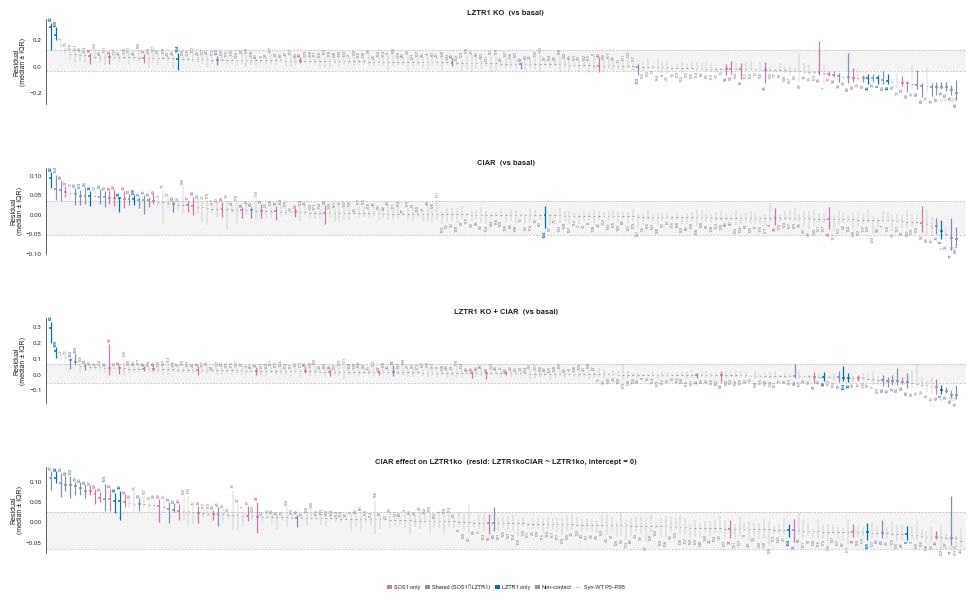

Saved → KRAS_position_residual_4panel_labelled.pdf / .svg


In [36]:
# ── 4-panel ranked residual figure — all positions labelled (rotated 90°) ──────
# All 4 panels are residuals (same data as compact figure above).

NON_CONTACT_COLOR = '#999999'

def _mini_lollipop_labelled(ax, df_sorted, med_col, q25_col, q75_col,
                             syn_p05, syn_p95, title, ylabel):
    """Like mini_lollipop but writes position numbers above every bar."""
    n    = len(df_sorted)
    rows = list(df_sorted.iterrows())

    ax.axhspan(syn_p05, syn_p95, facecolor='#F2F2F2', linewidth=0, zorder=0, alpha=0.9)
    ax.axhline(syn_p05, color='#BBBBBB', linewidth=0.5, linestyle='--', dashes=(3, 2), zorder=1)
    ax.axhline(syn_p95, color='#BBBBBB', linewidth=0.5, linestyle='--', dashes=(3, 2), zorder=1)

    for i, (_, row) in enumerate(rows):
        is_contact = row['Interface'] != 'Other'
        color  = row['color'] if is_contact else NON_CONTACT_COLOR
        med    = row[med_col]
        q25    = row[q25_col]
        q75    = row[q75_col]
        lw     = 0.9 if is_contact else 0.35
        alpha  = 1.0 if is_contact else 0.70
        zorder = 4 if is_contact else 2

        ax.vlines(i, q25, q75, color=color, linewidth=lw, alpha=alpha, zorder=zorder)

        tick_w = 0.30 if is_contact else 0.16
        ax.plot([i - tick_w, i + tick_w], [med, med],
                color=color,
                linewidth=1.1 if is_contact else 0.55,
                solid_capstyle='butt', zorder=zorder + 1)

        # Position label above Q75 (positive median) or below Q25 (negative)
        y_rng = max(abs(q75 - q25), 0.01)
        if med >= 0:
            y_txt, va = q75 + y_rng * 0.08, 'bottom'
        else:
            y_txt, va = q25 - y_rng * 0.08, 'top'
        ax.text(i, y_txt, str(int(row['Position'])),
                fontsize=3.2, ha='center', va=va,
                color=color if is_contact else '#888888',
                fontweight='bold' if is_contact else 'normal',
                rotation=90, zorder=6)

    ax.set_xticks([])
    ax.set_xlim(-1, n)
    ax.set_ylabel(ylabel, fontsize=5, labelpad=2)
    ax.set_title(title, fontsize=5.5, fontweight='bold', pad=3)
    ax.tick_params(axis='y', labelsize=4.5, length=2, width=0.5, pad=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.text(0.99, 0.02, f'n = {n}', transform=ax.transAxes,
            fontsize=3.5, ha='right', va='bottom', color='#BBBBBB')


fig, axes = plt.subplots(4, 1, figsize=(10, 6),
                          gridspec_kw=dict(hspace=0.75))
fig.subplots_adjust(left=0.06, right=0.98, top=0.93, bottom=0.04)

_mini_lollipop_labelled(
    axes[0],
    pos_df.sort_values('lztr1ko_median', ascending=False),
    'lztr1ko_median', 'lztr1ko_q25', 'lztr1ko_q75',
    syn_iqr['resid_LZTR1ko']['p05'], syn_iqr['resid_LZTR1ko']['p95'],
    title='LZTR1 KO  (vs basal)', ylabel='Residual\n(median ± IQR)',
)
_mini_lollipop_labelled(
    axes[1],
    pos_df.sort_values('ciar_median', ascending=False),
    'ciar_median', 'ciar_q25', 'ciar_q75',
    syn_iqr['resid_CIAR']['p05'], syn_iqr['resid_CIAR']['p95'],
    title='CIAR  (vs basal)', ylabel='Residual\n(median ± IQR)',
)
_mini_lollipop_labelled(
    axes[2],
    pos_df.sort_values('lzciar_median', ascending=False),
    'lzciar_median', 'lzciar_q25', 'lzciar_q75',
    syn_iqr['resid_LZTR1koCIAR']['p05'], syn_iqr['resid_LZTR1koCIAR']['p95'],
    title='LZTR1 KO + CIAR  (vs basal)', ylabel='Residual\n(median ± IQR)',
)
_mini_lollipop_labelled(
    axes[3],
    pos_df.dropna(subset=['resid_LZTR1koCIAR_on_LZTR1ko_median']).sort_values('resid_LZTR1koCIAR_on_LZTR1ko_median', ascending=False),
    'resid_LZTR1koCIAR_on_LZTR1ko_median', 'resid_LZTR1koCIAR_on_LZTR1ko_q25', 'resid_LZTR1koCIAR_on_LZTR1ko_q75',
    syn_iqr['resid_LZTR1koCIAR_on_LZTR1ko']['p05'], syn_iqr['resid_LZTR1koCIAR_on_LZTR1ko']['p95'],
    title='CIAR effect on LZTR1ko  (resid: LZTR1koCIAR ~ LZTR1ko, intercept = 0)',
    ylabel='Residual\n(median ± IQR)',
)

# ── Legend ─────────────────────────────────────────────────────────────────────
handles = [
    Patch(facecolor=iface_colors[l], edgecolor='none', label=l)
    for l in ['SOS1 only', 'Shared (SOS1∩LZTR1)', 'LZTR1 only']
] + [
    Patch(facecolor=NON_CONTACT_COLOR, edgecolor='none', label='Non-contact'),
    Line2D([0], [0], color='#BBBBBB', linewidth=0.7, linestyle='--',
           dashes=(3, 2), label='Syn-WT P5–P95'),
]
fig.legend(handles=handles,
           loc='lower center', bbox_to_anchor=(0.52, -0.03),
           ncol=5, fontsize=4, frameon=False,
           handlelength=0.9, handletextpad=0.4,
           columnspacing=0.8, labelspacing=0.35)

plt.savefig(os.path.join(output_folder, 'KRAS_position_residual_4panel_labelled.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_position_residual_4panel_labelled.svg'),
            bbox_inches='tight')
plt.show()
print("Saved → KRAS_position_residual_4panel_labelled.pdf / .svg")


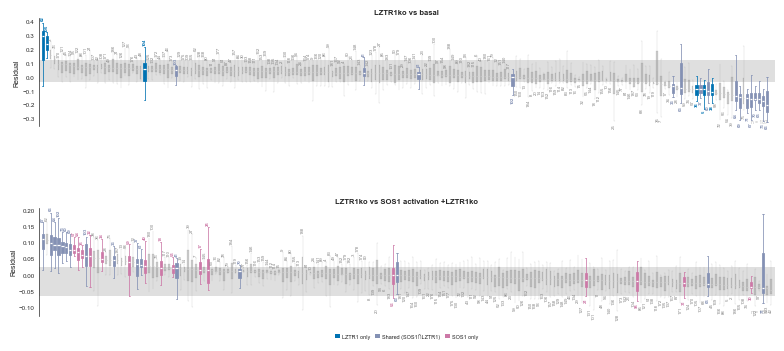

Saved → KRAS_position_residual_4panel_boxplot.pdf / .svg


In [68]:
# ── 4-panel boxplot figure — per-position distributions, all positions labelled ─
# Same ordering as the lollipop version above, but each position is shown as a
# full boxplot (Q1–Q3 box, median line, 1.5×IQR whiskers) drawn from the raw
# per-variant residuals in kras_residuals. Grey band = syn-WT P5–P95 (no border lines).
#
# highlight_ifaces : set of Interface strings to colour (others rendered as grey).
#   Top panel    → LZTR1-only + Shared contacts
#   Bottom panel → SOS1-only  + Shared contacts

NON_CONTACT_COLOR = '#999999'

def _boxplot_panel(ax, pos_sorted, resid_col, syn_p05, syn_p95, title, ylabel,
                   highlight_ifaces=None):
    """
    highlight_ifaces : set of Interface label strings to colour.
                       Positions whose Interface is NOT in this set are drawn grey.
                       Default (None) colours all non-'Other' interfaces.
    """
    if highlight_ifaces is None:
        highlight_ifaces = {'SOS1 only', 'Shared (SOS1∩LZTR1)', 'LZTR1 only'}

    n = len(pos_sorted)

    # Syn-WT P5–P95 reference band (filled only, no boundary lines)
    ax.axhspan(syn_p05, syn_p95, facecolor='#DCDCDC', linewidth=0, zorder=0, alpha=0.9)

    # Pre-convert positions for fast lookup
    _kr = kras_residuals.copy()
    _kr['_pos_int'] = pd.to_numeric(_kr['Position'], errors='coerce').astype('Int64')

    for i, (_, row) in enumerate(pos_sorted.iterrows()):
        pos        = int(row['Position'])
        is_contact = row['Interface'] in highlight_ifaces
        color      = row['color'] if is_contact else NON_CONTACT_COLOR

        vals = _kr.loc[_kr['_pos_int'] == pos, resid_col].dropna().values
        if len(vals) < 2:
            continue

        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        iqr  = q3 - q1
        lo   = vals[vals >= q1 - 1.5 * iqr]
        hi   = vals[vals <= q3 + 1.5 * iqr]
        wlo  = lo.min() if len(lo) else q1
        whi  = hi.max() if len(hi) else q3

        bstats = [{'med': med, 'q1': q1, 'q3': q3,
                   'whislo': wlo, 'whishi': whi, 'fliers': []}]

        lw    = 0.55 if is_contact else 0.25
        alpha = 1.0  if is_contact else 0.50
        zord  = 4    if is_contact else 2

        bp = ax.bxp(bstats, positions=[i],
                    widths=0.55 if is_contact else 0.45,
                    patch_artist=True, showfliers=False,
                    manage_ticks=False, zorder=zord)

        bp['boxes'][0].set_facecolor(color)
        bp['boxes'][0].set_alpha(alpha)
        bp['boxes'][0].set_linewidth(lw)
        bp['boxes'][0].set_edgecolor(color)
        bp['medians'][0].set_color('white' if is_contact else '#CCCCCC')
        bp['medians'][0].set_linewidth(0.9 if is_contact else 0.5)
        for artist in bp['whiskers'] + bp['caps']:
            artist.set_color(color)
            artist.set_linewidth(lw)
            artist.set_alpha(alpha)

        # Position label above whishi (positive med) or below whislo (negative)
        pad = max(iqr * 0.10, 0.005)
        if med >= 0:
            y_txt, va = whi + pad, 'bottom'
        else:
            y_txt, va = wlo - pad, 'top'
        ax.text(i, y_txt, str(pos),
                fontsize=3.2, ha='center', va=va,
                color=color if is_contact else '#888888',
                fontweight='bold' if is_contact else 'normal',
                rotation=90, zorder=6)

    ax.set_xticks([])
    ax.set_xlim(-1, n)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=5, labelpad=2)
    ax.set_title(title, fontsize=5.5, fontweight='bold', pad=3)
    ax.tick_params(axis='y', labelsize=4.5, length=2, width=0.5, pad=1)
    for sp in ['top', 'right', 'bottom']:
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.text(0.99, 0.02, f'n = {n}', transform=ax.transAxes,
            fontsize=3.5, ha='right', va='bottom', color='#BBBBBB')


fig, axes = plt.subplots(2, 1, figsize=(8, 3.5),
                          gridspec_kw=dict(hspace=0.75))
fig.subplots_adjust(left=0.06, right=0.98, top=0.90, bottom=0.05)

# Top panel: colour LZTR1-only and Shared contacts; SOS1-only → grey
_boxplot_panel(
    axes[0],
    pos_df.sort_values('lztr1ko_median', ascending=False),
    'resid_LZTR1ko',
    syn_iqr['resid_LZTR1ko']['p05'], syn_iqr['resid_LZTR1ko']['p95'],
    title='LZTR1ko vs basal', ylabel='Residual',
    highlight_ifaces={'LZTR1 only', 'Shared (SOS1∩LZTR1)'},
)

# Bottom panel: colour SOS1-only and Shared contacts; LZTR1-only → grey
_boxplot_panel(
    axes[1],
    pos_df.dropna(subset=['resid_LZTR1koCIAR_on_LZTR1ko_median']).sort_values(
        'resid_LZTR1koCIAR_on_LZTR1ko_median', ascending=False),
    'resid_LZTR1koCIAR_on_LZTR1ko',
    syn_iqr['resid_LZTR1koCIAR_on_LZTR1ko']['p05'],
    syn_iqr['resid_LZTR1koCIAR_on_LZTR1ko']['p95'],
    title='LZTR1ko vs SOS1 activation +LZTR1ko',
    ylabel='Residual',
    highlight_ifaces={'SOS1 only', 'Shared (SOS1∩LZTR1)'},
)

# ── Legend ─────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
handles = [
    Patch(facecolor=iface_colors['LZTR1 only'],          edgecolor='none', label='LZTR1 only'),
    Patch(facecolor=iface_colors['Shared (SOS1∩LZTR1)'], edgecolor='none', label='Shared (SOS1∩LZTR1)'),
    Patch(facecolor=iface_colors['SOS1 only'],            edgecolor='none', label='SOS1 only'),
]
fig.legend(handles=handles,
           loc='lower center', bbox_to_anchor=(0.52, -0.03),
           ncol=3, fontsize=4, frameon=False,
           handlelength=0.9, handletextpad=0.4,
           columnspacing=0.8, labelspacing=0.35)

plt.savefig(os.path.join(output_folder, 'KRAS_position_residual_4panel_boxplot.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_position_residual_4panel_boxplot.svg'),
            bbox_inches='tight')
plt.show()
print('Saved → KRAS_position_residual_4panel_boxplot.pdf / .svg')


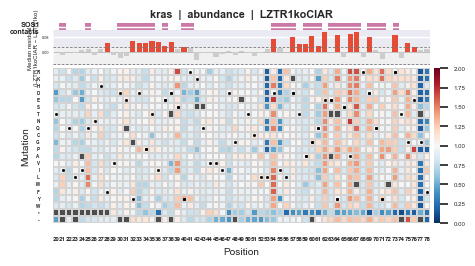

Saved → kras_LZTR1koCIAR_abundance_subset.svg / .pdf

Bar chart summary (20–78):
  Positions plotted      : 59
  Functionally perturbed : 23  (|residual| outside syn-WT P5–P95 for LZTR1koCIAR ~ LZTR1ko)
  Syn-WT band            : [-0.0666, 0.0242]


In [57]:
# ═══════════════════════════════════════════════════════════════════════════════
# LZTR1koCIAR Abundance Heatmap — SOS1 contacts, positions 20–78
#   Row 0 : SOS1 contact annotation bar
#   Row 1 : Median LZTR1koCIAR ~ LZTR1ko residual bar chart
#   Row 2 : spacer
#   Row 3 : DMS heatmap + colorbar
# ═══════════════════════════════════════════════════════════════════════════════
from matplotlib import gridspec as mpl_gs
import matplotlib.colors as mcolors

# ── Parameters ────────────────────────────────────────────────────────────────
_ASSAY      = 'abundance'
_TREATMENT  = 'LZTR1koCIAR'
_PROTEIN    = 'kras'
_SCORE_COL  = 'average score'
_SCALE_TYPE = 'linear'
_FIRST_POS  = 20
_LAST_POS   = 78
_FIGSIZE    = (5, 2)
_FONT_SCALE = 0.4
_MISS_CLR   = '#4d4d4d'

# ── Data prep ─────────────────────────────────────────────────────────────────
_hm = Replicate_scores.copy()
_hm = convert_AA_abbreviation(_hm)

_combo = _hm[
    (_hm['assay']           == _ASSAY) &
    (_hm['assay_treatment'] == _TREATMENT) &
    (_hm['protein']         == _PROTEIN)
].copy()
_combo['Position'] = pd.to_numeric(_combo['Position'], errors='coerce')
_combo = _combo.dropna(subset=['Position'])
_combo['Position'] = _combo['Position'].astype(int)
_combo = _combo[(_combo['Position'] >= _FIRST_POS) & (_combo['Position'] <= _LAST_POS)]

_wt_rows = _combo[_combo['Mutation Type'].str.lower().str.contains('synonymous', na=False)].copy()

_pivot = (
    _combo.groupby(['Position', 'Mutation'])[_SCORE_COL]
    .mean().unstack().transpose()
)
_orders = ['R','K','H','D','E','S','T','N','Q','C','G','P','A','V','I','L','M','F','Y','W','*','-']
_pivot  = _pivot.reindex(_orders, axis=0)

n_pos = len(_pivot.columns)
n_aa  = len(_pivot)
_pos_list = list(_pivot.columns)
_aa_list  = list(_pivot.index)

# ── Scale-dependent sizing ─────────────────────────────────────────────────────
_fig_h    = _FIGSIZE[1]
_fig_w    = _FIGSIZE[0]
_msize    = (_fig_h / 6.14) * 5
_clab_sz  = (_fig_h / 6.14) * 16
_ytick_sz = (_fig_h / 6.14) * 10
_lab_sz   = (_fig_h / 6.14) * 22
_title_sz = (_fig_h / 6.14) * 24

vmin, vmax, center = get_scale(_ASSAY, _SCALE_TYPE, vmin=None, vmax=None, center=None)
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color=_MISS_CLR)
sns.set(font_scale=_FONT_SCALE)

# ── Median LZTR1koCIAR ~ LZTR1ko residual per position ───────────────────────
_resid_map = pos_df.set_index('Position')['resid_LZTR1koCIAR_on_LZTR1ko_median']
_bar_vals  = np.array([_resid_map.get(p, np.nan) for p in _pos_list])

_bnd_lo = syn_iqr['resid_LZTR1koCIAR_on_LZTR1ko']['p05']
_bnd_hi = syn_iqr['resid_LZTR1koCIAR_on_LZTR1ko']['p95']

_ciar_func_pos = set(bdf.loc[bdf['lzciar_perturbed'], 'Position'].astype(int))
_bar_clrs = [
    SOS1_FUNC_COLOR if (not np.isnan(v) and p in _ciar_func_pos) else '#CCCCCC'
    for v, p in zip(_bar_vals, _pos_list)
]

# ── GridSpec ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(_fig_w, _fig_h + 0.6))
gs  = mpl_gs.GridSpec(
    4, 2, figure=fig,
    height_ratios=[1, 5, 0.4, n_aa],
    width_ratios=[n_pos, max(1, n_pos // 60)],
    hspace=0.0, wspace=0.02,
)
ax_sos1  = fig.add_subplot(gs[0, 0])
ax_bar   = fig.add_subplot(gs[1, 0])
ax_hm    = fig.add_subplot(gs[3, 0])
ax_cbar  = fig.add_subplot(gs[3, 1])

# ── Row 0: SOS1 contact annotation bar ───────────────────────────────────────
_rgba = np.ones((1, n_pos, 4), dtype=float)
for j, pos in enumerate(_pos_list):
    if pos in kras_sos1_pos:
        _rgba[0, j] = mcolors.to_rgba(SOS1_COLOR)
ax_sos1.imshow(_rgba, aspect='auto', interpolation='none',
               extent=[0, n_pos, 0, 1])
ax_sos1.set_yticks([0.5])
ax_sos1.set_yticklabels(['SOS1\ncontacts'], fontsize=_clab_sz, fontweight='bold')
ax_sos1.set_xlim(0, n_pos)
ax_sos1.set_ylim(0, 1)
ax_sos1.set_xticks([])
ax_sos1.tick_params(left=False)
for _sp in ax_sos1.spines.values(): _sp.set_visible(False)
ax_sos1.set_title(
    f"{_PROTEIN}  |  {_ASSAY}  |  {_TREATMENT}",
    fontsize=_title_sz, fontweight='bold', pad=4,
)

# ── Row 1: Median LZTR1koCIAR ~ LZTR1ko residual bar chart ───────────────────
_bx = np.arange(n_pos) + 0.5

ax_bar.bar(_bx, _bar_vals, width=0.8, color=_bar_clrs, linewidth=0, zorder=3)

ax_bar.axhspan(_bnd_lo, _bnd_hi, color='#F0F0F0', linewidth=0, zorder=1)
ax_bar.axhline(_bnd_lo, color='#777777', linewidth=0.6,
               linestyle='--', dashes=(3, 2), zorder=4)
ax_bar.axhline(_bnd_hi, color='#777777', linewidth=0.6,
               linestyle='--', dashes=(3, 2), zorder=4)
ax_bar.axhline(0, color='#AAAAAA', linewidth=0.5, zorder=2)

ax_bar.set_xlim(0, n_pos)
ax_bar.set_xticks([])
ax_bar.set_ylabel('Median residual\n(LZTR1koCIAR ~ LZTR1ko)',
                  fontsize=_clab_sz * 0.85, labelpad=2)
ax_bar.tick_params(axis='y', labelsize=_ytick_sz * 0.85,
                   length=1.5, width=0.4, pad=1)
ax_bar.yaxis.set_major_locator(plt.MaxNLocator(3, prune='both'))
for _sp in ['top', 'right', 'bottom']:
    ax_bar.spines[_sp].set_visible(False)
ax_bar.spines['left'].set_linewidth(0.4)

# ── Row 3: DMS heatmap ────────────────────────────────────────────────────────
sns.heatmap(
    _pivot,
    cmap=cmap,
    vmin=vmin, vmax=vmax, center=center,
    ax=ax_hm,
    cbar=True, cbar_ax=ax_cbar,
    linewidths=0.3, linecolor='lightgrey',
)

for _, row in _wt_rows.iterrows():
    pos, wt_aa = row['Position'], row['Wild Type Residue']
    if pos in _pos_list and wt_aa in _aa_list:
        ax_hm.plot(
            _pos_list.index(pos) + 0.5,
            _aa_list.index(wt_aa) + 0.5,
            'o', color='black',
            markersize=_msize,
            markeredgewidth=_msize * 0.3,
            zorder=5,
        )

ax_hm.set_xlabel('Position', fontsize=_lab_sz, fontfamily='sans-serif')
ax_hm.set_ylabel('Mutation', fontsize=_lab_sz, fontfamily='sans-serif')
ax_hm.tick_params(left=False, bottom=False)
ax_hm.set_yticks([i + 0.5 for i in range(len(_aa_list))])
ax_hm.set_yticklabels(
    _aa_list, fontsize=_ytick_sz, fontweight='bold',
    fontfamily='sans-serif', rotation=0,
)
for lbl in ax_hm.get_xticklabels():
    lbl.set_fontweight('bold')
    lbl.set_fontfamily('sans-serif')
    lbl.set_rotation(0)

plt.rcParams['pdf.fonttype'] = 42
plt.tight_layout()

plt.savefig('/Users/jsimon/Downloads/kras_LZTR1koCIAR_abundance_subset.svg')
plt.savefig(os.path.join(output_folder, 'kras_LZTR1koCIAR_abundance_subset.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()
print("Saved → kras_LZTR1koCIAR_abundance_subset.svg / .pdf")
print(f"\nBar chart summary ({_FIRST_POS}–{_LAST_POS}):")
print(f"  Positions plotted      : {n_pos}")
print(f"  Functionally perturbed : {sum(p in _ciar_func_pos for p in _pos_list)}"
      f"  (|residual| outside syn-WT P5–P95 for LZTR1koCIAR ~ LZTR1ko)")
print(f"  Syn-WT band            : [{_bnd_lo:.4f}, {_bnd_hi:.4f}]")


# Classify positions as functional LZTR1 or GEF interactions

In [38]:
# ── bdf setup: bifunctional perturbation flags ────────────────────────────────────────────
# Run this once after pos_df and syn_iqr are defined.
# bdf is required by all downstream bifunctional analysis and PyMOL cells.
#
# Functional threshold = 5th–95th percentile of the syn-WT residual distribution
# under the origin-forced (intercept = 0) fit.
#
#   lz_perturbed:    LZTR1ko vs basal              (resid_LZTR1ko)
#   lzciar_perturbed: LZTR1koCIAR vs LZTR1ko       (resid_LZTR1koCIAR_on_LZTR1ko)

# P5/P95 thresholds pulled directly from syn_iqr (computed in harmonized cell above)
lz_p05,     lz_p95     = (syn_iqr['resid_LZTR1ko']['p05'],
                           syn_iqr['resid_LZTR1ko']['p95'])
lzciar_p05, lzciar_p95 = (syn_iqr['resid_LZTR1koCIAR_on_LZTR1ko']['p05'],
                           syn_iqr['resid_LZTR1koCIAR_on_LZTR1ko']['p95'])

print('Syn-WT residual thresholds (origin-forced fit, intercept = 0):')
print(f"  LZTR1ko                   P5 = {lz_p05:.4f}   P95 = {lz_p95:.4f}"
      f"   (n = {syn_iqr['resid_LZTR1ko']['n']})")
print(f"  LZTR1koCIAR on LZTR1ko   P5 = {lzciar_p05:.4f}   P95 = {lzciar_p95:.4f}"
      f"   (n = {syn_iqr['resid_LZTR1koCIAR_on_LZTR1ko']['n']})")

# ── Functional flags ──────────────────────────────────────────────────────────────────────
def _outside_pct(val, p05, p95):
    """True if val falls outside the 5th–95th percentile of syn-WT residuals."""
    return (val < p05) | (val > p95)

_lzciar_col = 'resid_LZTR1koCIAR_on_LZTR1ko_median'

bdf = pos_df.copy()
bdf['lz_perturbed']     = _outside_pct(bdf['lztr1ko_median'], lz_p05,     lz_p95)
bdf['lzciar_perturbed'] = _outside_pct(bdf[_lzciar_col],      lzciar_p05, lzciar_p95)
bdf['bifunctional']     = bdf['lz_perturbed'] & bdf['lzciar_perturbed']
bdf['same_sign']        = np.sign(bdf['lztr1ko_median']) == np.sign(bdf[_lzciar_col])
bdf['delta']            = bdf[_lzciar_col] - bdf['lztr1ko_median']   # CIAR-added effect
bdf['bifunc_score']     = bdf['lztr1ko_median'].abs() * bdf[_lzciar_col].abs()

lzko_only   = bdf['lz_perturbed']    & ~bdf['lzciar_perturbed']
lzciar_only = bdf['lzciar_perturbed'] & ~bdf['lz_perturbed']

print(f"\nPositions perturbed in LZTR1ko (any):              {bdf['lz_perturbed'].sum()}")
print(f"Positions perturbed in LZTR1ko only (not CIAR):    {lzko_only.sum()}")
print(f"\nPositions perturbed in LZTR1koCIAR/LZTR1ko (any): {bdf['lzciar_perturbed'].sum()}")
print(f"Positions perturbed in LZTR1koCIAR only (not LZ):  {lzciar_only.sum()}")
print(f"\nBifunctional (perturbed in both):                  {bdf['bifunctional'].sum()}")
print(f"  of which same-sign (consistent direction):        {(bdf['bifunctional'] & bdf['same_sign']).sum()}")
print(f"  of which opposite-sign (divergent direction):     {(bdf['bifunctional'] & ~bdf['same_sign']).sum()}")


Syn-WT residual thresholds (origin-forced fit, intercept = 0):
  LZTR1ko                   P5 = -0.0376   P95 = 0.1220   (n = 180)
  LZTR1koCIAR on LZTR1ko   P5 = -0.0666   P95 = 0.0242   (n = 180)

Positions perturbed in LZTR1ko (any):              36
Positions perturbed in LZTR1ko only (not CIAR):    16

Positions perturbed in LZTR1koCIAR/LZTR1ko (any): 30
Positions perturbed in LZTR1koCIAR only (not LZ):  10

Bifunctional (perturbed in both):                  20
  of which same-sign (consistent direction):        2
  of which opposite-sign (divergent direction):     18


In [39]:

import subprocess

NB_DIR   = '/Users/jsimon/Library/Mobile Documents/com~apple~CloudDocs/Documents/Lab/**RNABinderProject/MAPK_collab/Code Notebooks/LABEL-seq Assays/LABELseq_pathway_analyses'
CIF_PATH = f'{NB_DIR}/9MF0.cif'
PYMOL    = '/opt/anaconda3/envs/jlab4/bin/pymol'

# ── Classify each position ────────────────────────────────────────────────────
lztr1_contact_str = {str(p) for p in (lztr1_only_int | shared_pos_int)}

def classify(row):
    is_lztr1_contact = str(int(row['Position'])) in lztr1_contact_str
    perturbed        = bool(row['lz_perturbed'])
    if is_lztr1_contact and perturbed:
        return 'direct'
    elif perturbed:
        return 'indirect'
    else:
        return 'nonfunctional'

bdf['struct_class'] = bdf.apply(classify, axis=1)

class_colors = {
    'direct':        [0.93, 0.29, 0.13],
    'indirect':      [0.22, 0.64, 0.78],
    'nonfunctional': [0.80, 0.80, 0.80],
}

pos_by_class = {'direct': [], 'indirect': [], 'nonfunctional': []}
for _, row in bdf.iterrows():
    pos_by_class[row['struct_class']].append(int(row['Position']))

def resi_str(pos_list):
    return '+'.join(str(p) for p in sorted(pos_list))

direct_resi   = resi_str(pos_by_class['direct'])
indirect_resi = resi_str(pos_by_class['indirect'])
dc = class_colors['direct']
ic = class_colors['indirect']
nc = class_colors['nonfunctional']

# ── Generate 4 candidate views ────────────────────────────────────────────────
# KRAS: surface (colored by class) + cartoon for SS context
# LZTR1: cartoon, warm tan, opaque — clearly distinct from KRAS
views = [
    ('1', 'turn y, 0',          'Default'),
    ('2', 'turn y, 90',         '+90° Y'),
    ('3', 'turn y, 180',        '+180° Y'),
    ('4', 'turn y, -90',        '-90° Y'),
]

pml_template = """\
load {cif}, raw
create kras_chain, raw and chain A
create lztr1_chain, raw and chain B
delete raw

hide everything
bg_color white

# KRAS: surface + cartoon
show surface, kras_chain
show cartoon, kras_chain

# LZTR1: cartoon only, warm wheat — clearly distinct
set_color col_lztr1, [0.90, 0.83, 0.70]
color col_lztr1, lztr1_chain
show cartoon, lztr1_chain

# KRAS surface + cartoon coloured by class
set_color col_nonfunc,  [{nc0:.2f}, {nc1:.2f}, {nc2:.2f}]
set_color col_indirect, [{ic0:.2f}, {ic1:.2f}, {ic2:.2f}]
set_color col_direct,   [{dc0:.2f}, {dc1:.2f}, {dc2:.2f}]

color col_nonfunc, kras_chain
select sel_indirect, kras_chain and resi {indirect_resi}
color col_indirect, sel_indirect
select sel_direct, kras_chain and resi {direct_resi}
color col_direct, sel_direct

# Direct contacts as sticks on top of surface
show sticks, sel_direct
set stick_radius, 0.10
set stick_color, col_direct, sel_direct

# Surface quality
set surface_quality, 1
set surface_solvent, 0
set transparency, 0.0, kras_chain

# Cartoon styling
set cartoon_loop_radius, 0.20
set cartoon_tube_radius, 0.25
set cartoon_helix_radius, 0.75

# Rendering
set ray_shadows, 0
set antialias, 2
set ray_trace_mode, 1
set ray_opaque_background, on

orient all
{rotation}
zoom all, 4

ray 1200, 1200
png {png}, dpi=150
quit
"""

png_paths = {}
for vid, rotation, label in views:
    png_path = f'{output_folder}KRAS_9MF0_view{vid}.png'
    pml_path = f'{NB_DIR}/9MF0_view{vid}.pml'
    script   = pml_template.format(
        cif=CIF_PATH, png=png_path,
        nc0=nc[0], nc1=nc[1], nc2=nc[2],
        ic0=ic[0], ic1=ic[1], ic2=ic[2],
        dc0=dc[0], dc1=dc[1], dc2=dc[2],
        indirect_resi=indirect_resi,
        direct_resi=direct_resi,
        rotation=rotation,
    )
    with open(pml_path, 'w') as f:
        f.write(script)
    result = subprocess.run([PYMOL, '-cq', pml_path],
                            capture_output=True, text=True, timeout=120)
    if result.returncode == 0:
        png_paths[label] = png_path
        print(f"View {vid} ({label}) — OK")
    else:
        print(f"View {vid} ERROR:", result.stderr[-500:])


View 1 (Default) — OK
View 2 (+90° Y) — OK
View 3 (+180° Y) — OK
View 4 (-90° Y) — OK


  Both conditions          : 20 positions
  LZTR1                    : 16 positions
  GEF                      : 10 positions
  Neither                  : 141 positions
9MF0_default: OK
9MF0_180Y: OK
1NVU_default: OK
1NVU_180Y: OK


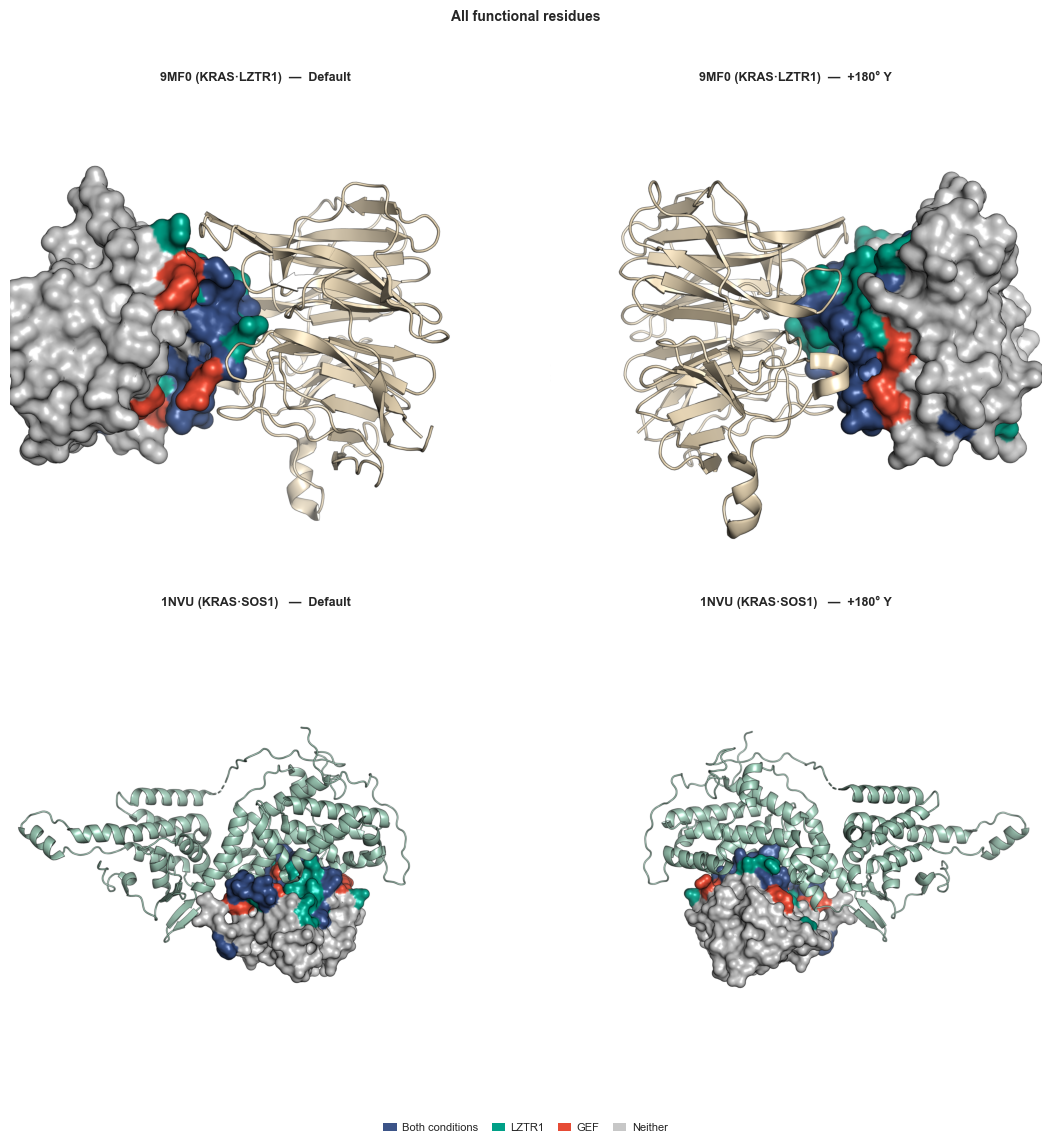

In [40]:

import subprocess, matplotlib.pyplot as plt, matplotlib.image as mpimg
from matplotlib.patches import Patch

NB_DIR = '/Users/jsimon/Library/Mobile Documents/com~apple~CloudDocs/Documents/Lab/**RNABinderProject/MAPK_collab/Code Notebooks/LABEL-seq Assays/LABELseq_pathway_analyses'
PYMOL  = '/opt/anaconda3/envs/jlab4/bin/pymol'

# ── 4-way classification ──────────────────────────────────────────────────────
def classify_overlap(row):
    lz     = bool(row['lz_perturbed'])
    lzciar = bool(row['lzciar_perturbed'])
    if lz and lzciar: return 'both'
    elif lz:          return 'lzko_only'
    elif lzciar:      return 'lzciar_only'
    else:             return 'neither'

bdf['overlap_class'] = bdf.apply(classify_overlap, axis=1)

# NPG-inspired palette — matches master palette (cell 13)
# lzko_only  = LZTR1 → teal-green  (LZTR1_FUNC_COLOR  #00A087)
# lzciar_only = SOS1 → coral-red   (SOS1_FUNC_COLOR   #E64B35)
overlap_colors = {
    'both':        [0.224, 0.318, 0.533],   # #3C5488 deep blue
    'lzko_only':   [0.000, 0.627, 0.529],   # #00A087 teal-green (LZTR1)
    'lzciar_only': [0.902, 0.294, 0.208],   # #E64B35 coral-red  (SOS1)
    'neither':     [0.780, 0.780, 0.780],   # #C7C7C7 grey
}
overlap_labels = {
    'both':        'Both conditions',
    'lzko_only':   'LZTR1',
    'lzciar_only': 'GEF',
    'neither':     'Neither',
}
overlap_hex = {
    'both': '#3C5488', 'lzko_only': '#00A087',
    'lzciar_only': '#E64B35', 'neither': '#C7C7C7',
}

pos_cls = {c: [] for c in overlap_colors}
for _, row in bdf.iterrows():
    pos_cls[row['overlap_class']].append(int(row['Position']))

for cls, lst in pos_cls.items():
    print(f"  {overlap_labels[cls]:25s}: {len(lst)} positions")

def resi_str(lst): return '+'.join(str(p) for p in sorted(lst))

def make_overlap_pml(cif_path, kras_chain, partner_chain, partner_color,
                     rotation_cmd, png_path, ray_size=2400):
    lines = [
        f"load {cif_path}, raw",
        f"create kras_chain, raw and chain {kras_chain}",
        f"create partner_chain, raw and chain {partner_chain}",
        "delete raw",
        "hide everything",
        "bg_color white",
        # KRAS: surface + cartoon
        "show surface, kras_chain",
        "show cartoon, kras_chain",
        # Partner: cartoon only, distinct warm/cool colour
        "show cartoon, partner_chain",
        f"set_color col_partner, {partner_color}",
        "color col_partner, partner_chain",
    ]
    # Define KRAS class colours
    for key, rgb in overlap_colors.items():
        lines.append(f"set_color col_{key}, [{rgb[0]:.3f}, {rgb[1]:.3f}, {rgb[2]:.3f}]")
    # Apply: neither first, then overlay
    lines.append("color col_neither, kras_chain")
    for key in ['lzko_only', 'lzciar_only', 'both']:
        resi = resi_str(pos_cls[key])
        lines += [
            f"select sel_{key}, kras_chain and resi {resi}",
            f"color col_{key}, sel_{key}",
        ]
    lines += [
        "set surface_quality, 1",
        "set surface_solvent, 0",
        "set cartoon_loop_radius, 0.20",
        "set cartoon_tube_radius, 0.25",
        "set cartoon_helix_radius, 0.75",
        "set ray_shadows, 0",
        "set antialias, 2",
        "set ray_trace_mode, 1",
        "set ray_opaque_background, on",
        "orient all",
        rotation_cmd,
        "zoom all, 4",
        f"ray {ray_size}, {ray_size}",
        f"png {png_path}, dpi=300",
        "quit",
    ]
    return '\n'.join(lines)

# ── Render all 4 combinations ─────────────────────────────────────────────────
renders = [
    ('9MF0', 'default', f'{NB_DIR}/9MF0.cif', 'A', 'B',
     '[0.90, 0.83, 0.70]', 'turn y, 0'),      # LZTR1 = warm wheat
    ('9MF0', '180Y',   f'{NB_DIR}/9MF0.cif', 'A', 'B',
     '[0.90, 0.83, 0.70]', 'turn y, 180'),
    ('1NVU', 'default', f'{NB_DIR}/1NVU.cif', 'R', 'S',
     '[0.60, 0.78, 0.70]', 'turn y, 0'),       # SOS1 = sage green
    ('1NVU', '180Y',   f'{NB_DIR}/1NVU.cif', 'R', 'S',
     '[0.60, 0.78, 0.70]', 'turn y, 180'),
]

png_files = {}
for struct, view, cif, kchain, pchain, pcol, rot in renders:
    key = f'{struct}_{view}'
    png = f'{output_folder}KRAS_overlap_{struct}_{view}.png'
    pml = f'{NB_DIR}/kras_overlap_{struct}_{view}.pml'
    with open(pml, 'w') as f:
        f.write(make_overlap_pml(cif, kchain, pchain, pcol, rot, png))
    r = subprocess.run([PYMOL, '-cq', pml], capture_output=True, text=True, timeout=180)
    status = 'OK' if r.returncode == 0 else f'ERROR — {r.stderr[-300:]}'
    print(f"{key}: {status}")
    png_files[key] = png

# ── Display 2×2 grid ──────────────────────────────────────────────────────────
titles = {
    '9MF0_default': '9MF0 (KRAS·LZTR1)  —  Default',
    '9MF0_180Y':    '9MF0 (KRAS·LZTR1)  —  +180° Y',
    '1NVU_default': '1NVU (KRAS·SOS1)   —  Default',
    '1NVU_180Y':    '1NVU (KRAS·SOS1)   —  +180° Y',
}

fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for ax, (key, png) in zip(axes.flat, png_files.items()):
    ax.imshow(mpimg.imread(png))
    ax.set_title(titles[key], fontsize=9, fontweight='bold', pad=4)
    ax.axis('off')

legend_handles = [
    Patch(facecolor=overlap_hex[k], edgecolor='none', label=overlap_labels[k])
    for k in ['both', 'lzko_only', 'lzciar_only', 'neither']
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=4, fontsize=8, frameon=False, handlelength=1.2,
           handletextpad=0.5, columnspacing=1.2)

fig.suptitle('All functional residues',
             fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'KRAS_all_functional_residues_2x2.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_all_functional_residues_2x2.png'),
            bbox_inches='tight', dpi=300)

plt.show()


9MF0_default: OK
9MF0_180Y: OK
1NVU_default: OK
1NVU_180Y: OK


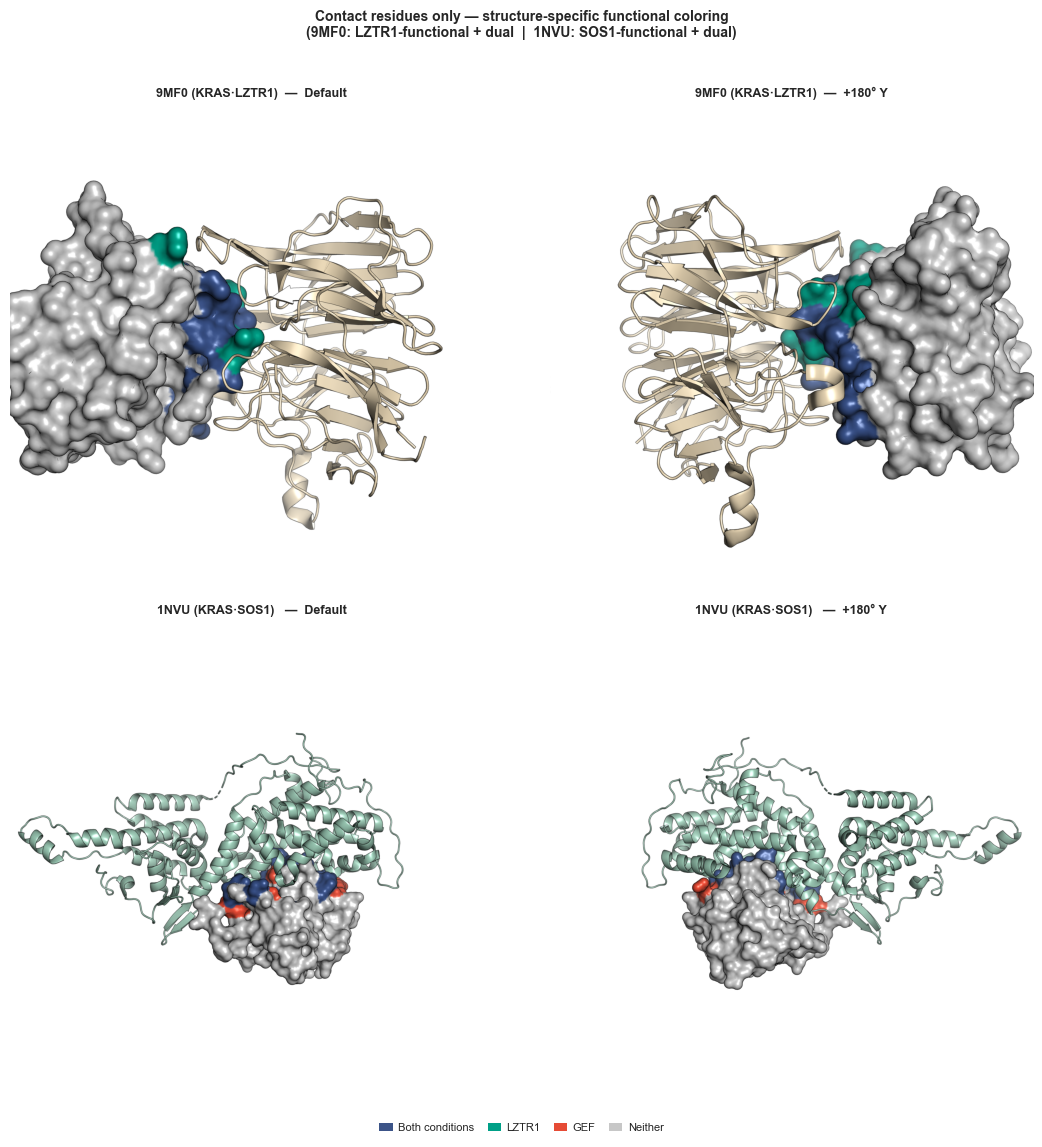

Saved → KRAS_contacts_only_2x2.pdf / .png
Contact-only session: OK
Saved → /Users/jsimon/Downloads/KRAS_contact_only_session.pse


In [41]:
# ── Contact-residues-only PyMOL renders ───────────────────────────────────────────────────
# Overlap colors applied ONLY to structural contact positions for each structure.
# All other KRAS residues stay grey.
# Functional coloring is structure-specific:
#   9MF0 (KRAS·LZTR1): highlights lzko_only + both  (LZTR1-relevant functions only)
#   1NVU (KRAS·SOS1):  highlights lzciar_only + both (SOS1-relevant functions only)
import subprocess, matplotlib.pyplot as plt, matplotlib.image as mpimg
from matplotlib.patches import Patch

NB_DIR = '/Users/jsimon/Library/Mobile Documents/com~apple~CloudDocs/Documents/Lab/**RNABinderProject/MAPK_collab/Code Notebooks/LABEL-seq Assays/LABELseq_pathway_analyses'
PYMOL  = '/opt/anaconda3/envs/jlab4/bin/pymol'

def resi_str(lst): return '+'.join(str(p) for p in sorted(lst))

def _kras_color_lines(obj_prefix, kras_obj, contact_positions,
                      colored_set=None, relevant_classes=None):
    """Return PyMOL color-assignment lines for a KRAS object.

    colored_set:      positions eligible for coloring (None = all contact_positions).
    relevant_classes: set of functional-class keys to highlight, e.g. {'lzko_only', 'both'}.
                      Positions whose class is NOT in relevant_classes are left as 'neither'
                      (grey), even if they are in colored_set.
                      None = highlight all non-neither classes.
    """
    if colored_set is None:
        colored_set = {int(p) for p in contact_positions}
    if relevant_classes is None:
        relevant_classes = {'lzko_only', 'lzciar_only', 'both'}

    # Only color a position if it is both in the contact set AND its class is relevant
    cls_for_obj = {
        k: [p for p in pos_cls[k] if p in colored_set and k in relevant_classes]
        for k in overlap_colors
    }

    lines = []
    for key, rgb in overlap_colors.items():
        lines.append(
            f'set_color col_{obj_prefix}_{key}, '
            f'[{rgb[0]:.3f}, {rgb[1]:.3f}, {rgb[2]:.3f}]'
        )
    lines.append(f'color col_{obj_prefix}_neither, {kras_obj}')
    for key in ['lzko_only', 'lzciar_only', 'both']:
        if cls_for_obj[key]:
            resi = resi_str(cls_for_obj[key])
            lines += [
                f'select sel_{obj_prefix}_{key}, {kras_obj} and resi {resi}',
                f'color col_{obj_prefix}_{key}, sel_{obj_prefix}_{key}',
            ]
    return lines

def make_contact_only_pml(cif_path, kras_chain, partner_chain, partner_color,
                           rotation_cmd, png_path, contact_positions,
                           relevant_classes=None, ray_size=2400):
    """Render PNG: only contact positions receive overlap-class colours.

    relevant_classes: passed straight through to _kras_color_lines — controls
                      which functional classes are highlighted vs left grey.
    """
    contact_set = {int(p) for p in contact_positions}
    lines = [
        f'load {cif_path}, raw',
        f'create kras_chain, raw and chain {kras_chain}',
        f'create partner_chain, raw and chain {partner_chain}',
        'delete raw', 'hide everything', 'bg_color white',
        'show surface, kras_chain', 'show cartoon, kras_chain',
        'show cartoon, partner_chain',
        f'set_color col_partner, {partner_color}',
        'color col_partner, partner_chain',
    ]
    lines += _kras_color_lines('c', 'kras_chain', contact_positions,
                                contact_set, relevant_classes)
    lines += [
        'set surface_quality, 1', 'set surface_solvent, 0',
        'set cartoon_loop_radius, 0.20', 'set cartoon_tube_radius, 0.25',
        'set cartoon_helix_radius, 0.75',
        'set ray_shadows, 0', 'set antialias, 2',
        'set ray_trace_mode, 1', 'set ray_opaque_background, on',
        'orient all', rotation_cmd, 'zoom all, 4',
        f'ray {ray_size}, {ray_size}', f'png {png_path}, dpi=300', 'quit',
    ]
    return '\n'.join(lines)

# ── Render: each structure highlights only its biologically relevant classes ──
#   9MF0 (KRAS·LZTR1) → LZTR1-functional or dual: {'lzko_only', 'both'}
#   1NVU (KRAS·SOS1)  → SOS1-functional  or dual: {'lzciar_only', 'both'}
renders = [
    ('9MF0', 'default', f'{NB_DIR}/9MF0.cif', 'A', 'B',
     '[0.90, 0.83, 0.70]', 'turn y, 0',   kras_lztr1_pos, {'lzko_only', 'both'}),
    ('9MF0', '180Y',   f'{NB_DIR}/9MF0.cif', 'A', 'B',
     '[0.90, 0.83, 0.70]', 'turn y, 180', kras_lztr1_pos, {'lzko_only', 'both'}),
    ('1NVU', 'default', f'{NB_DIR}/1NVU.cif', 'R', 'S',
     '[0.60, 0.78, 0.70]', 'turn y, 0',   kras_sos1_pos,  {'lzciar_only', 'both'}),
    ('1NVU', '180Y',   f'{NB_DIR}/1NVU.cif', 'R', 'S',
     '[0.60, 0.78, 0.70]', 'turn y, 180', kras_sos1_pos,  {'lzciar_only', 'both'}),
]

png_files = {}
for struct, view, cif, kchain, pchain, pcol, rot, contact_pos, rel_cls in renders:
    key = f'{struct}_{view}'
    png = f'{output_folder}KRAS_contacts_only_{struct}_{view}.png'
    pml = f'{NB_DIR}/kras_contacts_only_{struct}_{view}.pml'
    with open(pml, 'w') as f:
        f.write(make_contact_only_pml(cif, kchain, pchain, pcol, rot, png,
                                      contact_pos, rel_cls))
    r = subprocess.run([PYMOL, '-cq', pml], capture_output=True, text=True, timeout=180)
    status = 'OK' if r.returncode == 0 else f'ERROR — {r.stderr[-300:]}'
    print(f'{key}: {status}')
    png_files[key] = png

# ── Display 2×2 grid ──────────────────────────────────────────────────────
titles = {
    '9MF0_default': '9MF0 (KRAS·LZTR1)  —  Default',
    '9MF0_180Y':    '9MF0 (KRAS·LZTR1)  —  +180° Y',
    '1NVU_default': '1NVU (KRAS·SOS1)   —  Default',
    '1NVU_180Y':    '1NVU (KRAS·SOS1)   —  +180° Y',
}
fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for ax, (key, png) in zip(axes.flat, png_files.items()):
    ax.imshow(mpimg.imread(png))
    ax.set_title(titles[key], fontsize=9, fontweight='bold', pad=4)
    ax.axis('off')
legend_handles = [
    Patch(facecolor=overlap_hex[k], edgecolor='none', label=overlap_labels[k])
    for k in ['both', 'lzko_only', 'lzciar_only', 'neither']
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=4, fontsize=8, frameon=False, handlelength=1.2,
           handletextpad=0.5, columnspacing=1.2)
fig.suptitle(
    'Contact residues only — structure-specific functional coloring\n'
    '(9MF0: LZTR1-functional + dual  |  1NVU: SOS1-functional + dual)',
    fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'KRAS_contacts_only_2x2.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_contacts_only_2x2.png'),
            bbox_inches='tight', dpi=300)
plt.show()
print('Saved → KRAS_contacts_only_2x2.pdf / .png')

# ── Save contact-only PyMOL session (.pse) ────────────────────────────────
# Unique structs only (sessions are interactive — no rotation baked in)
_session_structs = [
    ('contact_9mf0', f'{NB_DIR}/9MF0.cif', 'A', 'B',
     '[0.90, 0.83, 0.70]', kras_lztr1_pos, {'lzko_only', 'both'}),
    ('contact_1nvu', f'{NB_DIR}/1NVU.cif', 'R', 'S',
     '[0.60, 0.78, 0.70]', kras_sos1_pos,  {'lzciar_only', 'both'}),
]

def make_session_block(obj_prefix, cif_path, kras_chain, partner_chain,
                        partner_color, contact_positions, colored_set,
                        relevant_classes=None):
    """Return PyMOL lines to load one structure into a shared session."""
    kras_obj = f'{obj_prefix}_kras'
    part_obj = f'{obj_prefix}_partner'
    lines = [
        f'load {cif_path}, raw_{obj_prefix}',
        f'create {kras_obj}, raw_{obj_prefix} and chain {kras_chain}',
        f'create {part_obj}, raw_{obj_prefix} and chain {partner_chain}',
        f'delete raw_{obj_prefix}',
        f'hide everything, {kras_obj}',
        f'hide everything, {part_obj}',
        f'show surface, {kras_obj}',
        f'show cartoon, {kras_obj}',
        f'show cartoon, {part_obj}',
        f'set_color col_{obj_prefix}_partner, {partner_color}',
        f'color col_{obj_prefix}_partner, {part_obj}',
    ]
    lines += _kras_color_lines(obj_prefix, kras_obj, contact_positions,
                                colored_set, relevant_classes)
    lines += [
        f'set surface_quality, 1, {kras_obj}',
        f'set surface_solvent, 0, {kras_obj}',
    ]
    return lines

contact_session_lines = ['bg_color white',
                          'set cartoon_loop_radius, 0.20',
                          'set cartoon_tube_radius, 0.25',
                          'set cartoon_helix_radius, 0.75']
for obj_prefix, cif_path, kras_chain, partner_chain, partner_color, contact_pos, rel_cls \
        in _session_structs:
    colored = {int(p) for p in contact_pos}
    contact_session_lines += make_session_block(
        obj_prefix, cif_path, kras_chain, partner_chain, partner_color,
        contact_pos, colored, rel_cls
    )

_contact_pse = os.path.join(output_folder, 'KRAS_contact_only_session.pse')
contact_session_lines += [f'save {_contact_pse}', 'quit']
_pml_path = f'{NB_DIR}/kras_contact_only_session.pml'
with open(_pml_path, 'w') as f:
    f.write('\n'.join(contact_session_lines))
r = subprocess.run([PYMOL, '-cq', _pml_path], capture_output=True, text=True, timeout=180)
print('Contact-only session:', 'OK' if r.returncode == 0 else f'ERROR — {r.stderr[-300:]}')
print(f'Saved → {_contact_pse}')


9MF0_default: OK
9MF0_180Y: OK
1NVU_default: OK
1NVU_180Y: OK


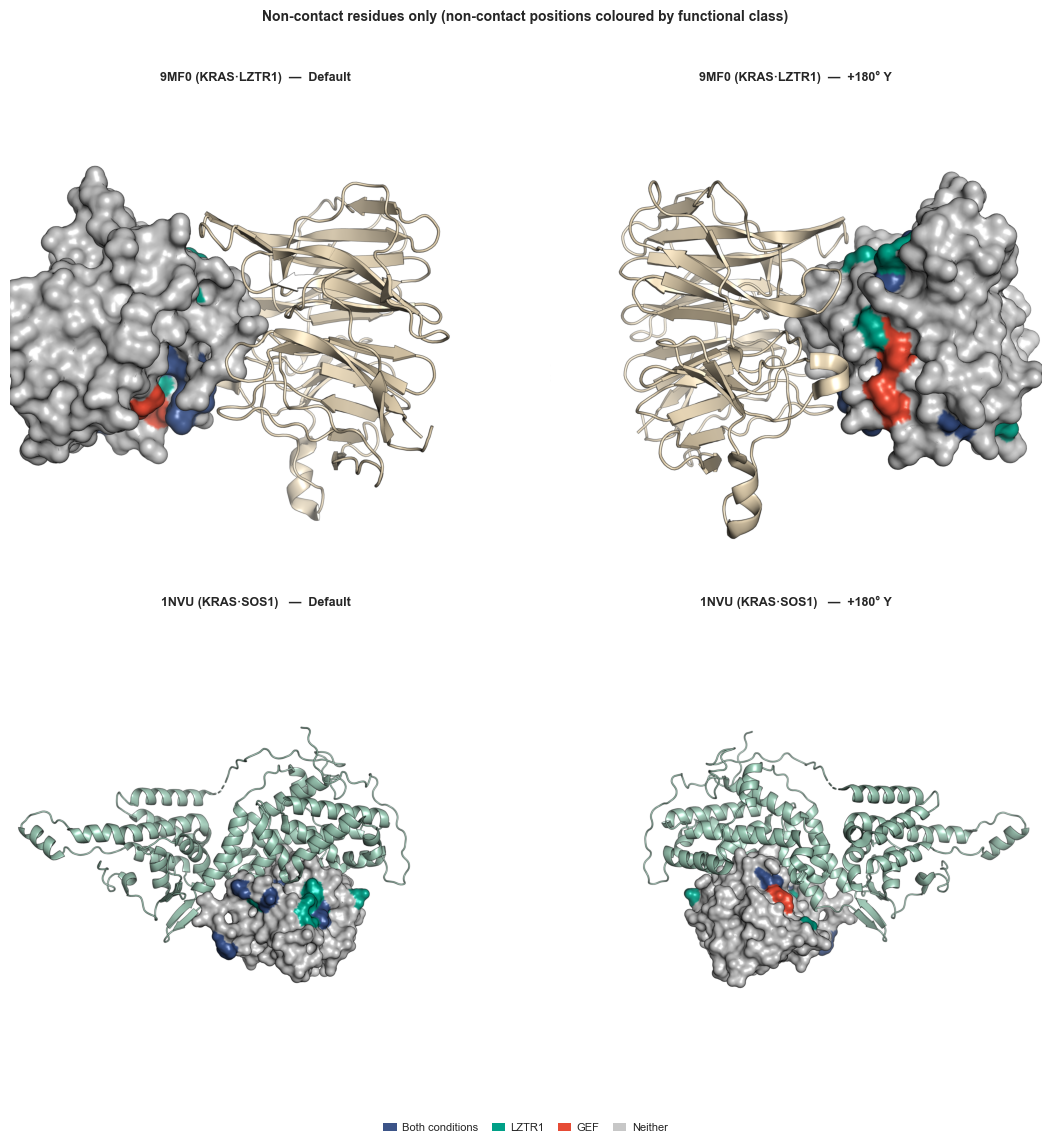

Saved → KRAS_noncontacts_only_2x2.pdf / .png
Combined session: OK
Saved → /Users/jsimon/Downloads/KRAS_combined_session.pse

Objects in combined session:
  contact_9mf0_kras  /  contact_9mf0_partner
  contact_1nvu_kras  /  contact_1nvu_partner
  noncontact_9mf0_kras  /  noncontact_9mf0_partner
  noncontact_1nvu_kras  /  noncontact_1nvu_partner


In [42]:
# ── Non-contact-residues-only PyMOL renders ───────────────────────────────────────────────
# Inverse of the cell above: overlap colors applied ONLY to NON-contact positions.
# Contact positions and unannotated residues stay grey.
# Combined .pse session includes both contact-only AND non-contact-only objects.

def make_noncontact_only_pml(cif_path, kras_chain, partner_chain, partner_color,
                              rotation_cmd, png_path, contact_positions, ray_size=2400):
    """Render PNG: NON-contact positions receive overlap-class colours; contacts stay grey."""
    contact_set  = {int(p) for p in contact_positions}
    all_bdf_pos  = {int(p) for p in bdf['Position']}
    noncontact_set = all_bdf_pos - contact_set          # positions to colour

    lines = [
        f'load {cif_path}, raw',
        f'create kras_chain, raw and chain {kras_chain}',
        f'create partner_chain, raw and chain {partner_chain}',
        'delete raw', 'hide everything', 'bg_color white',
        'show surface, kras_chain', 'show cartoon, kras_chain',
        'show cartoon, partner_chain',
        f'set_color col_partner, {partner_color}',
        'color col_partner, partner_chain',
    ]
    lines += _kras_color_lines('nc', 'kras_chain', contact_positions, noncontact_set)
    lines += [
        'set surface_quality, 1', 'set surface_solvent, 0',
        'set cartoon_loop_radius, 0.20', 'set cartoon_tube_radius, 0.25',
        'set cartoon_helix_radius, 0.75',
        'set ray_shadows, 0', 'set antialias, 2',
        'set ray_trace_mode, 1', 'set ray_opaque_background, on',
        'orient all', rotation_cmd, 'zoom all, 4',
        f'ray {ray_size}, {ray_size}', f'png {png_path}, dpi=300', 'quit',
    ]
    return '\n'.join(lines)

# ── Render 4 PNGs ────────────────────────────────────────────────────────────
renders_nc = [
    ('9MF0', 'default', f'{NB_DIR}/9MF0.cif', 'A', 'B',
     '[0.90, 0.83, 0.70]', 'turn y, 0',   kras_lztr1_pos),
    ('9MF0', '180Y',   f'{NB_DIR}/9MF0.cif', 'A', 'B',
     '[0.90, 0.83, 0.70]', 'turn y, 180', kras_lztr1_pos),
    ('1NVU', 'default', f'{NB_DIR}/1NVU.cif', 'R', 'S',
     '[0.60, 0.78, 0.70]', 'turn y, 0',   kras_sos1_pos),
    ('1NVU', '180Y',   f'{NB_DIR}/1NVU.cif', 'R', 'S',
     '[0.60, 0.78, 0.70]', 'turn y, 180', kras_sos1_pos),
]

png_files_nc = {}
for struct, view, cif, kchain, pchain, pcol, rot, contact_pos in renders_nc:
    key = f'{struct}_{view}'
    png = f'{output_folder}KRAS_noncontacts_only_{struct}_{view}.png'
    pml = f'{NB_DIR}/kras_noncontacts_only_{struct}_{view}.pml'
    with open(pml, 'w') as f:
        f.write(make_noncontact_only_pml(cif, kchain, pchain, pcol, rot, png, contact_pos))
    r = subprocess.run([PYMOL, '-cq', pml], capture_output=True, text=True, timeout=180)
    status = 'OK' if r.returncode == 0 else f'ERROR — {r.stderr[-300:]}'
    print(f'{key}: {status}')
    png_files_nc[key] = png

# ── Display 2×2 grid ──────────────────────────────────────────────────────
titles = {
    '9MF0_default': '9MF0 (KRAS·LZTR1)  —  Default',
    '9MF0_180Y':    '9MF0 (KRAS·LZTR1)  —  +180° Y',
    '1NVU_default': '1NVU (KRAS·SOS1)   —  Default',
    '1NVU_180Y':    '1NVU (KRAS·SOS1)   —  +180° Y',
}
fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for ax, (key, png) in zip(axes.flat, png_files_nc.items()):
    ax.imshow(mpimg.imread(png))
    ax.set_title(titles[key], fontsize=9, fontweight='bold', pad=4)
    ax.axis('off')
legend_handles = [
    Patch(facecolor=overlap_hex[k], edgecolor='none', label=overlap_labels[k])
    for k in ['both', 'lzko_only', 'lzciar_only', 'neither']
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=4, fontsize=8, frameon=False, handlelength=1.2,
           handletextpad=0.5, columnspacing=1.2)
fig.suptitle('Non-contact residues only (non-contact positions coloured by functional class)',
             fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'KRAS_noncontacts_only_2x2.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_noncontacts_only_2x2.png'),
            bbox_inches='tight', dpi=300)
plt.show()
print('Saved → KRAS_noncontacts_only_2x2.pdf / .png')

# ── Combined PyMOL session: contact-only + non-contact-only objects ────────────────────
# 4 named object groups in one .pse:
#   contact_9mf0_kras / partner   — contact positions coloured
#   contact_1nvu_kras / partner   — contact positions coloured
#   noncontact_9mf0_kras / partner — non-contact positions coloured
#   noncontact_1nvu_kras / partner — non-contact positions coloured

_all_bdf_pos = {int(p) for p in bdf['Position']}

_combined_structs = [
    # (obj_prefix, cif, kras_chain, partner_chain, partner_color, colored_set)
    ('contact_9mf0',    f'{NB_DIR}/9MF0.cif', 'A', 'B', '[0.90, 0.83, 0.70]',
     {int(p) for p in kras_lztr1_pos}),
    ('contact_1nvu',    f'{NB_DIR}/1NVU.cif', 'R', 'S', '[0.60, 0.78, 0.70]',
     {int(p) for p in kras_sos1_pos}),
    ('noncontact_9mf0', f'{NB_DIR}/9MF0.cif', 'A', 'B', '[0.90, 0.83, 0.70]',
     _all_bdf_pos - {int(p) for p in kras_lztr1_pos}),
    ('noncontact_1nvu', f'{NB_DIR}/1NVU.cif', 'R', 'S', '[0.60, 0.78, 0.70]',
     _all_bdf_pos - {int(p) for p in kras_sos1_pos}),
]

combined_lines = [
    'bg_color white',
    'set cartoon_loop_radius, 0.20',
    'set cartoon_tube_radius, 0.25',
    'set cartoon_helix_radius, 0.75',
]

# contact_positions arg is passed but colored_set overrides which positions get color
for obj_prefix, cif_path, kras_chain, partner_chain, partner_color, colored_set in _combined_structs:
    # Pick the right contact_pos for the _kras_color_lines helper
    contact_pos = kras_lztr1_pos if '9mf0' in obj_prefix else kras_sos1_pos
    combined_lines += make_session_block(
        obj_prefix, cif_path, kras_chain, partner_chain,
        partner_color, contact_pos, colored_set
    )

_combined_pse = os.path.join(output_folder, 'KRAS_combined_session.pse')
combined_lines += [f'save {_combined_pse}', 'quit']

_pml_combined = f'{NB_DIR}/kras_combined_session.pml'
with open(_pml_combined, 'w') as f:
    f.write('\n'.join(combined_lines))
r = subprocess.run([PYMOL, '-cq', _pml_combined], capture_output=True, text=True, timeout=300)
print('Combined session:', 'OK' if r.returncode == 0 else f'ERROR — {r.stderr[-300:]}')
print(f'Saved → {_combined_pse}')
print('\nObjects in combined session:')
for obj_prefix, *_ in _combined_structs:
    print(f'  {obj_prefix}_kras  /  {obj_prefix}_partner')


cartoon default: OK
cartoon 180Y: OK


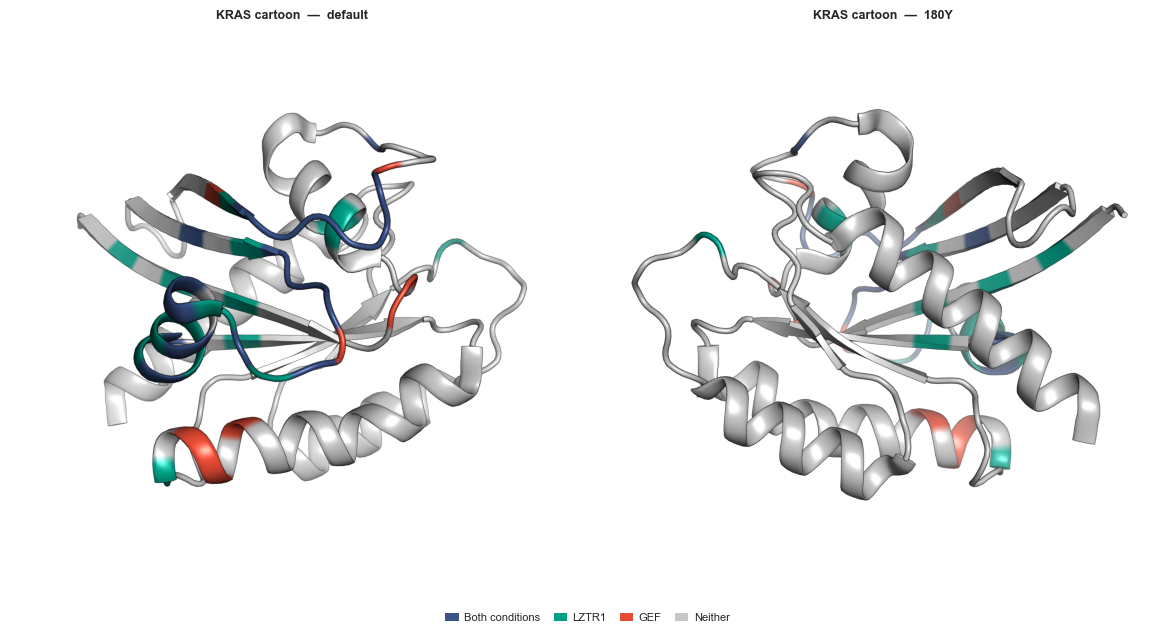

In [43]:

# ── KRAS-only cartoon, overlap coloring ───────────────────────────────────────
def make_kras_cartoon_pml(cif_path, kras_chain, rotation_cmd, png_path, ray_size=2400):
    lines = [
        f"load {cif_path}, raw",
        f"create kras, raw and chain {kras_chain}",
        "delete raw",
        "hide everything",
        "bg_color white",
        "show cartoon, kras",
    ]
    for key, rgb in overlap_colors.items():
        lines.append(f"set_color col_{key}, [{rgb[0]:.3f}, {rgb[1]:.3f}, {rgb[2]:.3f}]")
    lines.append("color col_neither, kras")
    for key in ['lzko_only', 'lzciar_only', 'both']:
        resi = resi_str(pos_cls[key])
        lines += [
            f"select sel_{key}, kras and resi {resi}",
            f"color col_{key}, sel_{key}",
        ]
    lines += [
        "set cartoon_rect_length, 1.0",
        "set cartoon_oval_length, 1.0",
        "set cartoon_loop_radius, 0.25",
        "set cartoon_tube_radius, 0.30",
        "set cartoon_helix_radius, 0.85",
        "set ray_shadows, 0",
        "set antialias, 2",
        "set ray_trace_mode, 1",
        "set ray_opaque_background, on",
        "orient kras",
        rotation_cmd,
        "zoom kras, 3",
        f"ray {ray_size}, {ray_size}",
        f"png {png_path}, dpi=300",
        "quit",
    ]
    return '\n'.join(lines)

cartoon_pngs = {}
for view, rotation in [('default', 'turn y, 0'), ('180Y', 'turn y, 180')]:
    png = f'{output_folder}KRAS_overlap_cartoon_{view}.png'
    pml = f'{NB_DIR}/kras_cartoon_{view}.pml'
    with open(pml, 'w') as f:
        f.write(make_kras_cartoon_pml(
            cif_path     = f'{NB_DIR}/9MF0.cif',
            kras_chain   = 'A',
            rotation_cmd = rotation,
            png_path     = png,
        ))
    r = subprocess.run([PYMOL, '-cq', pml], capture_output=True, text=True, timeout=180)
    print(f"cartoon {view}: {'OK' if r.returncode==0 else 'ERROR — '+r.stderr[-300:]}")
    cartoon_pngs[view] = png

# ── Display ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, (view, png) in zip(axes, cartoon_pngs.items()):
    ax.imshow(mpimg.imread(png))
    ax.set_title(f'KRAS cartoon  —  {view}', fontsize=9, fontweight='bold')
    ax.axis('off')

legend_handles = [
    Patch(facecolor=overlap_hex[k], edgecolor='none', label=overlap_labels[k])
    for k in ['both', 'lzko_only', 'lzciar_only', 'neither']
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.04),
           ncol=4, fontsize=8, frameon=False, handlelength=1.2,
           handletextpad=0.5, columnspacing=1.2)
plt.tight_layout()
plt.show()


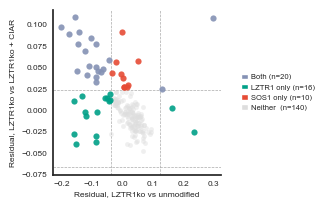

Syn-WT residual thresholds (origin-forced, P5/P95):
  LZTR1ko:                 [-0.0376, 0.1220]
  LZTR1koCIAR on LZTR1ko: [-0.0666, 0.0242]
  Both           : 20 positions
  LZTR1 only     : 16 positions
  SOS1 only      : 10 positions
  Neither        : 140 positions


In [77]:
# ── KRAS: SOS1 vs LZTR1 — structural contacts & functional importance ────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── 1 · Contact categories ───────────────────────────────────────────────────
both_pos   = kras_sos1_pos & kras_lztr1_pos
sos1_only  = kras_sos1_pos - kras_lztr1_pos
lztr1_only = kras_lztr1_pos - kras_sos1_pos

# Structural contact categories → use CONTACT color palette
IFACE_COLORS = {
    'Both':       BOTH_FUNC_COLOR,       # lavender (shared contact)
    'SOS1 only':  SOS1_CONTACT_COLOR,    # muted rose  — SOS1 structural contact
    'LZTR1 only': LZTR1_CONTACT_COLOR,   # cerulean blue — LZTR1 structural contact
    'Neither':    NEITHER_FUNC_COLOR,    # light grey
}

def contact_label(pos):
    if pos in both_pos:   return 'Both'
    if pos in sos1_only:  return 'SOS1 only'
    if pos in lztr1_only: return 'LZTR1 only'
    return 'Neither'

# ── 2 · Functional scores from bdf (origin-forced residuals) ───────────────────
# x-axis: lztr1ko_median        = residual of LZTR1ko ~ syn-WT  (intercept = 0)
# y-axis: resid_LZTR1koCIAR_on_LZTR1ko_median = residual of LZTR1koCIAR ~ LZTR1ko (intercept = 0)
# Perturbed flags use syn-WT P5–95 thresholds from syn_iqr (same as boxplot / bdf cells)

_cols = ['Position', 'lztr1ko_median', 'resid_LZTR1koCIAR_on_LZTR1ko_median',
         'lz_perturbed', 'lzciar_perturbed']
func_df = bdf[_cols].dropna().copy()
func_df['Position'] = func_df['Position'].astype(int)
func_df['contact']  = [contact_label(p) for p in func_df['Position']]

def func_label(row):
    l, c = row['lz_perturbed'], row['lzciar_perturbed']
    if l and c: return 'Both'
    if l:       return 'LZTR1 only'
    if c:       return 'SOS1 only'
    return 'Neither'

func_df['func_cat'] = func_df.apply(func_label, axis=1)

# Syn-WT P5/P95 thresholds for dashed reference lines
lztr1_p05  = syn_iqr['resid_LZTR1ko']['p05']
lztr1_p95  = syn_iqr['resid_LZTR1ko']['p95']
lzciar_p05 = syn_iqr['resid_LZTR1koCIAR_on_LZTR1ko']['p05']
lzciar_p95 = syn_iqr['resid_LZTR1koCIAR_on_LZTR1ko']['p95']

# Functional perturbation categories → use FUNCTIONAL color palette
FUNC_COLORS = {
    'Both':       BOTH_FUNC_COLOR,     # lavender    — perturbed in both assays
    'LZTR1 only': LZTR1_FUNC_COLOR,   # teal-green  — LZTR1ko-perturbed
    'SOS1 only':  SOS1_FUNC_COLOR,    # coral-red   — CIAR-perturbed
    'Neither':    NEITHER_FUNC_COLOR,  # light grey  — not significantly perturbed
}

n_both  = len(both_pos)
n_sos1  = len(sos1_only)
n_lztr1 = len(lztr1_only)

# ── 3 · Figure ─────────────────────────────────────────────────────────────────────
sns.set(style='white')
fig, ax2 = plt.subplots(1, 1, figsize=(3.5, 2.5))
fig.subplots_adjust(bottom=0.22, left=0.42)

# ─── Panel 2: functional importance scatter ────────────────────────────────────────
for cat in ['Neither', 'SOS1 only', 'LZTR1 only', 'Both']:
    sub = func_df[func_df['func_cat'] == cat]
    ax2.scatter(sub['lztr1ko_median'], sub['resid_LZTR1koCIAR_on_LZTR1ko_median'],
                color=FUNC_COLORS[cat],
                s=12 if cat == 'Neither' else 20,
                alpha=0.45 if cat == 'Neither' else 0.90,
                zorder=2  if cat == 'Neither' else 3,
                linewidths=0,
                label=f'{cat}  (n={len(sub)})')

# Syn-WT P5/P95 threshold dashes
for val in [lztr1_p05, lztr1_p95]:
    ax2.axvline(val, color='#AAAAAA', linewidth=0.5, linestyle='--', zorder=1)
for val in [lzciar_p05, lzciar_p95]:
    ax2.axhline(val, color='#AAAAAA', linewidth=0.5, linestyle='--', zorder=1)

ax2.set_xlabel('Residual, LZTR1ko vs unmodified', fontsize=6)
ax2.set_ylabel('Residual, LZTR1ko vs LZTR1ko + CIAR', fontsize=6)
# ax2.set_title('Functional importance\n(per-position residual median, origin-forced)', fontsize=6.5,
#               fontweight='bold', pad=4)
ax2.tick_params(axis='both', labelsize=6, length=2, width=0.5, direction='out', pad=2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Legends ─────────────────────────────────────────────────────────────────────────────
func_counts = func_df['func_cat'].value_counts()
func_handles = [
    mpatches.Patch(facecolor=FUNC_COLORS['Both'],       label=f'Both (n={func_counts.get("Both", 0)})'),
    mpatches.Patch(facecolor=FUNC_COLORS['LZTR1 only'], label=f'LZTR1 only (n={func_counts.get("LZTR1 only", 0)})'),
    mpatches.Patch(facecolor=FUNC_COLORS['SOS1 only'],  label=f'SOS1 only (n={func_counts.get("SOS1 only", 0)})'),
    mpatches.Patch(facecolor=FUNC_COLORS['Neither'],    label=f'Neither  (n={func_counts.get("Neither", 0)})'),
    # Line2D([0],[0], color='#AAAAAA', linewidth=0.8, linestyle='--', label='Syn-WT P5–P95'),
]

ax2.legend(handles=func_handles, fontsize=5.5, frameon=False,
           loc='center right', bbox_to_anchor=(1.6, 0.5),
           handlelength=0.9, handletextpad=0.4)

# fig.suptitle('KRAS — SOS1 vs LZTR1: structural contacts & functional importance',
#              fontsize=7, fontweight='bold', y=1.03)

plt.savefig(os.path.join(output_folder, 'KRAS_SOS1_LZTR1_contacts_vs_function.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_SOS1_LZTR1_contacts_vs_function.svg'),
            bbox_inches='tight')
plt.show()

print('Syn-WT residual thresholds (origin-forced, P5/P95):')
print(f'  LZTR1ko:                 [{lztr1_p05:.4f}, {lztr1_p95:.4f}]')
print(f'  LZTR1koCIAR on LZTR1ko: [{lzciar_p05:.4f}, {lzciar_p95:.4f}]')
for cat in ['Both', 'LZTR1 only', 'SOS1 only', 'Neither']:
    print(f'  {cat:15s}: {func_counts.get(cat, 0)} positions')


n syn basal: 180, n syn CIAR: 180, n high-act: 530


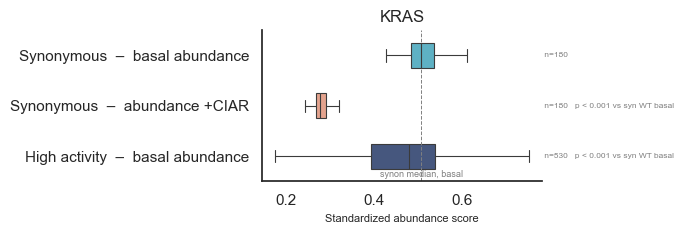

In [45]:

from scipy.stats import mannwhitneyu
import numpy as np
sns.set(style='white')

# ── Column names ──────────────────────────────────────────────────────────────
# Abundance assay: basal = No_treatment, CIAR = CIAR
# Activity assay:  basal = DMSO (No_treatment has no activity data for KRAS)
score_abu_basal = 'intercept_0_standard-adjusted score__abundance__No_treatment'
score_abu_ciar  = 'intercept_0_standard-adjusted score__abundance__CIAR'
clf_act_basal   = 'classification_2.5pct__activity__DMSO'

# ── Group label constants ─────────────────────────────────────────────────────
GRP_SYN_BASAL = 'Synonymous  –  basal abundance'
GRP_SYN_CIAR  = 'Synonymous  –  abundance +CIAR'
GRP_ACT_HI    = 'High activity  –  basal abundance'

kras_wide = kras_Replicate_scores_wide.copy()

# ── Build each group ──────────────────────────────────────────────────────────
g1 = (kras_wide[kras_wide['Mutation Type'] == 'synonymous wild type'][score_abu_basal]
      .dropna().rename('score').to_frame().assign(group=GRP_SYN_BASAL))

g3 = (kras_wide[kras_wide['Mutation Type'] == 'synonymous wild type'][score_abu_ciar]
      .dropna().rename('score').to_frame().assign(group=GRP_SYN_CIAR))

# High-activity missense: classified 'high' in DMSO activity (basal RAS activity assay)
high_act_variants = kras_wide[
    (kras_wide['Mutation Type'] == 'missense') &
    (kras_wide[clf_act_basal] == 'high')
]['variant'].unique()

g2 = (kras_wide[kras_wide['variant'].isin(high_act_variants)][score_abu_basal]
      .dropna().rename('score').to_frame().assign(group=GRP_ACT_HI))

print(f"n syn basal: {len(g1)}, n syn CIAR: {len(g3)}, n high-act: {len(g2)}")

plot_df = pd.concat([g1, g3, g2], ignore_index=True)
order   = [GRP_SYN_BASAL, GRP_SYN_CIAR, GRP_ACT_HI]

syn_wt_median = g1['score'].median()
ref_scores    = g1['score'].values

# ── Mann-Whitney U vs syn WT basal ────────────────────────────────────────────
def mw_pstr(a, b):
    a, b = np.array(a), np.array(b)
    if len(a) < 3 or len(b) < 3: return 'n too small'
    _, p = mannwhitneyu(a, b, alternative='two-sided')
    if np.isnan(p):  return 'n too small'
    if p < 0.001:    return 'p < 0.001'
    return f'p = {p:.3f}'

stats_labels = {
    GRP_SYN_BASAL: None,
    GRP_SYN_CIAR:  mw_pstr(g3['score'].dropna().values, ref_scores),
    GRP_ACT_HI:    mw_pstr(g2['score'].dropna().values, ref_scores),
}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 2.5))

sns.boxplot(
    data=plot_df, x='score', y='group', order=order,
    orient='h', palette=['#4DBBD5', '#F39B7F', '#3C5488'],
    width=0.5, linewidth=0.8, showfliers=False, ax=ax
)

ax.axvline(syn_wt_median, color='gray', linewidth=0.7, linestyle='--')
ax.text(syn_wt_median, ax.get_ylim()[0] - 0.05, 'synon median, basal',
        ha='center', va='bottom', fontsize=6.5, color='gray')

ax.set_xlabel('Standardized abundance score', fontsize=8)
ax.set_ylabel('')

# ── n labels + p-values to the right ─────────────────────────────────────────
x_right = ax.get_xlim()[1]
for i, grp in enumerate(order):
    n = plot_df[plot_df['group'] == grp]['score'].notna().sum()
    pstr = stats_labels[grp]
    label = f' n={n}' if pstr is None else f' n={n}   {pstr} vs syn WT basal'
    ax.text(x_right, i, label, va='center', fontsize=6, color='gray')

sns.despine(ax=ax)

plt.title('KRAS')

plt.tight_layout()
plt.savefig('/Users/jsimon/Downloads/kras_abundance_boxplot_3groups.svg', bbox_inches='tight')
plt.show()


n syn basal: 180, n missense basal: 3504, n missense CIAR: 3489


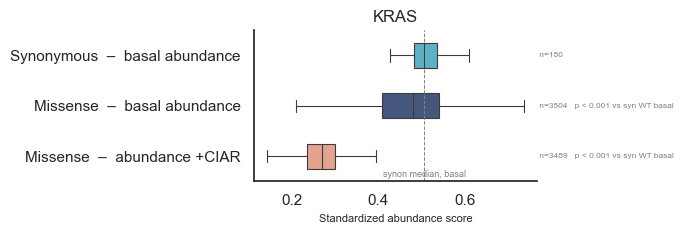

In [46]:

from scipy.stats import mannwhitneyu
import numpy as np
sns.set(style='white')

# ── Column names ──────────────────────────────────────────────────────────────
score_abu_basal = 'intercept_0_standard-adjusted score__abundance__No_treatment'
score_abu_ciar  = 'intercept_0_standard-adjusted score__abundance__CIAR'

# ── Group label constants ─────────────────────────────────────────────────────
GRP_SYN_BASAL = 'Synonymous  –  basal abundance'
GRP_MIS_BASAL = 'Missense  –  basal abundance'
GRP_MIS_CIAR  = 'Missense  –  abundance +CIAR'

kras_wide = kras_Replicate_scores_wide.copy()

# ── Build each group ──────────────────────────────────────────────────────────
g1 = (kras_wide[kras_wide['Mutation Type'] == 'synonymous wild type'][score_abu_basal]
      .dropna().rename('score').to_frame().assign(group=GRP_SYN_BASAL))

g2 = (kras_wide[kras_wide['Mutation Type'] == 'missense'][score_abu_basal]
      .dropna().rename('score').to_frame().assign(group=GRP_MIS_BASAL))

g3 = (kras_wide[kras_wide['Mutation Type'] == 'missense'][score_abu_ciar]
      .dropna().rename('score').to_frame().assign(group=GRP_MIS_CIAR))

print(f"n syn basal: {len(g1)}, n missense basal: {len(g2)}, n missense CIAR: {len(g3)}")

plot_df = pd.concat([g1, g2, g3], ignore_index=True)
order   = [GRP_SYN_BASAL, GRP_MIS_BASAL, GRP_MIS_CIAR]

syn_wt_median = g1['score'].median()
ref_scores    = g1['score'].values

# ── Mann-Whitney U vs syn WT basal ────────────────────────────────────────────
def mw_pstr(a, b):
    a, b = np.array(a), np.array(b)
    if len(a) < 3 or len(b) < 3: return 'n too small'
    _, p = mannwhitneyu(a, b, alternative='two-sided')
    if np.isnan(p):  return 'n too small'
    if p < 0.001:    return 'p < 0.001'
    return f'p = {p:.3f}'

stats_labels = {
    GRP_SYN_BASAL: None,
    GRP_MIS_BASAL: mw_pstr(g2['score'].dropna().values, ref_scores),
    GRP_MIS_CIAR:  mw_pstr(g3['score'].dropna().values, ref_scores),
}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 2.5))

sns.boxplot(
    data=plot_df, x='score', y='group', order=order,
    orient='h', palette=['#4DBBD5', '#3C5488', '#F39B7F'],
    width=0.5, linewidth=0.8, showfliers=False, ax=ax
)

ax.axvline(syn_wt_median, color='gray', linewidth=0.7, linestyle='--')
ax.text(syn_wt_median, ax.get_ylim()[0] - 0.05, 'synon median, basal',
        ha='center', va='bottom', fontsize=6.5, color='gray')

ax.set_xlabel('Standardized abundance score', fontsize=8)
ax.set_ylabel('')

# ── n labels + p-values to the right ─────────────────────────────────────────
x_right = ax.get_xlim()[1]
for i, grp in enumerate(order):
    n = plot_df[plot_df['group'] == grp]['score'].notna().sum()
    pstr = stats_labels[grp]
    label = f' n={n}' if pstr is None else f' n={n}   {pstr} vs syn WT basal'
    ax.text(x_right, i, label, va='center', fontsize=6, color='gray')

sns.despine(ax=ax)

plt.title('KRAS')

plt.tight_layout()
plt.savefig('/Users/jsimon/Downloads/kras_abundance_boxplot_missense2.svg', bbox_inches='tight')
plt.show()


# Contact Position vs Functional Position Overlap: LZTR1 and SOS1/CIAR

**Question:** Are structural contact positions also functionally important in the DMS data? Specifically — do most LZTR1 contacts also show functional signal, while many SOS1 contacts do not?

**Functional definition (abundance assay, average score — matching the SOS1 vs LZTR1 structural contacts plot):**
- **LZTR1 effect per position**: mean `LZTR1ko − No_treatment` (average score) across missense variants
- **SOS1/CIAR effect per position**: mean `LZTR1koCIAR − LZTR1ko` (average score) across missense variants
- A position is *functionally important* if its mean score falls **outside the 5th–95th percentile of synonymous-WT** variants (two-sided)

Enrichment of functional signal at contact positions is tested with **Fisher's exact test** (one-sided: contacts enriched for functional positions vs all other positions).


In [72]:
# ═══════════════════════════════════════════════════════════════════════════════
# Contact vs Functional Position Overlap — computation
# Uses origin-forced residuals from bdf / syn_iqr (consistent with boxplot & bdf cells)
#   LZTR1 effect : lztr1ko_median                       (resid LZTR1ko ~ syn-WT, intercept=0)
#   SOS1/CIAR    : resid_LZTR1koCIAR_on_LZTR1ko_median (resid LZTR1koCIAR ~ LZTR1ko, intercept=0)
#   Functional   : outside syn-WT P5–95 (from syn_iqr)
# ═══════════════════════════════════════════════════════════════════════════════

# ── Per-position residual medians (from bdf) ──────────────────────────────────────
_bdf = bdf.dropna(subset=['lztr1ko_median', 'resid_LZTR1koCIAR_on_LZTR1ko_median']).copy()
_bdf['Position'] = _bdf['Position'].astype(int)

pos_lztr1 = _bdf.set_index('Position')['lztr1ko_median']
pos_ciar   = _bdf.set_index('Position')['resid_LZTR1koCIAR_on_LZTR1ko_median']

# ── Syn-WT P5/P95 thresholds from syn_iqr ─────────────────────────────────────────
lztr1_lo = syn_iqr['resid_LZTR1ko']['p05']
lztr1_hi = syn_iqr['resid_LZTR1ko']['p95']
ciar_lo  = syn_iqr['resid_LZTR1koCIAR_on_LZTR1ko']['p05']
ciar_hi  = syn_iqr['resid_LZTR1koCIAR_on_LZTR1ko']['p95']

print('Syn-WT residual thresholds (origin-forced, P5/P95):')
print(f'  LZTR1ko residual             : [{lztr1_lo:.4f}, {lztr1_hi:.4f}]')
print(f'  LZTR1koCIAR/LZTR1ko residual : [{ciar_lo:.4f}, {ciar_hi:.4f}]')

# ── Functional position sets from bdf flags ──────────────────────────────────────
lztr1_universe = set(_bdf['Position'])
sos1_universe  = set(_bdf['Position'])

lztr1_functional_pos = set(_bdf[_bdf['lz_perturbed']   ]['Position'])
sos1_functional_pos  = set(_bdf[_bdf['lzciar_perturbed']]['Position'])

# ── Contact sets limited to positions with residual data ──────────────────────────
lztr1_contacts = {int(p) for p in kras_lztr1_pos} & lztr1_universe
sos1_contacts  = {int(p) for p in kras_sos1_pos}  & sos1_universe

# ── Overlap components ───────────────────────────────────────────────────────────────────
lztr1_both      = lztr1_contacts & lztr1_functional_pos
lztr1_cont_only = lztr1_contacts - lztr1_functional_pos
lztr1_func_only = lztr1_functional_pos - lztr1_contacts

sos1_both       = sos1_contacts & sos1_functional_pos
sos1_cont_only  = sos1_contacts - sos1_functional_pos
sos1_func_only  = sos1_functional_pos - sos1_contacts

# ── Fisher's exact test (one-sided: contacts enriched for functional) ────────────────
from scipy.stats import fisher_exact

def fisher_enrichment(contacts, functional, universe):
    a = len(contacts & functional)
    b = len(contacts - functional)
    c = len(functional - contacts)
    d = len(universe - contacts - functional)
    odds, p = fisher_exact([[a, b], [c, d]], alternative='greater')
    return odds, p

lztr1_or, lztr1_p = fisher_enrichment(lztr1_contacts, lztr1_functional_pos, lztr1_universe)
sos1_or,  sos1_p  = fisher_enrichment(sos1_contacts,  sos1_functional_pos,  sos1_universe)

# ── Print summary ──────────────────────────────────────────────────────────────────────
sep = '─' * 60
for label, contacts, both, cont_only, func_only, functional, OR, p in [
    ('LZTR1 (resid: LZTR1ko ~ syn-WT, intercept=0)',
     lztr1_contacts, lztr1_both, lztr1_cont_only, lztr1_func_only, lztr1_functional_pos, lztr1_or, lztr1_p),
    ('SOS1/CIAR (resid: LZTR1koCIAR ~ LZTR1ko, intercept=0)',
     sos1_contacts, sos1_both, sos1_cont_only, sos1_func_only, sos1_functional_pos, sos1_or, sos1_p),
]:
    pct   = 100 * len(both) / max(1, len(contacts))
    p_str = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
    print(f'\n{label}:')
    print(sep)
    print(f'  Structural contacts (with residual data) : {len(contacts)}')
    print(f'  Functional positions (whole protein)     : {len(functional)}')
    print(f'  Contact AND functional                   : {len(both)}  ({pct:.0f}% of contacts)')
    print(f'  Contact ONLY (not functional)            : {len(cont_only)}')
    print(f'  Functional ONLY (not a contact)          : {len(func_only)}')
    print(f'  Fisher\'s exact OR = {OR:.2f}, {p_str}')
    print(f'  Functional contacts     : {sorted(both)}')
    print(f'  Non-functional contacts : {sorted(cont_only)}')


Syn-WT residual thresholds (origin-forced, P5/P95):
  LZTR1ko residual             : [-0.0376, 0.1220]
  LZTR1koCIAR/LZTR1ko residual : [-0.0666, 0.0242]

LZTR1 (resid: LZTR1ko ~ syn-WT, intercept=0):
────────────────────────────────────────────────────────────
  Structural contacts (with residual data) : 22
  Functional positions (whole protein)     : 36
  Contact AND functional                   : 17  (77% of contacts)
  Contact ONLY (not functional)            : 5
  Functional ONLY (not a contact)          : 19
  Fisher's exact OR = 25.95, p < 0.001
  Functional contacts     : [5, 33, 36, 37, 38, 60, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 105]
  Non-functional contacts : [41, 61, 102, 103, 104]

SOS1/CIAR (resid: LZTR1koCIAR ~ LZTR1ko, intercept=0):
────────────────────────────────────────────────────────────
  Structural contacts (with residual data) : 32
  Functional positions (whole protein)     : 30
  Contact AND functional                   : 18  (56% of contacts)
  Contact ON

NameError: name '_syn_w' is not defined

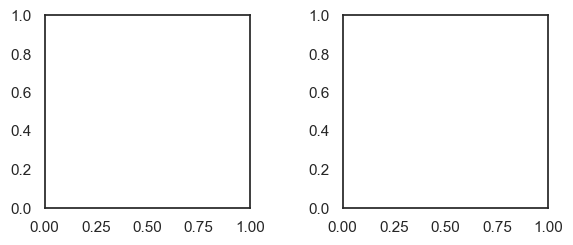

In [73]:
# ═══════════════════════════════════════════════════════════════════════════════
# Synonymous-WT abundance Δ distributions — LZTR1 vs SOS1/CIAR conditions
# ═══════════════════════════════════════════════════════════════════════════════
sns.set(style='white')

fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.5), sharey=False)
fig.subplots_adjust(wspace=0.45)

# Treatment condition colors → use FUNCTIONAL palette (from master palette cell)
# LZTR1ko condition ≈ LZTR1 functional category; CIAR ≈ SOS1/CIAR functional category
LZTR1_CLR = LZTR1_FUNC_COLOR   # teal-green — LZTR1 treatment condition
SOS1_CLR  = SOS1_FUNC_COLOR    # coral-red  — SOS1/CIAR treatment condition
ALPHA     = 0.75

for ax, score_col, clr, lo, hi, title, xlabel in [
    (axes[0], 'lztr1_diff', LZTR1_CLR, lztr1_lo, lztr1_hi,
     'LZTR1 condition\n(LZTR1ko − basal)',
     'Δ avg abundance score\n(LZTR1ko − No_treatment)'),
    (axes[1], 'ciar_diff',  SOS1_CLR,  ciar_lo,  ciar_hi,
     'SOS1/CIAR condition\n(LZTR1koCIAR − LZTR1ko)',
     'Δ avg abundance score\n(LZTR1koCIAR − LZTR1ko)'),
]:
    data = _syn_w[score_col].dropna()

    sns.kdeplot(data, ax=ax, color=clr, fill=True, alpha=0.25, linewidth=1.5)
    sns.kdeplot(data, ax=ax, color=clr, fill=False, linewidth=1.5)

    # Threshold lines
    for val, side in [(lo, f'{int(FUNC_PCT*100)}th pct'), (hi, f'{int((1-FUNC_PCT)*100)}th pct')]:
        ax.axvline(val, color='black', linewidth=0.8, linestyle='--', zorder=3)
        ymax = ax.get_ylim()[1]
        ax.text(val, ymax * 0.02, f' {side}', fontsize=5, color='black',
                ha='left' if val > 0 else 'right', va='bottom', rotation=90)

    # Shade tails
    from matplotlib.patches import Polygon
    import numpy as np
    from scipy.stats import gaussian_kde
    kde   = gaussian_kde(data)
    x_all = np.linspace(data.min(), data.max(), 500)
    y_all = kde(x_all)
    for mask, label in [
        (x_all <= lo, f'below {int(FUNC_PCT*100)}th pct'),
        (x_all >= hi, f'above {int((1-FUNC_PCT)*100)}th pct'),
    ]:
        if mask.any():
            ax.fill_between(x_all, y_all, where=mask,
                            color=clr, alpha=0.50, zorder=2)

    ax.axvline(0, color='#AAAAAA', linewidth=0.6, linestyle='-', zorder=1)

    n    = len(data)
    med  = data.median()
    sd   = data.std()
    ax.set_title(title, fontsize=7, fontweight='bold', pad=5)
    ax.set_xlabel(xlabel, fontsize=6)
    ax.set_ylabel('Density', fontsize=6)
    ax.tick_params(labelsize=6, length=2, width=0.5)
    for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
    ax.text(0.97, 0.97, f'n={n}\nmedian={med:.3f}\nSD={sd:.3f}',
            transform=ax.transAxes, fontsize=5.5, va='top', ha='right',
            color='#444444')

fig.suptitle('Synonymous-WT Δ abundance score distributions\n'
             'Dashed lines = 5th / 95th percentile thresholds used to define functional positions',
             fontsize=7, fontweight='bold', y=1.03)

plt.savefig(os.path.join(output_folder, 'KRAS_synWT_delta_abundance_distributions.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_synWT_delta_abundance_distributions.svg'),
            bbox_inches='tight')
plt.show()
print("Saved → KRAS_synWT_delta_abundance_distributions.pdf / .svg")


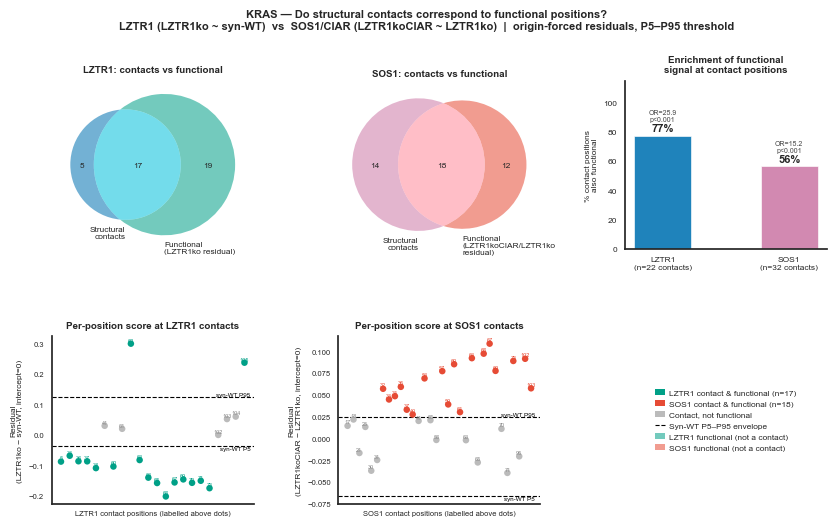

Saved → KRAS_contact_vs_functional_overlap.pdf / .svg


In [74]:
# ═══════════════════════════════════════════════════════════════════════════════
# Contact vs Functional Position Overlap — visualization
# ═══════════════════════════════════════════════════════════════════════════════
from matplotlib_venn import venn2
import matplotlib.patches as mpatches

# Colors from master palette cell (cell 13):
#   Contact circles  → CONTACT palette  (cerulean blue / muted rose)
#   Functional circles → FUNCTIONAL palette  (teal-green / coral-red)
#   Both-and-functional dots → FUNCTIONAL palette (highlights the functional status)
GREY_CLR  = '#BBBBBB'

fig = plt.figure(figsize=(10, 5.5))
fig.subplots_adjust(wspace=0.42, hspace=0.52)
gs = fig.add_gridspec(2, 3)

# ── [0,0] Venn — LZTR1: contact circle (blue) vs functional circle (teal) ─────
ax00 = fig.add_subplot(gs[0, 0])
v = venn2(
    subsets=(len(lztr1_cont_only), len(lztr1_func_only), len(lztr1_both)),
    set_labels=('Structural\ncontacts', 'Functional\n(LZTR1ko residual)'),
    set_colors=[LZTR1_CONTACT_COLOR, LZTR1_FUNC_COLOR], alpha=0.55, ax=ax00
)
for text in (list(v.set_labels) + [v.get_label_by_id(s) for s in ('10','01','11') if v.get_label_by_id(s)]):
    if text: text.set_fontsize(6)
ax00.set_title('LZTR1: contacts vs functional', fontsize=7, fontweight='bold', pad=6)

# ── [0,1] Venn — SOS1: contact circle (rose) vs functional circle (coral) ─────
ax01 = fig.add_subplot(gs[0, 1])
v2 = venn2(
    subsets=(len(sos1_cont_only), len(sos1_func_only), len(sos1_both)),
    set_labels=('Structural\ncontacts', 'Functional\n(LZTR1koCIAR/LZTR1ko\nresidual)'),
    set_colors=[SOS1_CONTACT_COLOR, SOS1_FUNC_COLOR], alpha=0.55, ax=ax01
)
for text in (list(v2.set_labels) + [v2.get_label_by_id(s) for s in ('10','01','11') if v2.get_label_by_id(s)]):
    if text: text.set_fontsize(6)
ax01.set_title('SOS1: contacts vs functional', fontsize=7, fontweight='bold', pad=6)

# ── [0,2] Bar — % of contacts that are functional (bars = contact colors) ──────
ax02 = fig.add_subplot(gs[0, 2])
pcts  = [100*len(lztr1_both)/max(1, len(lztr1_contacts)),
         100*len(sos1_both) /max(1, len(sos1_contacts))]
clrs  = [LZTR1_CONTACT_COLOR, SOS1_CONTACT_COLOR]
xlbls = [f'LZTR1\n(n={len(lztr1_contacts)} contacts)',
         f'SOS1\n(n={len(sos1_contacts)} contacts)']
bars  = ax02.bar(xlbls, pcts, color=clrs, width=0.45, linewidth=0.5,
                 edgecolor='white', alpha=0.88)
for bar, pct, (OR, p) in zip(bars, pcts, [(lztr1_or, lztr1_p), (sos1_or, sos1_p)]):
    ax02.text(bar.get_x() + bar.get_width()/2, pct + 1.5,
              f'{pct:.0f}%', ha='center', fontsize=8, fontweight='bold', va='bottom')
    p_str = 'p<0.001' if p < 0.001 else f'p={p:.3f}'
    ax02.text(bar.get_x() + bar.get_width()/2, pct + 9,
              f'OR={OR:.1f}\n{p_str}', ha='center', fontsize=5,
              color='#444444', va='bottom')
ax02.set_ylim(0, 115)
ax02.set_ylabel('% contact positions\nalso functional', fontsize=6)
ax02.set_title('Enrichment of functional\nsignal at contact positions', fontsize=7, fontweight='bold')
ax02.tick_params(labelsize=6, length=2, width=0.5)
for sp in ['top', 'right']: ax02.spines[sp].set_visible(False)

# ── [1,0] Dot plot — LZTR1 contacts (functional ones highlighted in teal) ──────
ax10 = fig.add_subplot(gs[1, 0])
sorted_lztr1 = sorted(lztr1_contacts)
lztr1_scores = [pos_lztr1.get(p, np.nan) for p in sorted_lztr1]
lztr1_clrs   = [LZTR1_FUNC_COLOR if p in lztr1_both else GREY_CLR for p in sorted_lztr1]
lztr1_func_f = [p in lztr1_both for p in sorted_lztr1]

ax10.scatter(range(len(sorted_lztr1)), lztr1_scores,
             c=lztr1_clrs, s=22, edgecolors='none', zorder=3)
ax10.axhline(lztr1_lo, color='black', linewidth=0.8, linestyle='--', zorder=2)
ax10.axhline(lztr1_hi, color='black', linewidth=0.8, linestyle='--', zorder=2)
ax10.text(len(sorted_lztr1) - 0.3, lztr1_lo, 'syn-WT P5',
          fontsize=4.5, va='top', ha='right', color='black')
ax10.text(len(sorted_lztr1) - 0.3, lztr1_hi, 'syn-WT P95',
          fontsize=4.5, va='bottom', ha='right', color='black')

for i, (p, s, f) in enumerate(zip(sorted_lztr1, lztr1_scores, lztr1_func_f)):
    if not np.isnan(s):
        ax10.text(i, s + pos_lztr1.std() * 0.05,
                  str(p), ha='center', va='bottom', fontsize=4,
                  color=LZTR1_FUNC_COLOR if f else '#888888')

ax10.set_xticks([])
ax10.set_xlabel('LZTR1 contact positions (labelled above dots)', fontsize=5.5)
ax10.set_ylabel('Residual\n(LZTR1ko ~ syn-WT, intercept=0)', fontsize=6)
ax10.set_title('Per-position score at LZTR1 contacts', fontsize=7, fontweight='bold')
ax10.tick_params(labelsize=5.5, length=2, width=0.5)
for sp in ['top', 'right']: ax10.spines[sp].set_visible(False)

# ── [1,1] Dot plot — SOS1 contacts (functional ones highlighted in coral) ───────
ax11 = fig.add_subplot(gs[1, 1])
sorted_sos1 = sorted(sos1_contacts)
sos1_scores = [pos_ciar.get(p, np.nan) for p in sorted_sos1]
sos1_clrs   = [SOS1_FUNC_COLOR if p in sos1_both else GREY_CLR for p in sorted_sos1]
sos1_func_f = [p in sos1_both for p in sorted_sos1]

ax11.scatter(range(len(sorted_sos1)), sos1_scores,
             c=sos1_clrs, s=22, edgecolors='none', zorder=3)
ax11.axhline(ciar_lo, color='black', linewidth=0.8, linestyle='--', zorder=2)
ax11.axhline(ciar_hi, color='black', linewidth=0.8, linestyle='--', zorder=2)
ax11.text(len(sorted_sos1) - 0.3, ciar_lo, 'syn-WT P5',
          fontsize=4.5, va='top', ha='right', color='black')
ax11.text(len(sorted_sos1) - 0.3, ciar_hi, 'syn-WT P95',
          fontsize=4.5, va='bottom', ha='right', color='black')

for i, (p, s, f) in enumerate(zip(sorted_sos1, sos1_scores, sos1_func_f)):
    if not np.isnan(s):
        ax11.text(i, s + pos_ciar.std() * 0.05,
                  str(p), ha='center', va='bottom', fontsize=4,
                  color=SOS1_FUNC_COLOR if f else '#888888')

ax11.set_xticks([])
ax11.set_xlabel('SOS1 contact positions (labelled above dots)', fontsize=5.5)
ax11.set_ylabel('Residual\n(LZTR1koCIAR ~ LZTR1ko, intercept=0)', fontsize=6)
ax11.set_title('Per-position score at SOS1 contacts', fontsize=7, fontweight='bold')
ax11.tick_params(labelsize=5.5, length=2, width=0.5)
for sp in ['top', 'right']: ax11.spines[sp].set_visible(False)

# ── [1,2] Legend ──────────────────────────────────────────────────────────────
ax12 = fig.add_subplot(gs[1, 2])
ax12.axis('off')
legend_items = [
    mpatches.Patch(facecolor=LZTR1_FUNC_COLOR, edgecolor='none',
                   label=f'LZTR1 contact & functional (n={len(lztr1_both)})'),
    mpatches.Patch(facecolor=SOS1_FUNC_COLOR, edgecolor='none',
                   label=f'SOS1 contact & functional (n={len(sos1_both)})'),
    mpatches.Patch(facecolor=GREY_CLR, edgecolor='none',
                   label='Contact, not functional'),
    Line2D([0],[0], color='black', linewidth=0.8, linestyle='--',
           label='Syn-WT P5–P95 envelope'),
    mpatches.Patch(facecolor=LZTR1_FUNC_COLOR, edgecolor='none', alpha=0.55,
                   label='LZTR1 functional (not a contact)'),
    mpatches.Patch(facecolor=SOS1_FUNC_COLOR, edgecolor='none', alpha=0.55,
                   label='SOS1 functional (not a contact)'),
]
ax12.legend(handles=legend_items, loc='center', fontsize=6,
            frameon=False, handlelength=1.2, handletextpad=0.5)

fig.suptitle('KRAS — Do structural contacts correspond to functional positions?\n'
             'LZTR1 (LZTR1ko ~ syn-WT)  vs  SOS1/CIAR (LZTR1koCIAR ~ LZTR1ko)  |  origin-forced residuals, P5–P95 threshold',
             fontsize=8, fontweight='bold', y=1.01)

plt.savefig(os.path.join(output_folder, 'KRAS_contact_vs_functional_overlap.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_contact_vs_functional_overlap.svg'),
            bbox_inches='tight')
plt.show()
print("Saved → KRAS_contact_vs_functional_overlap.pdf / .svg")


In [75]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cross-partner analysis: bifunctional contact positions
# ═══════════════════════════════════════════════════════════════════════════════

# Positions that are contact AND functional for BOTH partners
cross_both = lztr1_both & sos1_both

sep = '─' * 60

# ── Analysis 1: Starting from LZTR1 contact+functional positions ──────────────
print('Analysis 1: LZTR1 contact+functional positions (n={})'.format(len(lztr1_both)))
print(sep)
print(f'  Of {len(lztr1_both)} positions that are LZTR1 contacts AND functional for LZTR1:')
print(f'    → Also SOS1 contact AND functional for SOS1 : {len(cross_both)}  '
      f'({100*len(cross_both)/max(1,len(lztr1_both)):.0f}%)')
print(f'    → Also SOS1 contact but NOT functional SOS1 : '
      f'{len(lztr1_both & sos1_contacts - sos1_functional_pos)}')
print(f'    → NOT a SOS1 contact at all                 : '
      f'{len(lztr1_both - sos1_contacts)}')
print(f'  Positions in both (contact+functional for LZTR1 AND SOS1): {sorted(cross_both)}')

print()

# ── Analysis 2: Starting from SOS1 contact+functional positions ───────────────
print('Analysis 2: SOS1 contact+functional positions (n={})'.format(len(sos1_both)))
print(sep)
print(f'  Of {len(sos1_both)} positions that are SOS1 contacts AND functional for SOS1:')
print(f'    → Also LZTR1 contact AND functional for LZTR1 : {len(cross_both)}  '
      f'({100*len(cross_both)/max(1,len(sos1_both)):.0f}%)')
print(f'    → Also LZTR1 contact but NOT functional LZTR1 : '
      f'{len(sos1_both & lztr1_contacts - lztr1_functional_pos)}')
print(f'    → NOT a LZTR1 contact at all                  : '
      f'{len(sos1_both - lztr1_contacts)}')
print(f'  Positions in both (contact+functional for LZTR1 AND SOS1): {sorted(cross_both)}')

print()

# ── Detailed breakdown of cross_both positions ────────────────────────────────
print('Detailed scores for shared contact+functional positions:')
print(sep)
print(f'  {"Pos":>4}  {"LZTR1ko resid":>14}  {"CIAR/LZ resid":>14}')
for p in sorted(cross_both):
    lz_s  = pos_lztr1.get(p, float('nan'))
    ci_s  = pos_ciar.get(p, float('nan'))
    print(f'  {p:>4}  {lz_s:>14.4f}  {ci_s:>14.4f}')


Analysis 1: LZTR1 contact+functional positions (n=17)
────────────────────────────────────────────────────────────
  Of 17 positions that are LZTR1 contacts AND functional for LZTR1:
    → Also SOS1 contact AND functional for SOS1 : 8  (47%)
    → Also SOS1 contact but NOT functional SOS1 : 4
    → NOT a SOS1 contact at all                 : 5
  Positions in both (contact+functional for LZTR1 AND SOS1): [33, 37, 60, 64, 66, 67, 69, 73]

Analysis 2: SOS1 contact+functional positions (n=18)
────────────────────────────────────────────────────────────
  Of 18 positions that are SOS1 contacts AND functional for SOS1:
    → Also LZTR1 contact AND functional for LZTR1 : 8  (44%)
    → Also LZTR1 contact but NOT functional LZTR1 : 3
    → NOT a LZTR1 contact at all                  : 7
  Positions in both (contact+functional for LZTR1 AND SOS1): [33, 37, 60, 64, 66, 67, 69, 73]

Detailed scores for shared contact+functional positions:
──────────────────────────────────────────────────────────

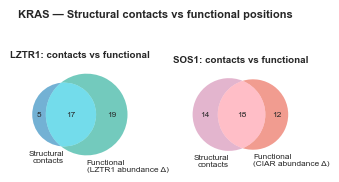

Saved → KRAS_contact_vs_functional_venns.pdf / .svg


In [76]:
# ═══════════════════════════════════════════════════════════════════════════════
# Contact vs Functional — Venn diagrams only (standalone figure)
# ═══════════════════════════════════════════════════════════════════════════════
from matplotlib_venn import venn2

# Colors from master palette cell (cell 13):
#   Contact circles  → CONTACT palette  (cerulean blue / muted rose)
#   Functional circles → FUNCTIONAL palette  (teal-green / coral-red)

fig, (ax_l, ax_s) = plt.subplots(1, 2, figsize=(3.5, 1.93))
fig.subplots_adjust(wspace=0.45)

# ── LZTR1 Venn: contact circle (blue) vs functional circle (teal) ─────────────
v = venn2(
    subsets=(len(lztr1_cont_only), len(lztr1_func_only), len(lztr1_both)),
    set_labels=('Structural\ncontacts', 'Functional\n(LZTR1 abundance Δ)'),
    set_colors=[LZTR1_CONTACT_COLOR, LZTR1_FUNC_COLOR], alpha=0.55, ax=ax_l
)
for text in (list(v.set_labels) + [v.get_label_by_id(s) for s in ('10','01','11') if v.get_label_by_id(s)]):
    if text: text.set_fontsize(6)
ax_l.set_title('LZTR1: contacts vs functional', fontsize=7, fontweight='bold', pad=6)

# ── SOS1/CIAR Venn: contact circle (rose) vs functional circle (coral) ─────────
v2 = venn2(
    subsets=(len(sos1_cont_only), len(sos1_func_only), len(sos1_both)),
    set_labels=('Structural\ncontacts', 'Functional\n(CIAR abundance Δ)'),
    set_colors=[SOS1_CONTACT_COLOR, SOS1_FUNC_COLOR], alpha=0.55, ax=ax_s
)
for text in (list(v2.set_labels) + [v2.get_label_by_id(s) for s in ('10','01','11') if v2.get_label_by_id(s)]):
    if text: text.set_fontsize(6)
ax_s.set_title('SOS1: contacts vs functional', fontsize=7, fontweight='bold', pad=6)

fig.suptitle('KRAS — Structural contacts vs functional positions',
             fontsize=8, fontweight='bold', y=1.04)

plt.savefig(os.path.join(output_folder, 'KRAS_contact_vs_functional_venns.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_contact_vs_functional_venns.svg'),
            bbox_inches='tight')
plt.show()
print("Saved → KRAS_contact_vs_functional_venns.pdf / .svg")


# Generate table for Fig 5h structure

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Position-level summary table
# For each KRAS position: functional flags from bdf, residual medians, and
# the per-position Pearson correlation (missense variants only) between
#   - resid_LZTR1ko  (origin-forced abundance residual vs syn-WT)
#   - LZTR1 interaction score  (average score from interaction assay)
# ═══════════════════════════════════════════════════════════════════════════════
from scipy.stats import pearsonr, spearmanr

# ── 1. Per-variant LZTR1 interaction scores (missense, average score) ──────────────
# Uses the same helper as cell 40: Replicate_scores, assay='interaction',
# assay_treatment='LZTR1', averaged across replicates per variant.
_interact = get_variant_scores_int('kras', 'interaction', 'LZTR1')
_interact_df = _interact.rename('lztr1_interaction').reset_index()  # variant, lztr1_interaction

# ── 2. Per-variant LZTR1ko residuals + Position (missense, from kras_residuals) ─────
_resid_mis = (
    kras_residuals[kras_residuals['Mutation Type'] == 'missense']
    [['variant', 'Position', 'resid_LZTR1ko']]
    .dropna(subset=['resid_LZTR1ko'])
    .copy()
)
_resid_mis['Position'] = pd.to_numeric(_resid_mis['Position'], errors='coerce')
# Mean per (variant, position) in case of any duplicates
_resid_mis = (
    _resid_mis
    .groupby(['variant', 'Position'])['resid_LZTR1ko']
    .mean()
    .reset_index()
)

# ── 3. Join residuals with interaction scores on variant ──────────────────────────
_merged = _resid_mis.merge(_interact_df, on='variant', how='inner')

# ── 4. Per-position Pearson correlation ───────────────────────────────────────────
corr_rows = []
for pos, grp in _merged.groupby('Position'):
    grp = grp.dropna(subset=['lztr1_interaction', 'resid_LZTR1ko'])
    n = len(grp)
    if n >= 3:
        r,  p_r  = pearsonr( grp['lztr1_interaction'], grp['resid_LZTR1ko'])
        rs, p_rs = spearmanr(grp['lztr1_interaction'], grp['resid_LZTR1ko'])
        r2 = r ** 2
    else:
        r = p_r = rs = p_rs = r2 = np.nan
    corr_rows.append({
        'Position':                      int(pos),
        'n_missense_corr':               n,
        'pearson_r_lztr1_interaction':   r,
        'pearson_r2_lztr1_interaction':  r2,
        'pearson_p_lztr1_interaction':   p_r,
        'spearman_r_lztr1_interaction':  rs,
        'spearman_p_lztr1_interaction':  p_rs,
        'mean_lztr1_interaction':        grp['lztr1_interaction'].mean(),
    })

corr_df = pd.DataFrame(corr_rows)

# ── 5. Merge with bdf position-level annotations ───────────────────────────────
_bdf_export = bdf.copy()
_bdf_export['Position'] = _bdf_export['Position'].astype(int)

out_df = _bdf_export.merge(corr_df, on='Position', how='outer')
out_df = out_df.sort_values('Position').reset_index(drop=True)

# ── 6. Select and order export columns ────────────────────────────────────────────
_desired_cols = [
    'Position', 'Interface', 'overlap_class',
    'lz_perturbed', 'lzciar_perturbed', 'bifunctional', 'same_sign',
    'lztr1ko_median', 'resid_LZTR1koCIAR_on_LZTR1ko_median',
    'delta', 'bifunc_score',
    'n_missense_corr',
    'pearson_r_lztr1_interaction', 'pearson_r2_lztr1_interaction',
    'pearson_p_lztr1_interaction',
    'spearman_r_lztr1_interaction', 'spearman_p_lztr1_interaction',
    'mean_lztr1_interaction',
]
export_cols = [c for c in _desired_cols if c in out_df.columns]
out_df = out_df[export_cols]

# ── 7. Save ───────────────────────────────────────────────────────────────────────────────
tsv_path = os.path.join(output_folder, 'KRAS_position_summary.tsv')
out_df.to_csv(tsv_path, sep='\t', index=False, float_format='%.6f')

print(f'Saved → {tsv_path}')
print(f'Shape: {out_df.shape}  ({out_df["Position"].nunique()} positions)')
print(f'Columns: {list(out_df.columns)}')
print(f'\nCorrelation coverage:')
print(f'  Positions with n≥3 variants (r computed): {(~out_df["pearson_r_lztr1_interaction"].isna()).sum()}')
print(f'  Pearson r range:   [{out_df["pearson_r_lztr1_interaction"].min():.3f}, '
      f'{out_df["pearson_r_lztr1_interaction"].max():.3f}]')
print(f'  R² range:          [{out_df["pearson_r2_lztr1_interaction"].min():.3f}, '
      f'{out_df["pearson_r2_lztr1_interaction"].max():.3f}]')
print(f'  Spearman r range:  [{out_df["spearman_r_lztr1_interaction"].min():.3f}, '
      f'{out_df["spearman_r_lztr1_interaction"].max():.3f}]')
print(f'\nSample rows (sorted by |r|):')
print(out_df.dropna(subset=['pearson_r_lztr1_interaction'])
      .reindex(out_df['pearson_r_lztr1_interaction'].abs().nlargest(10).index)
      [['Position', 'Interface', 'overlap_class', 'lztr1ko_median',
        'pearson_r_lztr1_interaction', 'pearson_r2_lztr1_interaction',
        'spearman_r_lztr1_interaction', 'pearson_p_lztr1_interaction']]
      .to_string(index=False))


In [ ]:
# ── Scatterplots: top N positions by |Pearson r| ────────────────────────────────────────────
# x: LZTR1 interaction score   y: resid_LZTR1ko
# Each subplot = one position; dots = individual missense variants
# Ranked by |r| descending; colored by overlap_class
from matplotlib.patches import Patch
import math

# ► Parameters ───────────────────────────────────────────────────────────────────────
N_TOP  = 30     # number of positions to plot
N_COLS = 5      # subplots per row

# Correlation metric used for ranking and subplot title.
# Options: 'pearson_r'   'pearson_r2'   'spearman_r'
CORR_METRIC = 'spearman_r'

# ── Internal mapping ───────────────────────────────────────────────────────────────
_metric_map = {
    'pearson_r':  ('pearson_r_lztr1_interaction',  'pearson_p_lztr1_interaction',  'Pearson r'),
    'pearson_r2': ('pearson_r2_lztr1_interaction', 'pearson_p_lztr1_interaction',  'R²'),
    'spearman_r': ('spearman_r_lztr1_interaction', 'spearman_p_lztr1_interaction', 'Spearman ρ'),
}
assert CORR_METRIC in _metric_map, f'CORR_METRIC must be one of {list(_metric_map)}'
_val_col, _p_col, _metric_label = _metric_map[CORR_METRIC]

# Grid dimensions
N_ROWS = math.ceil(N_TOP / N_COLS)

# Select top N by |metric|
top_n = (
    corr_df
    .dropna(subset=[_val_col])
    .assign(_abs_metric=lambda d: d[_val_col].abs())
    .nlargest(N_TOP, '_abs_metric')
    .sort_values(_val_col, ascending=False)
    .drop(columns='_abs_metric')
)

# Position-level annotation (overlap_class) from bdf
_bdf_info = bdf.set_index('Position')[['overlap_class', 'Interface']].to_dict('index')

fig, axes = plt.subplots(N_ROWS, N_COLS,
                         figsize=(N_COLS * 2.6, N_ROWS * 2.7))
axes = np.array(axes).flatten()   # works whether 1-D or 2-D
fig.subplots_adjust(hspace=0.60, wspace=0.42)

for ax, (_, row) in zip(axes, top_n.iterrows()):
    pos   = int(row['Position'])
    r     = row[_val_col]
    p     = row[_p_col]

    # Variant-level data for this position
    grp = _merged[_merged['Position'] == pos].dropna(
        subset=['lztr1_interaction', 'resid_LZTR1ko']
    )

    # Color by functional class
    cls   = _bdf_info.get(pos, {}).get('overlap_class', 'neither')
    color = overlap_hex.get(cls, '#999999')

    ax.scatter(grp['lztr1_interaction'], grp['resid_LZTR1ko'],
               color=color, s=9, alpha=0.72, linewidths=0, zorder=3)

    # Best-fit line
    x_v, y_v = grp['lztr1_interaction'].values, grp['resid_LZTR1ko'].values
    if len(x_v) >= 2:
        m, b = np.polyfit(x_v, y_v, 1)
        xl = np.linspace(x_v.min(), x_v.max(), 100)
        ax.plot(xl, m * xl + b, color=color, linewidth=0.9, alpha=0.85, zorder=2)

    # Reference lines at 0
    ax.axvline(0, color='#CCCCCC', linewidth=0.5, zorder=1)
    ax.axhline(0, color='#CCCCCC', linewidth=0.5, zorder=1)

    p_str = 'p<0.001' if p < 0.001 else f'p={p:.3f}'
    iface = _bdf_info.get(pos, {}).get('Interface', '')
    ax.set_title(f'Position {pos}  {_metric_label}={r:.2f}', fontsize=6.5, fontweight='bold', pad=3)
    ax.text(0.97, 0.03,
            f'n={len(grp)}  {p_str}\n{iface}',
            transform=ax.transAxes,
            fontsize=4.5, ha='right', va='bottom', color='#555555')

    ax.set_xlabel('LZTR1 interaction score', fontsize=5, labelpad=2)
    ax.set_ylabel('Residual  (LZTR1ko ~ syn-WT)', fontsize=5, labelpad=2)
    ax.tick_params(axis='both', labelsize=4.5, length=2, width=0.4, pad=1)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_linewidth(0.4)
    ax.spines['bottom'].set_linewidth(0.4)

# Hide any unused axes (when N_TOP is not a multiple of N_COLS)
for ax in axes[N_TOP:]:
    ax.set_visible(False)

# Legend
_leg_handles = [
    Patch(facecolor=overlap_hex[k], edgecolor='none', label=overlap_labels[k])
    for k in ['both', 'lzko_only', 'lzciar_only', 'neither']
]
fig.legend(handles=_leg_handles, loc='lower center', bbox_to_anchor=(0.5, -0.03),
           ncol=4, fontsize=6.5, frameon=False,
           handlelength=1.0, handletextpad=0.4, columnspacing=1.2)

fig.suptitle(
    f'Top {N_TOP} positions by |{_metric_label}|\n'
    'LZTR1 interaction score  vs  LZTR1ko abundance residual  (missense variants)',
    fontsize=8, fontweight='bold', y=1.02
)

plt.savefig(os.path.join(output_folder, f'KRAS_top{N_TOP}_{CORR_METRIC}_interaction_vs_residual.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, f'KRAS_top{N_TOP}_{CORR_METRIC}_interaction_vs_residual.png'),
            bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved \u2192 KRAS_top{N_TOP}_{CORR_METRIC}_interaction_vs_residual.pdf / .png')
print(f'\nTop {N_TOP} positions (ranked by |{_metric_label}|):')
print(top_n[['Position', 'n_missense_corr', _val_col, _p_col,
             'mean_lztr1_interaction']].to_string(index=False))


In [ ]:
# ── Single-position scatterplot: Position 132 ───────────────────────────────────────────
# x: LZTR1 interaction score   y: resid_LZTR1ko  (missense variants)
FOCUS_POS = 132

from scipy.stats import pearsonr, spearmanr
from matplotlib.patches import Patch

grp = _merged[_merged['Position'] == FOCUS_POS].dropna(
    subset=['lztr1_interaction', 'resid_LZTR1ko']
).copy()

if grp.empty:
    print(f'No data for position {FOCUS_POS}')
else:
    x_v = grp['lztr1_interaction'].values
    y_v = grp['resid_LZTR1ko'].values

    pr,  pp  = pearsonr( x_v, y_v)
    sr,  sp  = spearmanr(x_v, y_v)
    r2       = pr ** 2

    cls   = _bdf_info.get(FOCUS_POS, {}).get('overlap_class', 'neither')
    iface = _bdf_info.get(FOCUS_POS, {}).get('Interface', '')
    color = overlap_hex.get(cls, '#999999')

    fig, ax = plt.subplots(figsize=(3.5, 3.2))
    fig.subplots_adjust(bottom=0.18, left=0.18)

    ax.scatter(x_v, y_v, color=color, s=22, alpha=0.75, linewidths=0, zorder=3)

    # Label each variant
    for _, vrow in grp.iterrows():
        ax.text(vrow['lztr1_interaction'], vrow['resid_LZTR1ko'],
                f" {vrow['variant']}", fontsize=4, va='center',
                color='#444444', zorder=4)

    # Best-fit line
    m, b = np.polyfit(x_v, y_v, 1)
    xl = np.linspace(x_v.min(), x_v.max(), 200)
    ax.plot(xl, m * xl + b, color=color, linewidth=1.0, alpha=0.85, zorder=2)

    # Reference lines
    ax.axvline(0, color='#CCCCCC', linewidth=0.5, zorder=1)
    ax.axhline(0, color='#CCCCCC', linewidth=0.5, zorder=1)

    # Syn-WT P5/P95 band on y-axis
    y_p05 = syn_iqr['resid_LZTR1ko']['p05']
    y_p95 = syn_iqr['resid_LZTR1ko']['p95']
    ax.axhspan(y_p05, y_p95, facecolor='#DCDCDC', linewidth=0, zorder=0, alpha=0.9)

    # Stats box
    pp_str = 'p<0.001' if pp < 0.001 else f'p={pp:.3f}'
    sp_str = 'p<0.001' if sp < 0.001 else f'p={sp:.3f}'
    stats_txt = (
        f'n = {len(grp)}\n'
        f'Pearson r = {pr:.3f}  ({pp_str})\n'
        f'R² = {r2:.3f}\n'
        f'Spearman ρ = {sr:.3f}  ({sp_str})'
    )
    ax.text(0.03, 0.97, stats_txt, transform=ax.transAxes,
            fontsize=6, va='top', ha='left', color='#333333',
            family='monospace')

    ax.set_xlabel('LZTR1 interaction score', fontsize=8)
    ax.set_ylabel('Residual  (LZTR1ko ~ syn-WT, intercept=0)', fontsize=8)
    ax.set_title(f'Position {FOCUS_POS}  —  {iface}', fontsize=9,
                 fontweight='bold', pad=5)
    ax.tick_params(axis='both', labelsize=7, length=3, width=0.5)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

    plt.savefig(os.path.join(output_folder,
                f'KRAS_pos{FOCUS_POS}_interaction_vs_residual.pdf'),
                bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(output_folder,
                f'KRAS_pos{FOCUS_POS}_interaction_vs_residual.png'),
                bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved → KRAS_pos{FOCUS_POS}_interaction_vs_residual.pdf / .png')
    print(f'\nVariants at position {FOCUS_POS}:')
    print(grp[['variant', 'lztr1_interaction', 'resid_LZTR1ko']]
          .sort_values('lztr1_interaction')
          .to_string(index=False))


# LZTR1ko vs Unperturbed Abundance — Variant Scatterplot

Each point = one missense variant.  
**x:** unperturbed (No_treatment) abundance score  
**y:** LZTR1ko abundance score  

**Functional cutoff band:** origin-forced regression line (LZTR1ko ~ basal, intercept = 0) ± syn-WT P5/P95 residual thresholds. Variants outside the band are functionally perturbed by LZTR1 loss.

**Left panel:** variants at LZTR1-only contact positions (blue) and shared LZTR1∩SOS1 contacts (lavender) highlighted; all others grey.  
**Right panel:** vice versa for SOS1 — SOS1-only (rose) and shared (lavender) highlighted.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# LZTR1ko vs Unperturbed Abundance — Variant Scatterplot
# ═══════════════════════════════════════════════════════════════════════════════
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ── Missense variant data ─────────────────────────────────────────────────────
_sdf = kras_Replicate_scores_wide[
    kras_Replicate_scores_wide['Mutation Type'] == 'missense'
].copy()
_sdf['Position'] = pd.to_numeric(_sdf['Position'], errors='coerce')
_sdf = _sdf.dropna(subset=[COL_BASAL, COL_LZ, 'Position'])
_sdf['Position'] = _sdf['Position'].astype(int)

# ── Contact category per variant (from structural interface sets) ──────────────
# lztr1_only_int, sos1_only_int, shared_pos_int are disjoint integer sets
def _assign_contact_cat(pos):
    if   pos in shared_pos_int:  return 'shared'
    elif pos in lztr1_only_int:  return 'lztr1_only'
    elif pos in sos1_only_int:   return 'sos1_only'
    else:                        return 'other'

_sdf['contact_cat'] = _sdf['Position'].map(_assign_contact_cat)

_cat_n = _sdf['contact_cat'].value_counts()
print("Variants by contact category:")
for cat in ['lztr1_only', 'sos1_only', 'shared', 'other']:
    print(f"  {cat:<12}: {_cat_n.get(cat, 0):,}")
print(f"  {'Total':<12}: {len(_sdf):,}")

# ── Functional cutoff band ────────────────────────────────────────────────────
# Origin-forced fit: LZTR1ko = slope₀ × basal  (intercept = 0)
# Variants with |residual| outside syn-WT P5–P95 are functionally perturbed.
_slope0  = _origin_slopes['LZTR1ko']
_p05     = syn_iqr['resid_LZTR1ko']['p05']   # lower cutoff (↓ abundance in LZTR1ko)
_p95     = syn_iqr['resid_LZTR1ko']['p95']   # upper cutoff (↑ abundance in LZTR1ko)

_x_lo, _x_hi = _sdf[COL_BASAL].quantile(0.005), _sdf[COL_BASAL].quantile(0.995)
_xline = np.linspace(_x_lo, _x_hi, 300)
_y_fit = _slope0 * _xline
_y_lo  = _y_fit + _p05   # lower cutoff line
_y_hi  = _y_fit + _p95   # upper cutoff line

print(f"\nFunctional cutoff (origin-forced, intercept = 0):")
print(f"  Slope₀  = {_slope0:.4f}")
print(f"  P05     = {_p05:.4f}  →  lower cutoff line")
print(f"  P95     = {_p95:.4f}  →  upper cutoff line")

# ── Panel specifications ──────────────────────────────────────────────────────
_GREY = '#DDDDDD'

_panel_specs = [
    dict(
        title='LZTR1 contact positions',
        # Draw grey backgrounds first, highlighted contacts on top
        draw_order=['other', 'sos1_only', 'lztr1_only', 'shared'],
        styles=dict(
            other      = dict(c=_GREY,               s=4,  alpha=0.25, zorder=1, lw=0),
            sos1_only  = dict(c=_GREY,               s=4,  alpha=0.25, zorder=1, lw=0),
            lztr1_only = dict(c=LZTR1_CONTACT_COLOR, s=16, alpha=0.75, zorder=3, lw=0),
            shared     = dict(c=BOTH_FUNC_COLOR,     s=16, alpha=0.80, zorder=4, lw=0),
        ),
    ),
    dict(
        title='SOS1 contact positions',
        draw_order=['other', 'lztr1_only', 'sos1_only', 'shared'],
        styles=dict(
            other      = dict(c=_GREY,              s=4,  alpha=0.25, zorder=1, lw=0),
            lztr1_only = dict(c=_GREY,              s=4,  alpha=0.25, zorder=1, lw=0),
            sos1_only  = dict(c=SOS1_CONTACT_COLOR, s=16, alpha=0.75, zorder=3, lw=0),
            shared     = dict(c=BOTH_FUNC_COLOR,    s=16, alpha=0.80, zorder=4, lw=0),
        ),
    ),
]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.3),
                          gridspec_kw=dict(wspace=0.42))
fig.subplots_adjust(bottom=0.24)

for ax, spec in zip(axes, _panel_specs):

    # ── Scatter layers ─────────────────────────────────────────────────────
    for cat in spec['draw_order']:
        sub = _sdf[_sdf['contact_cat'] == cat]
        st  = spec['styles'][cat]
        ax.scatter(sub[COL_BASAL], sub[COL_LZ],
                   c=st['c'], s=st['s'], alpha=st['alpha'],
                   linewidths=st['lw'], zorder=st['zorder'])

    # ── Functional band (syn-WT envelope) ──────────────────────────────────
    ax.fill_between(_xline, _y_lo, _y_hi,
                    color='#F4F4F4', linewidth=0, zorder=0, alpha=0.85)

    # P05 cutoff (↓ abundance in LZTR1ko = functionally perturbed downward)
    ax.plot(_xline, _y_lo, color='#777777', linewidth=0.8,
            linestyle='--', dashes=(4, 3), zorder=5)
    # P95 cutoff (↑ abundance in LZTR1ko = functionally perturbed upward)
    ax.plot(_xline, _y_hi, color='#777777', linewidth=0.8,
            linestyle='--', dashes=(4, 3), zorder=5)
    # Origin-forced slope reference
    ax.plot(_xline, _y_fit, color='#BBBBBB', linewidth=0.9,
            linestyle='-', zorder=5)

    # ── Region labels ──────────────────────────────────────────────────────
    # Placed at left-edge of axes to avoid obscuring data
    _lx = 0.02   # axes fraction x
    ax.text(_lx, 0.01, '↓ abundance in LZTR1ko\n(LZTR1-sensitive)',
            transform=ax.transAxes, fontsize=4.2, color='#999999',
            ha='left', va='bottom', style='italic', linespacing=1.4)
    ax.text(_lx, 0.99, '↑ abundance in LZTR1ko',
            transform=ax.transAxes, fontsize=4.2, color='#999999',
            ha='left', va='top', style='italic')

    # Band label
    ax.text(0.98, 0.50, 'syn-WT\nrange',
            transform=ax.transAxes, fontsize=4.0, color='#BBBBBB',
            ha='right', va='center', style='italic', linespacing=1.3)

    # n label
    ax.text(0.98, 0.03, f'n = {len(_sdf):,}',
            transform=ax.transAxes, fontsize=5, color='#BBBBBB',
            ha='right', va='bottom')

    # ── Axes formatting ────────────────────────────────────────────────────
    ax.set_xlim(_x_lo, _x_hi)
    ax.set_xlabel('Unperturbed abundance score', fontsize=7, labelpad=3)
    ax.set_ylabel('LZTR1ko abundance score',     fontsize=7, labelpad=3)
    ax.set_title(spec['title'], fontsize=7.5, fontweight='bold', pad=5)
    ax.tick_params(axis='both', labelsize=6, length=2, width=0.5, pad=2)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

# ── Shared legend ─────────────────────────────────────────────────────────────
_legend_handles = [
    Patch(facecolor=_GREY,               edgecolor='none', label='Non-highlighted'),
    Patch(facecolor=LZTR1_CONTACT_COLOR, edgecolor='none',
          label=f'LZTR1-only contacts  ({len(lztr1_only_int)} positions)'),
    Patch(facecolor=SOS1_CONTACT_COLOR,  edgecolor='none',
          label=f'SOS1-only contacts   ({len(sos1_only_int)} positions)'),
    Patch(facecolor=BOTH_FUNC_COLOR,     edgecolor='none',
          label=f'Shared LZTR1∩SOS1   ({len(shared_pos_int)} positions)'),
    Line2D([0],[0], color='#BBBBBB', linewidth=0.9, linestyle='-',
           label=f'Origin-forced fit  (slope₀ = {_slope0:.3f})'),
    Line2D([0],[0], color='#777777', linewidth=0.8, linestyle='--',
           label=f'Syn-WT P5/P95 cutoffs  ({_p05:.3f}, {_p95:.3f})'),
]
fig.legend(handles=_legend_handles,
           loc='lower center', bbox_to_anchor=(0.5, -0.06),
           ncol=3, fontsize=5.0, frameon=False,
           handlelength=1.0, handletextpad=0.4, columnspacing=1.2)

fig.suptitle(
    'KRAS — LZTR1ko vs Unperturbed Abundance Scores  (missense variants)\n'
    f'Functional band: origin-forced slope ± syn-WT P5/P95 residuals',
    fontsize=7.5, fontweight='bold', y=1.03
)

plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1ko_vs_basal_scatter.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_LZTR1ko_vs_basal_scatter.svg'),
            bbox_inches='tight')
plt.show()
print("Saved → KRAS_LZTR1ko_vs_basal_scatter.pdf / .svg")


# LZTR1ko Abundance Heatmap — Modified Layout
LZTR1 contact bar only (no SOS1 bar) + median LZTR1ko residual bar plot above heatmap.

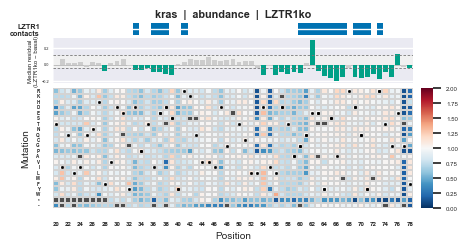

Saved → kras_LZTR1ko_abundance_subset.svg / .pdf

Bar chart summary (20–78):
  Positions plotted       : 59
  Functionally perturbed  : 29  (|residual| outside syn-WT P5–P95)
  Syn-WT band             : [-0.0376, 0.1220]


In [60]:
# ═══════════════════════════════════════════════════════════════════════════════
# LZTR1ko Abundance Heatmap — modified layout
#   Row 0 : LZTR1 contact annotation bar         (same as original)
#   Row 1 : Median LZTR1ko residual bar chart    (replaces SOS1 bar)
#   Row 2 : spacer
#   Row 3 : DMS heatmap + colorbar
# ═══════════════════════════════════════════════════════════════════════════════
from matplotlib import gridspec as mpl_gs
import matplotlib.colors as mcolors

# ── Call parameters (matching original) ───────────────────────────────────────
_ASSAY      = 'abundance'
_TREATMENT  = 'LZTR1ko'
_PROTEIN    = 'kras'
_SCORE_COL  = 'average score'
_SCALE_TYPE = 'linear'
_FIRST_POS  = 20
_LAST_POS   = 78
_FIGSIZE    = (5, 2)
_FONT_SCALE = 0.4
_MISS_CLR   = '#4d4d4d'

# ── Data prep (mirrors generate_heatmap_for_combo) ────────────────────────────
_hm = Replicate_scores.copy()
_hm = convert_AA_abbreviation(_hm)

_combo = _hm[
    (_hm['assay']           == _ASSAY) &
    (_hm['assay_treatment'] == _TREATMENT) &
    (_hm['protein']         == _PROTEIN)
].copy()
_combo['Position'] = pd.to_numeric(_combo['Position'], errors='coerce')
_combo = _combo.dropna(subset=['Position'])
_combo['Position'] = _combo['Position'].astype(int)
_combo = _combo[(_combo['Position'] >= _FIRST_POS) & (_combo['Position'] <= _LAST_POS)]

# Synonymous WT rows for dot markers
_wt_rows = _combo[_combo['Mutation Type'].str.lower().str.contains('synonymous', na=False)].copy()

# Heatmap pivot
_pivot = (
    _combo.groupby(['Position', 'Mutation'])[_SCORE_COL]
    .mean().unstack().transpose()
)
_orders = ['R','K','H','D','E','S','T','N','Q','C','G','P','A','V','I','L','M','F','Y','W','*','-']
_pivot  = _pivot.reindex(_orders, axis=0)

n_pos = len(_pivot.columns)
n_aa  = len(_pivot)
_pos_list = list(_pivot.columns)
_aa_list  = list(_pivot.index)

# ── Scale-dependent sizing (mirrors generate_heatmap_for_combo) ───────────────
_fig_h = _FIGSIZE[1]
_fig_w = _FIGSIZE[0]
_msize      = (_fig_h / 6.14) * 5        # WT dot size
_clab_sz    = (_fig_h / 6.14) * 16       # contact-bar label size
_ytick_sz   = (_fig_h / 6.14) * 10       # heatmap y-tick size
_lab_sz     = (_fig_h / 6.14) * 22       # axis label size
_title_sz   = (_fig_h / 6.14) * 24       # title size

vmin, vmax, center = get_scale(_ASSAY, _SCALE_TYPE, vmin=None, vmax=None, center=None)
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color=_MISS_CLR)
sns.set(font_scale=_FONT_SCALE)

# ── Median LZTR1ko residual per position (from pos_df) ────────────────────────
_resid_map = pos_df.set_index('Position')['lztr1ko_median']
_bar_vals  = np.array([_resid_map.get(p, np.nan) for p in _pos_list])

# Functional threshold lines
_bnd_lo = syn_iqr['resid_LZTR1ko']['p05']
_bnd_hi = syn_iqr['resid_LZTR1ko']['p95']

# Color bars: perturbed positions (outside syn-WT band) in LZTR1_FUNC_COLOR
_lztr1_func_pos = set(bdf.loc[bdf['lz_perturbed'], 'Position'].astype(int))
_bar_clrs = [
    LZTR1_FUNC_COLOR
    if (not np.isnan(v) and p in _lztr1_func_pos)
    else '#CCCCCC'
    for v, p in zip(_bar_vals, _pos_list)
]

# ── Exact-size layout (all values in inches) ──────────────────────────────────
HEATMAP_W_IN   = 3.6      # <- required heatmap width (data area only)
HEATMAP_H_IN   = 1.2      # <- required heatmap height (data area only)

MARGIN_LEFT    = 0.55     # room for y tick labels + "Mutation" ylabel
MARGIN_BOTTOM  = 0.40     # room for x tick labels + "Position" xlabel
GAP_HM_BAR     = 0.05     # gap between heatmap and residual bar chart
BAR_H_IN       = 0.45     # residual bar chart height
GAP_BAR_LZTR1  = 0.03     # gap between residual bar and LZTR1 strip
LZTR1_H_IN     = 0.12     # LZTR1 contact strip height
TITLE_PAD_IN   = 0.20     # room above LZTR1 strip for the title

GAP_HM_CBAR    = 0.08     # gap between heatmap and colorbar
CBAR_W_IN      = 0.12     # colorbar width

# Total figure size implied by the above
fig_w = MARGIN_LEFT + HEATMAP_W_IN + GAP_HM_CBAR + CBAR_W_IN + 0.15
fig_h = (MARGIN_BOTTOM + HEATMAP_H_IN + GAP_HM_BAR + BAR_H_IN
         + GAP_BAR_LZTR1 + LZTR1_H_IN + TITLE_PAD_IN)

fig = plt.figure(figsize=(fig_w, fig_h))

def rect_in(left, bottom, width, height):
    """Convert an (left, bottom, width, height) spec in inches to figure-fraction."""
    return [left / fig_w, bottom / fig_h, width / fig_w, height / fig_h]

# Heatmap — exact size, anchored at bottom-left of the plot stack
ax_hm = fig.add_axes(rect_in(MARGIN_LEFT, MARGIN_BOTTOM, HEATMAP_W_IN, HEATMAP_H_IN))

# Residual bar chart — same width/x-position as heatmap, stacked above it
_bar_bottom = MARGIN_BOTTOM + HEATMAP_H_IN + GAP_HM_BAR
ax_bar = fig.add_axes(rect_in(MARGIN_LEFT, _bar_bottom, HEATMAP_W_IN, BAR_H_IN))

# LZTR1 contact strip — same width/x-position, stacked above the bar chart
_lztr1_bottom = _bar_bottom + BAR_H_IN + GAP_BAR_LZTR1
ax_lztr1 = fig.add_axes(rect_in(MARGIN_LEFT, _lztr1_bottom, HEATMAP_W_IN, LZTR1_H_IN))

# Colorbar — same height/y-position as heatmap, to its right
ax_cbar = fig.add_axes(rect_in(MARGIN_LEFT + HEATMAP_W_IN + GAP_HM_CBAR,
                                MARGIN_BOTTOM, CBAR_W_IN, HEATMAP_H_IN))

# ── Row 0: LZTR1 contact annotation bar ───────────────────────────────────────
_rgba = np.ones((1, n_pos, 4), dtype=float)
for j, pos in enumerate(_pos_list):
    if pos in kras_lztr1_pos:
        _rgba[0, j] = mcolors.to_rgba(LZTR1_COLOR)
ax_lztr1.imshow(_rgba, aspect='auto', interpolation='none',
                extent=[0, n_pos, 0, 1])
ax_lztr1.set_yticks([0.5])
ax_lztr1.set_yticklabels(['LZTR1\ncontacts'], fontsize=_clab_sz,
                          fontweight='bold')
ax_lztr1.set_xlim(0, n_pos)
ax_lztr1.set_ylim(0, 1)
ax_lztr1.set_xticks([])
ax_lztr1.tick_params(left=False)
for _sp in ax_lztr1.spines.values(): _sp.set_visible(False)
ax_lztr1.set_title(
    f"{_PROTEIN}  |  {_ASSAY}  |  {_TREATMENT}",
    fontsize=_title_sz, fontweight='bold', pad=4,
)

# ── Row 1: Median LZTR1ko residual bar chart ──────────────────────────────────
_bx = np.arange(n_pos) + 0.5   # bar centres aligned with heatmap cell centres

ax_bar.bar(_bx, _bar_vals, width=0.8, color=_bar_clrs, linewidth=0, zorder=3)

# Syn-WT reference band
ax_bar.axhspan(_bnd_lo, _bnd_hi, color='#F0F0F0', linewidth=0, zorder=1)
# P05 / P95 cutoff lines
ax_bar.axhline(_bnd_lo, color='#777777', linewidth=0.6,
               linestyle='--', dashes=(3, 2), zorder=4)
ax_bar.axhline(_bnd_hi, color='#777777', linewidth=0.6,
               linestyle='--', dashes=(3, 2), zorder=4)
# Zero reference
ax_bar.axhline(0, color='#AAAAAA', linewidth=0.5, zorder=2)

ax_bar.set_xlim(0, n_pos)
ax_bar.set_xticks([])
ax_bar.set_ylabel('Median residual\n(LZTR1ko ~ basal)',
                  fontsize=_clab_sz * 0.85, labelpad=2)
ax_bar.tick_params(axis='y', labelsize=_ytick_sz * 0.85,
                   length=1.5, width=0.4, pad=1)
ax_bar.yaxis.set_major_locator(plt.MaxNLocator(3, prune='both'))
for _sp in ['top', 'right', 'bottom']:
    ax_bar.spines[_sp].set_visible(False)
ax_bar.spines['left'].set_linewidth(0.4)

# ── Row 3: DMS heatmap ────────────────────────────────────────────────────────
sns.heatmap(
    _pivot,
    cmap=cmap,
    vmin=vmin, vmax=vmax, center=center,
    ax=ax_hm,
    cbar=True, cbar_ax=ax_cbar,
    linewidths=0.3, linecolor='lightgrey',
)

# WT-residue dot markers
for _, row in _wt_rows.iterrows():
    pos, wt_aa = row['Position'], row['Wild Type Residue']
    if pos in _pos_list and wt_aa in _aa_list:
        ax_hm.plot(
            _pos_list.index(pos) + 0.5,
            _aa_list.index(wt_aa) + 0.5,
            'o', color='black',
            markersize=_msize,
            markeredgewidth=_msize * 0.3,
            zorder=5,
        )

ax_hm.set_xlabel('Position', fontsize=_lab_sz, fontfamily='sans-serif')
ax_hm.set_ylabel('Mutation', fontsize=_lab_sz, fontfamily='sans-serif')
ax_hm.tick_params(left=False, bottom=False)

ax_hm.set_yticks([i + 0.5 for i in range(len(_aa_list))])
ax_hm.set_yticklabels(
    _aa_list, fontsize=_ytick_sz, fontweight='bold',
    fontfamily='sans-serif', rotation=0,
)
for lbl in ax_hm.get_xticklabels():
    lbl.set_fontweight('bold')
    lbl.set_fontfamily('sans-serif')
    lbl.set_rotation(0)

plt.rcParams['pdf.fonttype'] = 42
plt.tight_layout()

plt.savefig('/Users/jsimon/Downloads/kras_LZTR1ko_abundance_subset.svg')
plt.savefig(os.path.join(output_folder, 'kras_LZTR1ko_abundance_subset.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()
print("Saved → kras_LZTR1ko_abundance_subset.svg / .pdf")
print(f"\nBar chart summary ({_FIRST_POS}–{_LAST_POS}):")
print(f"  Positions plotted       : {n_pos}")
print(f"  Functionally perturbed  : {sum(p in _lztr1_func_pos for p in _pos_list)}"
      f"  (|residual| outside syn-WT P5–P95)")
print(f"  Syn-WT band             : [{_bnd_lo:.4f}, {_bnd_hi:.4f}]")


# LZTR1koCIAR Abundance Heatmap — SOS1 contacts, positions 20–78
SOS1 contact bar + median LZTR1koCIAR ~ LZTR1ko residual bar, positions 20–78 only.

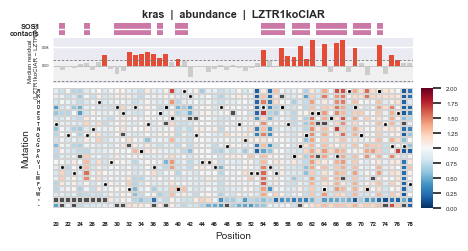

Saved → kras_LZTR1koCIAR_abundance_subset.svg / .pdf

Bar chart summary (20–78):
  Positions plotted      : 59
  Functionally perturbed : 23  (|residual| outside syn-WT P5–P95 for LZTR1koCIAR ~ LZTR1ko)
  Syn-WT band            : [-0.0666, 0.0242]


In [58]:
# ═══════════════════════════════════════════════════════════════════════════════
# LZTR1koCIAR Abundance Heatmap — SOS1 contacts, positions 20–78
#   Row 0 : SOS1 contact annotation bar
#   Row 1 : Median LZTR1koCIAR ~ LZTR1ko residual bar chart
#   Row 2 : spacer
#   Row 3 : DMS heatmap + colorbar
# ═══════════════════════════════════════════════════════════════════════════════
from matplotlib import gridspec as mpl_gs
import matplotlib.colors as mcolors

# ── Parameters ────────────────────────────────────────────────────────────────
_ASSAY      = 'abundance'
_TREATMENT  = 'LZTR1koCIAR'
_PROTEIN    = 'kras'
_SCORE_COL  = 'average score'
_SCALE_TYPE = 'linear'
_FIRST_POS  = 20
_LAST_POS   = 78
_FIGSIZE    = (5, 2)
_FONT_SCALE = 0.4
_MISS_CLR   = '#4d4d4d'

# ── Data prep ─────────────────────────────────────────────────────────────────
_hm = Replicate_scores.copy()
_hm = convert_AA_abbreviation(_hm)

_combo = _hm[
    (_hm['assay']           == _ASSAY) &
    (_hm['assay_treatment'] == _TREATMENT) &
    (_hm['protein']         == _PROTEIN)
].copy()
_combo['Position'] = pd.to_numeric(_combo['Position'], errors='coerce')
_combo = _combo.dropna(subset=['Position'])
_combo['Position'] = _combo['Position'].astype(int)
_combo = _combo[(_combo['Position'] >= _FIRST_POS) & (_combo['Position'] <= _LAST_POS)]

_wt_rows = _combo[_combo['Mutation Type'].str.lower().str.contains('synonymous', na=False)].copy()

_pivot = (
    _combo.groupby(['Position', 'Mutation'])[_SCORE_COL]
    .mean().unstack().transpose()
)
_orders = ['R','K','H','D','E','S','T','N','Q','C','G','P','A','V','I','L','M','F','Y','W','*','-']
_pivot  = _pivot.reindex(_orders, axis=0)

n_pos = len(_pivot.columns)
n_aa  = len(_pivot)
_pos_list = list(_pivot.columns)
_aa_list  = list(_pivot.index)

# ── Scale-dependent sizing ─────────────────────────────────────────────────────
_fig_h    = _FIGSIZE[1]
_fig_w    = _FIGSIZE[0]
_msize    = (_fig_h / 6.14) * 5
_clab_sz  = (_fig_h / 6.14) * 16
_ytick_sz = (_fig_h / 6.14) * 10
_lab_sz   = (_fig_h / 6.14) * 22
_title_sz = (_fig_h / 6.14) * 24

vmin, vmax, center = get_scale(_ASSAY, _SCALE_TYPE, vmin=None, vmax=None, center=None)
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color=_MISS_CLR)
sns.set(font_scale=_FONT_SCALE)

# ── Median LZTR1koCIAR ~ LZTR1ko residual per position ───────────────────────
_resid_map = pos_df.set_index('Position')['resid_LZTR1koCIAR_on_LZTR1ko_median']
_bar_vals  = np.array([_resid_map.get(p, np.nan) for p in _pos_list])

_bnd_lo = syn_iqr['resid_LZTR1koCIAR_on_LZTR1ko']['p05']
_bnd_hi = syn_iqr['resid_LZTR1koCIAR_on_LZTR1ko']['p95']

_ciar_func_pos = set(bdf.loc[bdf['lzciar_perturbed'], 'Position'].astype(int))
_bar_clrs = [
    SOS1_FUNC_COLOR if (not np.isnan(v) and p in _ciar_func_pos) else '#CCCCCC'
    for v, p in zip(_bar_vals, _pos_list)
]

# ── Exact-size layout (all values in inches) ──────────────────────────────────
HEATMAP_W_IN   = 3.6      # <- required heatmap width (data area only)
HEATMAP_H_IN   = 1.2      # <- required heatmap height (data area only)

MARGIN_LEFT    = 0.55     # room for y tick labels + "Mutation" ylabel
MARGIN_BOTTOM  = 0.40     # room for x tick labels + "Position" xlabel
GAP_HM_BAR     = 0.05     # gap between heatmap and residual bar chart
BAR_H_IN       = 0.45     # residual bar chart height
GAP_BAR_SOS1   = 0.03     # gap between residual bar and SOS1 strip
SOS1_H_IN      = 0.12     # SOS1 contact strip height
TITLE_PAD_IN   = 0.20     # room above SOS1 strip for the title

GAP_HM_CBAR    = 0.08     # gap between heatmap and colorbar
CBAR_W_IN      = 0.12     # colorbar width

# Total figure size implied by the above
fig_w = MARGIN_LEFT + HEATMAP_W_IN + GAP_HM_CBAR + CBAR_W_IN + 0.15
fig_h = (MARGIN_BOTTOM + HEATMAP_H_IN + GAP_HM_BAR + BAR_H_IN
         + GAP_BAR_SOS1 + SOS1_H_IN + TITLE_PAD_IN)

fig = plt.figure(figsize=(fig_w, fig_h))

def rect_in(left, bottom, width, height):
    """Convert an (left, bottom, width, height) spec in inches to figure-fraction."""
    return [left / fig_w, bottom / fig_h, width / fig_w, height / fig_h]

# Heatmap — exact size, anchored at bottom-left of the plot stack
ax_hm = fig.add_axes(rect_in(MARGIN_LEFT, MARGIN_BOTTOM, HEATMAP_W_IN, HEATMAP_H_IN))

# Residual bar chart — same width/x-position as heatmap, stacked above it
_bar_bottom = MARGIN_BOTTOM + HEATMAP_H_IN + GAP_HM_BAR
ax_bar = fig.add_axes(rect_in(MARGIN_LEFT, _bar_bottom, HEATMAP_W_IN, BAR_H_IN))

# SOS1 contact strip — same width/x-position, stacked above the bar chart
_sos1_bottom = _bar_bottom + BAR_H_IN + GAP_BAR_SOS1
ax_sos1 = fig.add_axes(rect_in(MARGIN_LEFT, _sos1_bottom, HEATMAP_W_IN, SOS1_H_IN))

# Colorbar — same height/y-position as heatmap, to its right
ax_cbar = fig.add_axes(rect_in(MARGIN_LEFT + HEATMAP_W_IN + GAP_HM_CBAR,
                                MARGIN_BOTTOM, CBAR_W_IN, HEATMAP_H_IN))

# ── Row 0: SOS1 contact annotation bar ───────────────────────────────────────
_rgba = np.ones((1, n_pos, 4), dtype=float)
for j, pos in enumerate(_pos_list):
    if pos in kras_sos1_pos:
        _rgba[0, j] = mcolors.to_rgba(SOS1_COLOR)
ax_sos1.imshow(_rgba, aspect='auto', interpolation='none',
               extent=[0, n_pos, 0, 1])
ax_sos1.set_yticks([0.5])
ax_sos1.set_yticklabels(['SOS1\ncontacts'], fontsize=_clab_sz, fontweight='bold')
ax_sos1.set_xlim(0, n_pos)
ax_sos1.set_ylim(0, 1)
ax_sos1.set_xticks([])
ax_sos1.tick_params(left=False)
for _sp in ax_sos1.spines.values(): _sp.set_visible(False)
ax_sos1.set_title(
    f"{_PROTEIN}  |  {_ASSAY}  |  {_TREATMENT}",
    fontsize=_title_sz, fontweight='bold', pad=4,
)

# ── Row 1: Median LZTR1koCIAR ~ LZTR1ko residual bar chart ───────────────────
_bx = np.arange(n_pos) + 0.5

ax_bar.bar(_bx, _bar_vals, width=0.8, color=_bar_clrs, linewidth=0, zorder=3)

ax_bar.axhspan(_bnd_lo, _bnd_hi, color='#F0F0F0', linewidth=0, zorder=1)
ax_bar.axhline(_bnd_lo, color='#777777', linewidth=0.6,
               linestyle='--', dashes=(3, 2), zorder=4)
ax_bar.axhline(_bnd_hi, color='#777777', linewidth=0.6,
               linestyle='--', dashes=(3, 2), zorder=4)
ax_bar.axhline(0, color='#AAAAAA', linewidth=0.5, zorder=2)

ax_bar.set_xlim(0, n_pos)
ax_bar.set_xticks([])
ax_bar.set_ylabel('Median residual\n(LZTR1koCIAR ~ LZTR1ko)',
                  fontsize=_clab_sz * 0.85, labelpad=2)
ax_bar.tick_params(axis='y', labelsize=_ytick_sz * 0.85,
                   length=1.5, width=0.4, pad=1)
ax_bar.yaxis.set_major_locator(plt.MaxNLocator(3, prune='both'))
for _sp in ['top', 'right', 'bottom']:
    ax_bar.spines[_sp].set_visible(False)
ax_bar.spines['left'].set_linewidth(0.4)

# ── Row 3: DMS heatmap ────────────────────────────────────────────────────────
sns.heatmap(
    _pivot,
    cmap=cmap,
    vmin=vmin, vmax=vmax, center=center,
    ax=ax_hm,
    cbar=True, cbar_ax=ax_cbar,
    linewidths=0.3, linecolor='lightgrey',
)

for _, row in _wt_rows.iterrows():
    pos, wt_aa = row['Position'], row['Wild Type Residue']
    if pos in _pos_list and wt_aa in _aa_list:
        ax_hm.plot(
            _pos_list.index(pos) + 0.5,
            _aa_list.index(wt_aa) + 0.5,
            'o', color='black',
            markersize=_msize,
            markeredgewidth=_msize * 0.3,
            zorder=5,
        )

ax_hm.set_xlabel('Position', fontsize=_lab_sz, fontfamily='sans-serif')
ax_hm.set_ylabel('Mutation', fontsize=_lab_sz, fontfamily='sans-serif')
ax_hm.tick_params(left=False, bottom=False)
ax_hm.set_yticks([i + 0.5 for i in range(len(_aa_list))])
ax_hm.set_yticklabels(
    _aa_list, fontsize=_ytick_sz, fontweight='bold',
    fontfamily='sans-serif', rotation=0,
)
for lbl in ax_hm.get_xticklabels():
    lbl.set_fontweight('bold')
    lbl.set_fontfamily('sans-serif')
    lbl.set_rotation(0)

plt.rcParams['pdf.fonttype'] = 42
plt.tight_layout()

plt.savefig('/Users/jsimon/Downloads/kras_LZTR1koCIAR_abundance_subset.svg')
plt.savefig(os.path.join(output_folder, 'kras_LZTR1koCIAR_abundance_subset.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()
print("Saved → kras_LZTR1koCIAR_abundance_subset.svg / .pdf")
print(f"\nBar chart summary ({_FIRST_POS}–{_LAST_POS}):")
print(f"  Positions plotted      : {n_pos}")
print(f"  Functionally perturbed : {sum(p in _ciar_func_pos for p in _pos_list)}"
      f"  (|residual| outside syn-WT P5–P95 for LZTR1koCIAR ~ LZTR1ko)")
print(f"  Syn-WT band            : [{_bnd_lo:.4f}, {_bnd_hi:.4f}]")


# Functional-only Structure Renders
3-class coloring per structure: **contact** (structural contact color) | **non-contact functional** (assay color) | **non-functional** (grey).  
LZTR1 structure highlights positions perturbed in LZTR1ko (`lz_perturbed`); SOS1 structure highlights positions perturbed by CIAR (`lzciar_perturbed`).

LZTR1 structure (9MF0):
  Contact & LZTR1-functional     : 17  [5, 33, 36, 37, 38, 60, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 105]
  Non-contact & LZTR1-functional : 19  [3, 7, 17, 19, 28, 34, 35, 39, 54, 56, 57, 58, 59, 72, 74, 75, 76, 78, 119]

SOS1 structure (1NVU):
  Contact & SOS1-functional      : 18  [32, 33, 34, 35, 37, 40, 54, 57, 59, 60, 61, 64, 66, 67, 69, 73, 102, 103]
  Non-contact & SOS1-functional  : 12  [12, 13, 28, 36, 38, 58, 62, 75, 76, 100, 180, 187]
PNG 9MF0_default: OK
PNG 9MF0_180Y: OK
PNG 1NVU_default: OK
PNG 1NVU_180Y: OK

PSE 9MF0: OK  →  /Users/jsimon/Downloads/KRAS_functional_9MF0.pse
PSE 1NVU: OK  →  /Users/jsimon/Downloads/KRAS_functional_1NVU.pse


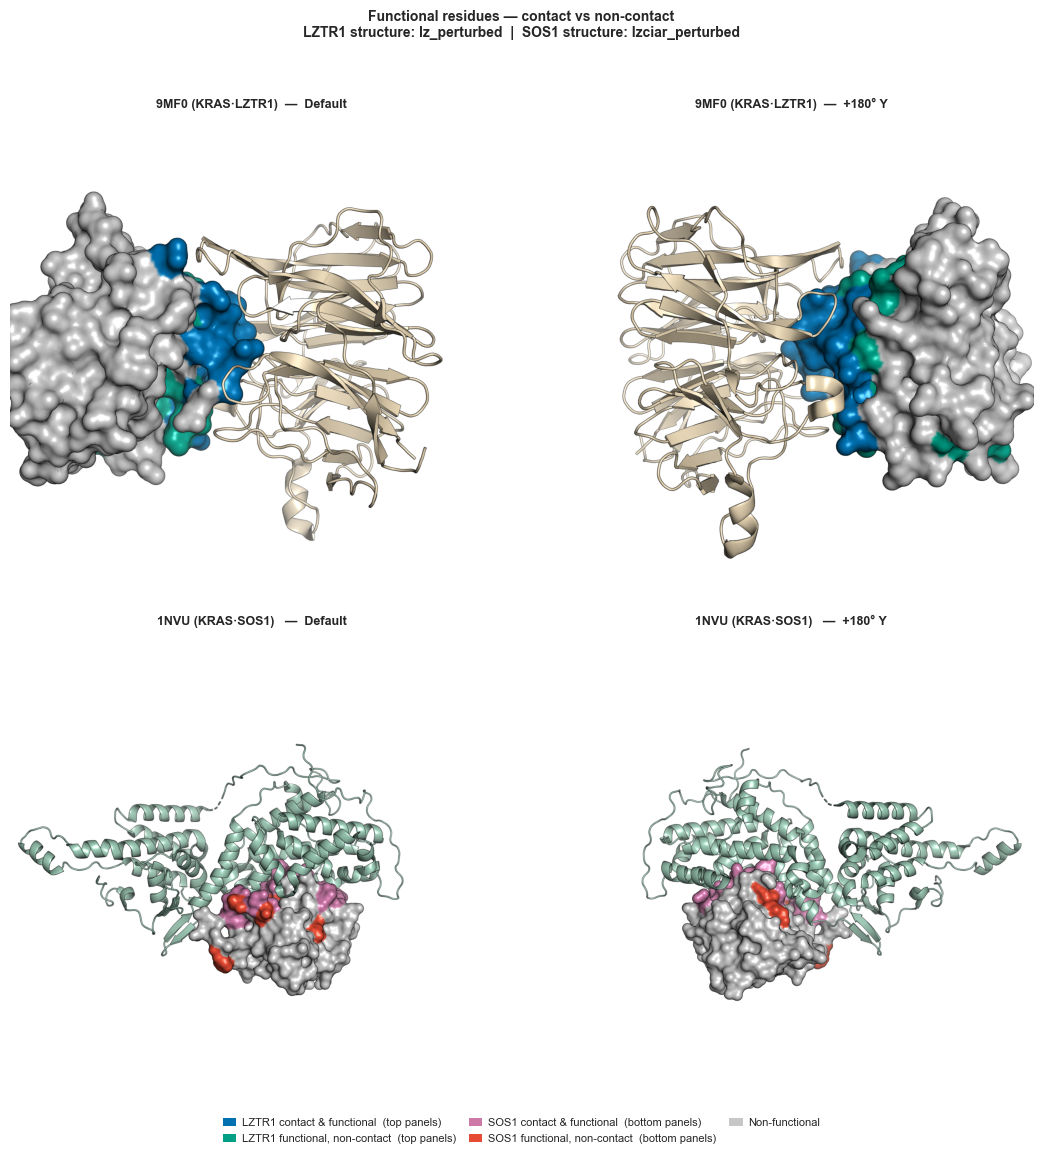


Saved → KRAS_functional_contact_2x2.pdf / .png
Sessions → KRAS_functional_9MF0.pse  |  KRAS_functional_1NVU.pse


In [70]:
import subprocess, matplotlib.pyplot as plt, matplotlib.image as mpimg
from matplotlib.patches import Patch

NB_DIR = '/Users/jsimon/Library/Mobile Documents/com~apple~CloudDocs/Documents/Lab/**RNABinderProject/MAPK_collab/Code Notebooks/LABEL-seq Assays/LABELseq_pathway_analyses'
PYMOL  = '/opt/anaconda3/envs/jlab4/bin/pymol'

# ── Position sets ─────────────────────────────────────────────────────────────
_bdf_pos      = set(bdf['Position'].astype(int))
_lztr1_func   = set(bdf.loc[bdf['lz_perturbed'],    'Position'].astype(int))
_sos1_func    = set(bdf.loc[bdf['lzciar_perturbed'], 'Position'].astype(int))
_lztr1_cont   = {int(p) for p in kras_lztr1_pos} & _bdf_pos
_sos1_cont    = {int(p) for p in kras_sos1_pos}  & _bdf_pos

# LZTR1 structure: contact+functional / noncontact+functional / grey
lztr1_contact_func    = _lztr1_cont & _lztr1_func
lztr1_noncontact_func = _lztr1_func - _lztr1_cont

# SOS1 structure: contact+functional / noncontact+functional / grey
sos1_contact_func     = _sos1_cont  & _sos1_func
sos1_noncontact_func  = _sos1_func  - _sos1_cont

print("LZTR1 structure (9MF0):")
print(f"  Contact & LZTR1-functional     : {len(lztr1_contact_func)}  {sorted(lztr1_contact_func)}")
print(f"  Non-contact & LZTR1-functional : {len(lztr1_noncontact_func)}  {sorted(lztr1_noncontact_func)}")
print()
print("SOS1 structure (1NVU):")
print(f"  Contact & SOS1-functional      : {len(sos1_contact_func)}  {sorted(sos1_contact_func)}")
print(f"  Non-contact & SOS1-functional  : {len(sos1_noncontact_func)}  {sorted(sos1_noncontact_func)}")

# ── Colors (from master palette) ──────────────────────────────────────────────
_LZ_CONT_RGB  = [0.000, 0.447, 0.698]   # LZTR1_CONTACT_COLOR  #0072B2 cerulean blue
_LZ_FUNC_RGB  = [0.000, 0.627, 0.529]   # LZTR1_FUNC_COLOR     #00A087 teal-green
_S1_CONT_RGB  = [0.800, 0.475, 0.655]   # SOS1_CONTACT_COLOR   #CC79A7 muted rose
_S1_FUNC_RGB  = [0.902, 0.294, 0.208]   # SOS1_FUNC_COLOR      #E64B35 coral-red
_GREY_RGB     = [0.780, 0.780, 0.780]   # non-functional        #C7C7C7

def _resi(pos_set):
    return '+'.join(str(p) for p in sorted(pos_set)) if pos_set else 'none'

def _color_block(contact_func, noncontact_func, contact_rgb, noncontact_rgb,
                 grey_rgb=_GREY_RGB):
    """Returns PML lines that apply the 3-class coloring to kras_chain."""
    lines = [
        f"set_color col_grey,       [{grey_rgb[0]:.3f}, {grey_rgb[1]:.3f}, {grey_rgb[2]:.3f}]",
        f"set_color col_noncontact, [{noncontact_rgb[0]:.3f}, {noncontact_rgb[1]:.3f}, {noncontact_rgb[2]:.3f}]",
        f"set_color col_contact,    [{contact_rgb[0]:.3f}, {contact_rgb[1]:.3f}, {contact_rgb[2]:.3f}]",
        "color col_grey, kras_chain",
    ]
    if noncontact_func:
        lines += [
            f"select sel_noncontact, kras_chain and resi {_resi(noncontact_func)}",
            "color col_noncontact, sel_noncontact",
        ]
    if contact_func:
        lines += [
            f"select sel_contact, kras_chain and resi {_resi(contact_func)}",
            "color col_contact, sel_contact",
        ]
    return lines

def _structure_block(cif_path, kras_chain, partner_chain, partner_color):
    """Returns PML lines that load and display the structure."""
    return [
        f"load {cif_path}, raw",
        f"create kras_chain, raw and chain {kras_chain}",
        f"create partner_chain, raw and chain {partner_chain}",
        "delete raw",
        "hide everything",
        "bg_color white",
        "show surface, kras_chain",
        "show cartoon, kras_chain",
        "show cartoon, partner_chain",
        f"set_color col_partner, {partner_color}",
        "color col_partner, partner_chain",
        "set surface_quality, 1",
        "set surface_solvent, 0",
        "set cartoon_loop_radius, 0.20",
        "set cartoon_tube_radius, 0.25",
        "set cartoon_helix_radius, 0.75",
    ]

def make_functional_png_pml(cif_path, kras_chain, partner_chain, partner_color,
                              rotation_cmd, png_path,
                              contact_func, noncontact_func,
                              contact_rgb, noncontact_rgb, ray_size=2400):
    """PML script that renders a PNG (for notebook display)."""
    lines = (
        _structure_block(cif_path, kras_chain, partner_chain, partner_color) +
        _color_block(contact_func, noncontact_func, contact_rgb, noncontact_rgb) +
        [
            "set ray_shadows, 0", "set antialias, 2",
            "set ray_trace_mode, 1", "set ray_opaque_background, on",
            "orient all", rotation_cmd, "zoom all, 4",
            f"ray {ray_size}, {ray_size}",
            f"png {png_path}, dpi=300",
            "quit",
        ]
    )
    return '\n'.join(lines)

def make_functional_pse_pml(cif_path, kras_chain, partner_chain, partner_color,
                              pse_path,
                              contact_func, noncontact_func,
                              contact_rgb, noncontact_rgb):
    """PML script that saves an interactive PyMOL session (.pse)."""
    lines = (
        _structure_block(cif_path, kras_chain, partner_chain, partner_color) +
        _color_block(contact_func, noncontact_func, contact_rgb, noncontact_rgb) +
        [
            "orient all", "zoom all, 4",
            f"save {pse_path}",
            "quit",
        ]
    )
    return '\n'.join(lines)

# ── Render PNGs (2 views per structure) ───────────────────────────────────────
png_renders = [
    ('9MF0', 'default', f'{NB_DIR}/9MF0.cif', 'A', 'B',
     '[0.90, 0.83, 0.70]', 'turn y, 0',
     lztr1_contact_func, lztr1_noncontact_func, _LZ_CONT_RGB, _LZ_FUNC_RGB),
    ('9MF0', '180Y',   f'{NB_DIR}/9MF0.cif', 'A', 'B',
     '[0.90, 0.83, 0.70]', 'turn y, 180',
     lztr1_contact_func, lztr1_noncontact_func, _LZ_CONT_RGB, _LZ_FUNC_RGB),
    ('1NVU', 'default', f'{NB_DIR}/1NVU.cif', 'R', 'S',
     '[0.60, 0.78, 0.70]', 'turn y, 0',
     sos1_contact_func,  sos1_noncontact_func,  _S1_CONT_RGB, _S1_FUNC_RGB),
    ('1NVU', '180Y',   f'{NB_DIR}/1NVU.cif', 'R', 'S',
     '[0.60, 0.78, 0.70]', 'turn y, 180',
     sos1_contact_func,  sos1_noncontact_func,  _S1_CONT_RGB, _S1_FUNC_RGB),
]

png_files = {}
for struct, view, cif, kchain, pchain, pcol, rot, c_func, nc_func, c_rgb, nc_rgb in png_renders:
    key = f'{struct}_{view}'
    png = f'{output_folder}KRAS_functional_{struct}_{view}.png'
    pml = f'{NB_DIR}/kras_functional_{struct}_{view}.pml'
    with open(pml, 'w') as f:
        f.write(make_functional_png_pml(cif, kchain, pchain, pcol, rot, png,
                                        c_func, nc_func, c_rgb, nc_rgb))
    r = subprocess.run([PYMOL, '-cq', pml], capture_output=True, text=True, timeout=180)
    status = 'OK' if r.returncode == 0 else f'ERROR — {r.stderr[-300:]}'
    print(f"PNG {key}: {status}")
    png_files[key] = png

# ── Save PyMOL sessions (one per structure) ───────────────────────────────────
pse_renders = [
    ('9MF0', f'{NB_DIR}/9MF0.cif', 'A', 'B', '[0.90, 0.83, 0.70]',
     lztr1_contact_func, lztr1_noncontact_func, _LZ_CONT_RGB, _LZ_FUNC_RGB),
    ('1NVU', f'{NB_DIR}/1NVU.cif', 'R', 'S', '[0.60, 0.78, 0.70]',
     sos1_contact_func,  sos1_noncontact_func,  _S1_CONT_RGB, _S1_FUNC_RGB),
]

print()
for struct, cif, kchain, pchain, pcol, c_func, nc_func, c_rgb, nc_rgb in pse_renders:
    pse = f'{output_folder}KRAS_functional_{struct}.pse'
    pml = f'{NB_DIR}/kras_functional_{struct}_session.pml'
    with open(pml, 'w') as f:
        f.write(make_functional_pse_pml(cif, kchain, pchain, pcol, pse,
                                        c_func, nc_func, c_rgb, nc_rgb))
    r = subprocess.run([PYMOL, '-cq', pml], capture_output=True, text=True, timeout=180)
    status = 'OK' if r.returncode == 0 else f'ERROR — {r.stderr[-300:]}'
    print(f"PSE {struct}: {status}  →  {pse}")

# ── Display 2×2 grid ──────────────────────────────────────────────────────────
titles = {
    '9MF0_default': '9MF0 (KRAS·LZTR1)  —  Default',
    '9MF0_180Y':    '9MF0 (KRAS·LZTR1)  —  +180° Y',
    '1NVU_default': '1NVU (KRAS·SOS1)   —  Default',
    '1NVU_180Y':    '1NVU (KRAS·SOS1)   —  +180° Y',
}
fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for ax, (key, png) in zip(axes.flat, png_files.items()):
    ax.imshow(mpimg.imread(png))
    ax.set_title(titles[key], fontsize=9, fontweight='bold', pad=4)
    ax.axis('off')

legend_handles = [
    Patch(facecolor='#0072B2', edgecolor='none', label='LZTR1 contact & functional  (top panels)'),
    Patch(facecolor='#00A087', edgecolor='none', label='LZTR1 functional, non-contact  (top panels)'),
    Patch(facecolor='#CC79A7', edgecolor='none', label='SOS1 contact & functional  (bottom panels)'),
    Patch(facecolor='#E64B35', edgecolor='none', label='SOS1 functional, non-contact  (bottom panels)'),
    Patch(facecolor='#C7C7C7', edgecolor='none', label='Non-functional'),
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=3, fontsize=8, frameon=False,
           handlelength=1.2, handletextpad=0.5, columnspacing=1.2)
fig.suptitle('Functional residues — contact vs non-contact\n'
             'LZTR1 structure: lz_perturbed  |  SOS1 structure: lzciar_perturbed',
             fontsize=10, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'KRAS_functional_contact_2x2.pdf'),
            bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, 'KRAS_functional_contact_2x2.png'),
            bbox_inches='tight', dpi=300)
plt.show()
print("\nSaved → KRAS_functional_contact_2x2.pdf / .png")
print(f"Sessions → KRAS_functional_9MF0.pse  |  KRAS_functional_1NVU.pse")


In [79]:
# ── 5VQ6: LZTR1-functional coloring ──────────────────────────────────────────
# Adjust these if the chain IDs differ in your CIF file
_5VQ6_CIF        = f'{NB_DIR}/5VQ6.cif'
_5VQ6_KRAS_CHAIN = 'A'          # chain containing KRAS — change if needed
_5VQ6_PARTNER    = None         # set to e.g. 'B' if you want a partner shown

def _make_5vq6_pse_pml(cif_path, kras_chain, partner_chain,
                        contact_func, noncontact_func,
                        contact_rgb, noncontact_rgb,
                        pse_path, grey_rgb=_GREY_RGB):
    """PML that loads 5VQ6, applies 3-class LZTR1 coloring, saves .pse."""
    lines = [
        f"load {cif_path}, raw",
        f"create kras_chain, raw and chain {kras_chain}",
    ]
    if partner_chain:
        lines += [
            f"create partner_chain, raw and chain {partner_chain}",
            "delete raw",
            "hide everything",
            "bg_color white",
            "show surface, kras_chain",
            "show cartoon, kras_chain",
            "show cartoon, partner_chain",
            "set_color col_partner, [0.90, 0.83, 0.70]",
            "color col_partner, partner_chain",
        ]
    else:
        lines += [
            "delete raw",
            "hide everything",
            "bg_color white",
            "show surface, kras_chain",
            "show cartoon, kras_chain",
        ]

    # shared structure settings
    lines += [
        "set surface_quality, 1",
        "set surface_solvent, 0",
        "set cartoon_loop_radius, 0.20",
        "set cartoon_tube_radius, 0.25",
        "set cartoon_helix_radius, 0.75",
    ]

    # 3-class coloring
    lines += _color_block(contact_func, noncontact_func, contact_rgb, noncontact_rgb,
                          grey_rgb=grey_rgb)

    # save session
    lines += ["orient all", "zoom all, 4", f"save {pse_path}", "quit"]
    return '\n'.join(lines)


pse_5vq6 = f'{output_folder}KRAS_functional_5VQ6.pse'
pml_5vq6 = f'{NB_DIR}/kras_functional_5VQ6_session.pml'

pml_text = _make_5vq6_pse_pml(
    cif_path       = _5VQ6_CIF,
    kras_chain     = _5VQ6_KRAS_CHAIN,
    partner_chain  = _5VQ6_PARTNER,
    contact_func   = lztr1_contact_func,
    noncontact_func= lztr1_noncontact_func,
    contact_rgb    = _LZ_CONT_RGB,
    noncontact_rgb = _LZ_FUNC_RGB,
    pse_path       = pse_5vq6,
)

with open(pml_5vq6, 'w') as f:
    f.write(pml_text)

r = subprocess.run([PYMOL, '-cq', pml_5vq6], capture_output=True, text=True, timeout=180)
if r.returncode == 0:
    print(f"PSE saved → {pse_5vq6}")
else:
    print("ERROR:")
    print(r.stderr[-600:])


PSE saved → /Users/jsimon/Downloads/KRAS_functional_5VQ6.pse


In [ ]:
# ── Diagnose 5VQ6 chains ──────────────────────────────────────────────────────
import re

cif_path = f'{NB_DIR}/5VQ6.cif'

# Parse chain IDs and entity descriptions from the CIF
chains = []
entity_map = {}

with open(cif_path) as fh:
    in_struct_asym = False
    in_entity = False
    for line in fh:
        # _struct_asym block gives chain_id → entity_id mapping
        if '_struct_asym.id' in line:
            in_struct_asym = True
        if in_struct_asym and line.startswith('_'):
            if '_struct_asym' not in line:
                in_struct_asym = False
        if in_struct_asym and not line.startswith('_') and not line.startswith('#') and line.strip():
            parts = line.split()
            if len(parts) >= 2:
                chains.append({'chain': parts[0], 'entity_id': parts[1]})

        # _entity.pdbx_description gives entity descriptions
        if '_entity.pdbx_description' in line:
            parts = line.split(None, 1)
            if len(parts) == 2:
                entity_map['desc'] = parts[1].strip()

# Simpler approach: just grep for unique chain IDs in ATOM records
chain_ids = set()
with open(cif_path) as fh:
    for line in fh:
        if line.startswith('ATOM') or (line.startswith('_') is False and 'ATOM' in line[:5]):
            parts = line.split()
            # mmCIF ATOM lines: label_asym_id is column index 6
            if len(parts) > 6 and parts[0] == 'ATOM':
                chain_ids.add(parts[6])   # label_asym_id

print("Chains found in 5VQ6.cif (label_asym_id):", sorted(chain_ids))

# Also check auth_asym_id (column 22 in full mmCIF ATOM records)
auth_chains = set()
with open(cif_path) as fh:
    for line in fh:
        parts = line.split()
        if parts and parts[0] == 'ATOM' and len(parts) > 22:
            auth_chains.add(parts[22])

print("Auth chain IDs (auth_asym_id):", sorted(auth_chains))


In [84]:
import subprocess, os

NB_DIR_diag  = '/Users/jsimon/Library/Mobile Documents/com~apple~CloudDocs/Documents/Lab/**RNABinderProject/MAPK_collab/Code Notebooks/LABEL-seq Assays/LABELseq_pathway_analyses'
PYMOL        = '/opt/anaconda3/envs/jlab4/bin/pymol'
_5VQ6_CIF    = f'{NB_DIR_diag}/5VQ6.cif'

# ── Re-use position sets already defined in cell 112 ─────────────────────────
# (run cell 112 first if not in memory; or just reference the vars directly)
_KRAS_CHAIN   = 'A'
_PARTNER_CHAIN = 'B'   # second chain in 5VQ6; set None to hide it

_LZ_CONT = [0.000, 0.447, 0.698]   # #0072B2
_LZ_FUNC = [0.000, 0.627, 0.529]   # #00A087
_GREY    = [0.780, 0.780, 0.780]   # #C7C7C7

def _resi(pos_set):
    return '+'.join(str(p) for p in sorted(pos_set)) if pos_set else 'none_dummy'

def _build_pml(cif, kchain, pchain, c_func, nc_func, pse_out):
    lines = [
        f'load {cif}, raw',
        f'create kras_chain, raw and chain {kchain}',
    ]
    if pchain:
        lines += [
            f'create partner_chain, raw and chain {pchain}',
            'delete raw',
            'hide everything',
            'bg_color white',
            'show surface, kras_chain',
            'show cartoon, kras_chain',
            'show cartoon, partner_chain',
            'set_color col_partner, [0.90, 0.83, 0.70]',
            'color col_partner, partner_chain',
        ]
    else:
        lines += [
            'delete raw',
            'hide everything',
            'bg_color white',
            'show surface, kras_chain',
            'show cartoon, kras_chain',
        ]

    lines += [
        'set surface_quality, 1',
        'set surface_solvent, 0',
        'set cartoon_loop_radius, 0.20',
        'set cartoon_tube_radius, 0.25',
        'set cartoon_helix_radius, 0.75',
        # 3-class coloring
        f'set_color col_grey,       [{_GREY[0]:.3f}, {_GREY[1]:.3f}, {_GREY[2]:.3f}]',
        f'set_color col_noncontact, [{_LZ_FUNC[0]:.3f}, {_LZ_FUNC[1]:.3f}, {_LZ_FUNC[2]:.3f}]',
        f'set_color col_contact,    [{_LZ_CONT[0]:.3f}, {_LZ_CONT[1]:.3f}, {_LZ_CONT[2]:.3f}]',
        'color col_grey, kras_chain',
    ]
    if nc_func:
        lines += [
            f'select sel_noncontact, kras_chain and resi {_resi(nc_func)}',
            'color col_noncontact, sel_noncontact',
        ]
    if c_func:
        lines += [
            f'select sel_contact, kras_chain and resi {_resi(c_func)}',
            'color col_contact, sel_contact',
        ]

    lines += ['orient all', 'zoom all, 4', f'save {pse_out}', 'quit']
    return '\n'.join(lines)


pse_out = f'{NB_DIR_diag}/output/KRAS_functional_5VQ6.pse'
pml_out = f'{NB_DIR_diag}/kras_functional_5VQ6_session.pml'

os.makedirs(os.path.dirname(pse_out), exist_ok=True)

pml_text = _build_pml(
    cif    = _5VQ6_CIF,
    kchain = _KRAS_CHAIN,
    pchain = _PARTNER_CHAIN,
    c_func = lztr1_contact_func,
    nc_func= lztr1_noncontact_func,
    pse_out= pse_out,
)

with open(pml_out, 'w') as f:
    f.write(pml_text)

r = subprocess.run([PYMOL, '-cq', pml_out], capture_output=True, text=True, timeout=180)
if r.returncode == 0:
    print(f"✓ PSE saved → {pse_out}")
else:
    print("ERROR:")
    print(r.stderr[-800:])


✓ PSE saved → /Users/jsimon/Library/Mobile Documents/com~apple~CloudDocs/Documents/Lab/**RNABinderProject/MAPK_collab/Code Notebooks/LABEL-seq Assays/LABELseq_pathway_analyses/output/KRAS_functional_5VQ6.pse
